# Stratégie par ticker — avec purge des lots de plus de 2 ans

On ne copie plus des élus : **on note des titres**.

Chaque fin de mois : ce que le Congrès a acheté **net** sur le dernier mois, corroboré par **au moins 2 élus**,
acheté à **poids égaux**, tenu un mois.

**La purge.** Une vente d'une ligne détenue depuis plus de 2 ans n'est pas de l'insider trading : elle ne doit
pas compter comme signal négatif. Le portefeuille des membres est reconstruit **uniquement pour dater les lots vendus**.

| constante | valeur | rôle |
|---|---|---|
| $W$ | 21 j | fenêtre du flux (1 mois) |
| $\bar a$ | 504 j | âge au-delà duquel un lot vendu ne compte plus (2 ans) |
| $b_{\min}$ | 2 | acheteurs distincts exigés |

**Simplifications assumées** : date de **transaction** (donc **borne haute**, non réplicable) · pas de coûts ·
pas de plafond de poids · univers minimal.

> **Découpage du 2026-08-11** — le dossier NANC/GOP (§13) vit dans
> [`11b_Replique_NANC_GOP.ipynb`](11b_Replique_NANC_GOP.ipynb) et les répliques Quiver (§14)
> dans [`11c_Strategies_Quiver.ipynb`](11c_Strategies_Quiver.ipynb) — cellules et sorties
> figées du même run. L'intégral est archivé (`_archive/`, branche `presentation`).


## §1 — Le périmètre

In [1]:
import os, warnings
from collections import deque
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
BLEU, VERT, ROUGE, GRIS = "#144d90", "#146e3c", "#a01e1e", "#666666"

RACINE = "/Users/lemairealice/Downloads/Jupiter"
CLEAN  = f"{RACINE}/00_recuperation_donnees/data/clean/transactions_backtest_2014_2026.csv"
PX     = f"{RACINE}/02_recherche_backtest/cache/prices_v2"
VOL    = f"{RACINE}/02_recherche_backtest/cache/volume_v1"
FIGS   = f"{RACINE}/02_recherche_backtest/strate_5_noter_les_titres/figs_nb11"
os.makedirs(FIGS, exist_ok=True)

W_REF, A_BAR, B_MIN = 21, 504, 2      # les trois constantes
W = W_REF                              # fenêtre courante (sera choisie en §7.4)
print(f"W = {W} j · ā = {A_BAR} j · b_min = {B_MIN}")

W = 21 j · ā = 504 j · b_min = 2


### 1.1 Choisir le sous-ensemble

**La table est déjà propre** — c'est le produit du pipeline S1/S2 : dédoublonnage, dates réparées,
tickers résolus, montants parsés. **On ne nettoie rien ici.** On choisit un *périmètre* :

$$\text{actions} \;\wedge\; \tau_k \in [2014, 2026] \;\wedge\; \text{série de prix exploitable}$$

$x_k = (\,m_k,\; i_k,\; \tau_k,\; d_k,\; A_k\,)$ — élu, titre, date de transaction, sens, milieu de fourchette.

In [2]:
df0 = pd.read_csv(CLEAN, usecols=["bioguide_id","member_name","ticker_yahoo","direction",
                                  "transaction_date","disclosure_date","amount_midpoint","asset_class",
                                  "chamber","committee_membership","committees_key_flag","sector_gics","flag_late_filing","party"],
                  parse_dates=["transaction_date","disclosure_date"])
n0 = len(df0)
n_etf = int(df0.asset_class.str.startswith("etf").sum()); n_unk = int((df0.asset_class == "unknown").sum())

a = df0[df0.asset_class == "stock"]                                             # actions seules
b = a[(a.transaction_date.dt.year >= 2014) & (a.transaction_date.dt.year <= 2026)]   # fenêtre canonique

df = (b.rename(columns={"ticker_yahoo":"tk","direction":"op",
                        "transaction_date":"tau","amount_midpoint":"A"})
        .sort_values("tau").reset_index(drop=True))

# la table clean garantit ticker et montant renseignés — on le vérifie plutôt que de faire un dropna inutile
assert df[["tk","A"]].notna().all().all(), "ticker ou montant manquant : la table clean ne devrait pas le permettre"

print(f"  table clean                    {n0:>9,}")
print(f"→ actions seules                 {len(a):>9,}   (−{n0-len(a):,} : {n_etf:,} ETF · {n_unk:,} classe inconnue)")
print(f"→ années 2014-2026               {len(b):>9,}   (−{len(a)-len(b):,} : donnée trop mince avant 2014)")
print(f"\nmembres {df.bioguide_id.nunique()} · titres {df.tk.nunique():,} · "
      f"{df.tau.min().date()} → {df.tau.max().date()}")
df.head(3)

  table clean                      134,464
→ actions seules                   128,974   (−5,490 : 2,190 ETF · 3,300 classe inconnue)
→ années 2014-2026                 128,269   (−705 : donnée trop mince avant 2014)

membres 360 · titres 3,798 · 2014-01-02 → 2026-06-30


,bioguide_id,member_name,party,chamber,committee_membership,committees_key_flag,tk,asset_class,sector_gics,op,A,tau,disclosure_date,flag_late_filing
0,M001157,Michael T. McCaul,Republican,house,HSFA07; HSHM05; HSHM07; HSHM08; HSHM09; HSHM11...,False,ESV,stock,Energy,sell,8000.5,2014-01-02,2014-02-12,False
1,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,HLX,stock,Energy,buy,8000.5,2014-01-02,2014-01-27,False
2,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,SBAC,stock,Real Estate,buy,8000.5,2014-01-02,2014-01-27,False


### 1.2 Le calendrier de bourse $\mathcal{C}$ — celui du SPY

In [3]:
spy = pd.read_csv(f"{PX}/SPY.csv", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
cal = spy.index
r_spy = spy.pct_change()
print(f"𝒞 : {len(cal):,} jours cotés · {cal[0].date()} → {cal[-1].date()}")

𝒞 : 3,645 jours cotés · 2012-01-03 → 2026-07-02


### 1.3 Charger les prix, et re-prouver leur santé

Les garde-fous sont **ceux du 05b/09**, ré-appliqués ici parce que ce notebook est autonome — ce n'est
pas un nouveau nettoyage, c'est une re-dérivation qu'on recoupe ensuite (§1.4) :

$$\#\text{obs}_i \ge 2 \;\wedge\; \min_u P_i(u) \ge 0{,}10\,\$ \;\wedge\; \max_u \left| \frac{P_i(u)}{P_i(u-1)} - 1 \right| \le 3$$

On retient aussi **le dernier jour réellement coté** — il servira à écarter les sociétés mortes.

In [4]:
PXV, LAST = {}, {}
n_abs, n_cor = 0, 0
for tk in sorted(df.tk.unique()):
    f = f"{PX}/{tk}.csv"
    if not os.path.exists(f): n_abs += 1; continue
    try:
        s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"].sort_index().dropna()
    except Exception:
        n_abs += 1; continue
    if len(s) < 2 or s.min() < 0.10: n_cor += 1; continue
    v = s.pct_change().dropna()
    if len(v) and v.abs().max() > 3.0: n_cor += 1; continue
    LAST[tk] = s.index[-1]
    PXV[tk]  = s.reindex(cal).ffill().to_numpy()
print(f"titres demandés {df.tk.nunique():,} → chargés {len(PXV):,} "
      f"(absents {n_abs:,} · corrompus écartés {n_cor})")

titres demandés 3,798 → chargés 2,755 (absents 992 · corrompus écartés 51)


In [5]:
df = df[df.tk.isin(PXV)].reset_index(drop=True)
df["i0"]  = cal.searchsorted(df.tau.values, side="left")             # s_k : exécution τ (FIFO/γ)
df["ide"] = cal.searchsorted(df.disclosure_date.values, side="left") # exécution δ : fenêtrage réplicable (§11)
df = df[df.i0 < len(cal)].reset_index(drop=True)
print(f"flux exploitable : {len(df):,} trades · {df.bioguide_id.nunique()} membres · {df.tk.nunique():,} titres")
print(f"  achats {(df.op=='buy').sum():,} · ventes {(df.op=='sell').sum():,}")

flux exploitable : 113,369 trades · 350 membres · 2,755 titres
  achats 57,445 · ventes 55,924


### 1.4 Recoupement — notre univers est-il cohérent avec celui du notebook 09 ?

Le 09 publie la colonne `px_couvert` : les titres dont la série de prix est exploitable, sur l'univers
**complet** (actions + ETF, toutes années). Notre univers est un **sous-ensemble** : actions seules,
2014-2026. L'inclusion doit donc être stricte.

In [6]:
t09 = pd.read_csv(f"{RACINE}/02_recherche_backtest/tables/tickers.csv", usecols=["ticker","px_couvert"])
couv09 = set(t09.loc[t09.px_couvert, "ticker"])
manque = set(PXV) - couv09
print(f"09 · titres px_couvert (univers complet) : {len(couv09):,}")
print(f"11 · titres chargés (actions 2014-2026)  : {len(PXV):,}")
print(f"     dont absents du périmètre du 09      : {len(manque)}")
assert not manque, f"divergence à comprendre : {sorted(manque)[:10]}"
print("\n✅ inclusion vérifiée — notre univers est bien un sous-ensemble de celui du 09")

09 · titres px_couvert (univers complet) : 3,289
11 · titres chargés (actions 2014-2026)  : 2,755
     dont absents du périmètre du 09      : 0

✅ inclusion vérifiée — notre univers est bien un sous-ensemble de celui du 09


### 1.5 Le flux dans le temps

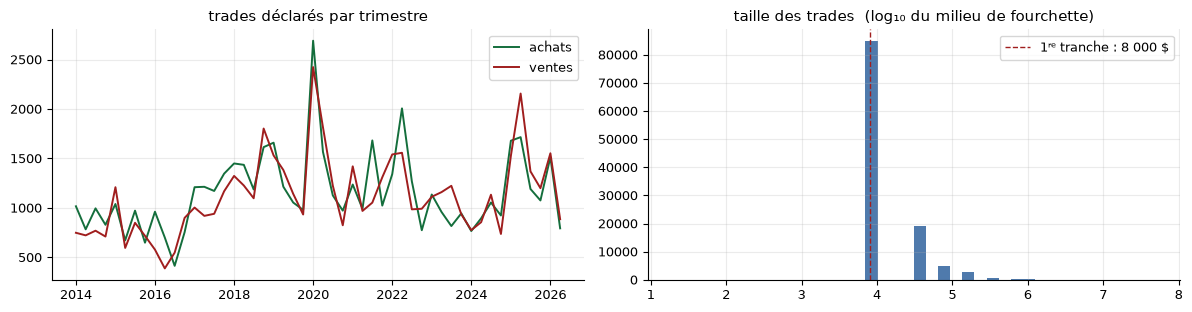

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
m = df.groupby([df.tau.dt.to_period("Q"), "op"]).size().unstack(fill_value=0)
m.index = m.index.to_timestamp()
ax[0].plot(m.index, m.get("buy", 0), color=VERT, lw=1.4, label="achats")
ax[0].plot(m.index, m.get("sell", 0), color=ROUGE, lw=1.4, label="ventes")
ax[0].set_title("trades déclarés par trimestre"); ax[0].legend()
ax[1].hist(np.log10(df.A.clip(lower=1)), bins=40, color=BLEU, alpha=.75)
ax[1].set_title("taille des trades  (log₁₀ du milieu de fourchette)")
ax[1].axvline(np.log10(8000.5), color=ROUGE, ls="--", lw=1, label="1ʳᵉ tranche : 8 000 $")
ax[1].legend(); plt.tight_layout(); plt.savefig(f"{FIGS}/flux.png", dpi=150, bbox_inches="tight"); plt.show()

## §2 — L'univers ticker $\mathcal{U}_t$

$$\mathcal{U}_t = \{\, i \;:\; \text{(a) action} \;\wedge\; \text{(b) } \exists\, u \in [\,n(t)-4,\; n(t)\,] \text{ tq } P_i(u) \text{ observée} \,\}$$

**(b) n'est pas une prudence, c'est une nécessité** : le cache prolonge les prix au dernier cours connu.
Sans ce test, une société morte en 2019 « cote » encore en 2026 — un cadavre à rendement 0 et risque 0.

In [8]:
NLAST  = {tk: cal.searchsorted(d, side="right") - 1 for tk, d in LAST.items()}   # dernier vrai cours
NFIRST = {tk: int(np.argmax(~np.isnan(PXV[tk]))) for tk in PXV}                  # premier cours disponible

def vivant(tk, i):
    # condition (b) : le titre cote DEJA (sa serie a commence) ET cote ENCORE (dernier cours <= 4 j)
    return NFIRST[tk] <= i and NLAST[tk] >= i - 4
mort = sum(1 for tk in PXV if NLAST[tk] < len(cal) - 5)
print(f"titres dont la cotation s'arrête avant la fin du calendrier : {mort:,} / {len(PXV):,} ({mort/len(PXV):.0%})")

titres dont la cotation s'arrête avant la fin du calendrier : 80 / 2,755 (3%)


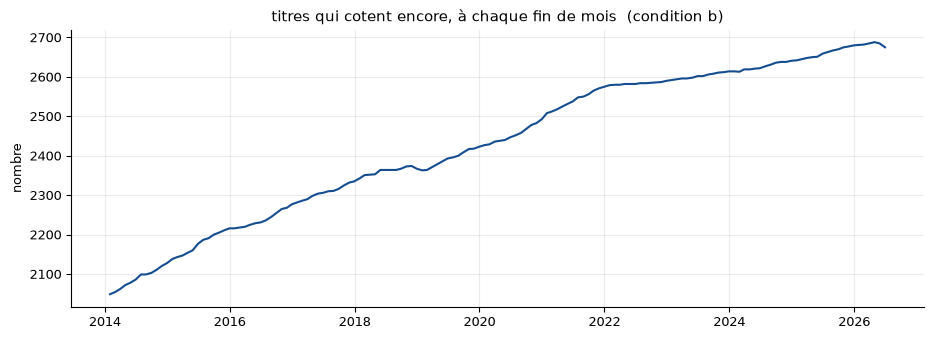

150 coupes mensuelles · 2014-01-31 → 2026-06-30


In [9]:
# les coupes commencent avec la donnée : premier mois de 2014, pas le début du calendrier de prix
DEBUT = pd.Timestamp("2014-01-31")
coupes = [cal.searchsorted(d, side="right") - 1
          for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
coupes = sorted(set(i for i in coupes if W <= i < len(cal) - 1))
viv = [sum(vivant(tk, i) for tk in PXV) for i in coupes]
plt.plot([cal[i] for i in coupes], viv, color=BLEU, lw=1.5)
plt.title("titres qui cotent encore, à chaque fin de mois  (condition b)"); plt.ylabel("nombre"); plt.savefig(f"{FIGS}/univers.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"{len(coupes)} coupes mensuelles · {cal[coupes[0]].date()} → {cal[coupes[-1]].date()}")

## §3 — Le portefeuille des membres, pour dater les lots

Il **ne sert qu'à ça**. Par couple (membre, titre), file **FIFO** : un achat empile un lot
$(s_k,\, q_k)$ avec $q_k = A_k / P_{i_k}(s_k)$ ; une vente consomme les lots **les plus anciens**.

Chaque tranche $\ell$ consommée par la vente $k$ a été détenue
$$h_\ell \;=\; \#\bigl(\mathcal{C} \cap (\,s_\ell,\; s_k\,]\bigr) \quad \text{jours de bourse.}$$

In [10]:
def tranches_vendues(g):
    # pour chaque vente : la liste des (h, q) consommés, et la part non appariée
    lots, out = deque(), {}
    for idx, i0, op, A in zip(g.index.values, g.i0.values, g.op.values, g.A.values):
        p = PXV[g.tk.iat[0]][i0]
        if not np.isfinite(p) or p <= 0: continue
        q = A / p
        if op == "buy":
            lots.append([i0, q])
        else:
            reste, pieces = q, []
            while reste > 1e-12 and lots:
                s0, q0 = lots[0]
                pris = min(reste, q0); reste -= pris; lots[0][1] -= pris
                pieces.append((i0 - s0, pris))          # (h, q)
                if lots[0][1] <= 1e-12: lots.popleft()
            out[idx] = (pieces, reste)                  # reste = part non appariée
    return out

In [11]:
VENTES = {}
for (_, _), g in df.groupby(["bioguide_id","tk"], sort=False):
    VENTES.update(tranches_vendues(g))
n_v = (df.op == "sell").sum()
print(f"ventes traitées : {len(VENTES):,} / {n_v:,}")

ventes traitées : 55,061 / 55,924


### 3.1 Validation — un cas recalculé à la main, hors moteur

In [12]:
# on prend un membre×titre avec au moins 1 achat puis 1 vente
cand = (df.assign(b=(df.op=="buy").astype(int), s=(df.op=="sell").astype(int))
          .groupby(["bioguide_id","tk"])[["b","s"]].sum().query("b>=2 and s>=1"))
bid, tk = cand.index[0]
g = df[(df.bioguide_id == bid) & (df.tk == tk)]
print(f"{g.member_name.iat[0]} — {tk}")
display(g[["tau","op","A","i0"]])

# recalcul manuel
lots_m, res_m = [], {}
for idx, i0, op, A in zip(g.index, g.i0, g.op, g.A):
    q = A / PXV[tk][i0]
    if op == "buy": lots_m.append([i0, q])
    else:
        reste, pcs = q, []
        while reste > 1e-12 and lots_m:
            s0, q0 = lots_m[0]
            pris = min(reste, q0); reste -= pris; lots_m[0][1] -= pris
            pcs.append((i0 - s0, pris))
            if lots_m[0][1] <= 1e-12: lots_m.pop(0)
        res_m[idx] = (pcs, reste)
ok = all(np.allclose([x[0] for x in res_m[i][0]], [x[0] for x in VENTES[i][0]]) and
         np.allclose([x[1] for x in res_m[i][0]], [x[1] for x in VENTES[i][0]]) for i in res_m)
print(f"\n✅ recalcul manuel identique au moteur : {ok}")
for i in res_m: print(f"   vente {i} → tranches (h en jours, parts) : "
                      f"{[(int(h), round(q,2)) for h,q in res_m[i][0]]} · non apparié {res_m[i][1]:.2f}")

Richard W. Allen — ABT


,tau,op,A,i0
46306,2019-09-13,buy,32500.5,1936
46562,2019-09-27,buy,32500.5,1946
112088,2026-04-16,sell,32500.5,3591



✅ recalcul manuel identique au moteur : True
   vente 112088 → tranches (h en jours, parts) : [(1655, np.float64(340.43))] · non apparié 0.00


### 3.2 Les durées de détention observées

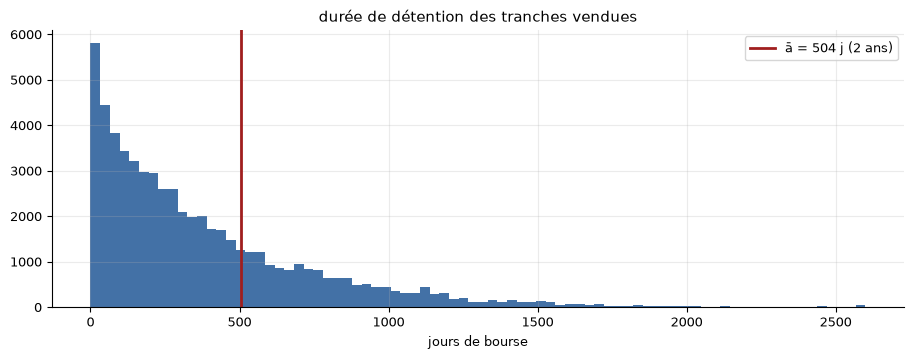

tranches vendues : 59,963 · médiane 268 j · part détenue > 2 ans : 27.3%


In [13]:
H = np.concatenate([[h for h, _ in p] for p, _ in VENTES.values() if p]) if VENTES else np.array([])
plt.hist(np.clip(H, 0, 2600), bins=80, color=BLEU, alpha=.8)
plt.axvline(A_BAR, color=ROUGE, lw=2, label=f"ā = {A_BAR} j (2 ans)")
plt.title("durée de détention des tranches vendues"); plt.xlabel("jours de bourse"); plt.legend(); plt.savefig(f"{FIGS}/durees.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"tranches vendues : {len(H):,} · médiane {np.median(H):.0f} j · "
      f"part détenue > 2 ans : {(H > A_BAR).mean():.1%}")

## §4 — La purge $\gamma$

$$\gamma_k \;=\; \frac{\sum_{\ell \subset k} \mathbf{1}\{h_\ell \le \bar a\}\, q_\ell}{\sum_{\ell \subset k} q_\ell}
\;\in\; [0,1]$$

= la part de la vente $k$ portant sur des lots détenus **moins de 2 ans**.

**achat $\Rightarrow \gamma_k = 1$** (un lot neuf n'a pas d'histoire) · **vente non appariée $\Rightarrow \gamma = 1$**
(on ne peut pas la dater, on ne l'invente pas vieille).

In [14]:
gam = np.ones(len(df))
for idx, (pieces, reste) in VENTES.items():
    tot = sum(q for _, q in pieces) + reste
    if tot <= 0: continue
    jeune = sum(q for h, q in pieces if h <= A_BAR) + reste     # le non apparié est conservé
    gam[idx] = jeune / tot
df["gamma"] = gam
v = df[df.op == "sell"]
print(f"ventes : γ = 1 (intactes) {100*(v.gamma > .999).mean():.1f}% · "
      f"γ = 0 (supprimées) {100*(v.gamma < .001).mean():.1f}% · "
      f"partielles {100*((v.gamma >= .001) & (v.gamma <= .999)).mean():.1f}%")
print(f"masse vendue conservée : {100*(v.A*v.gamma).sum()/v.A.sum():.1f}% des {v.A.sum()/1e9:.2f} Md$ déclarés")

ventes : γ = 1 (intactes) 79.9% · γ = 0 (supprimées) 17.1% · partielles 3.1%
masse vendue conservée : 89.5% des 2.11 Md$ déclarés


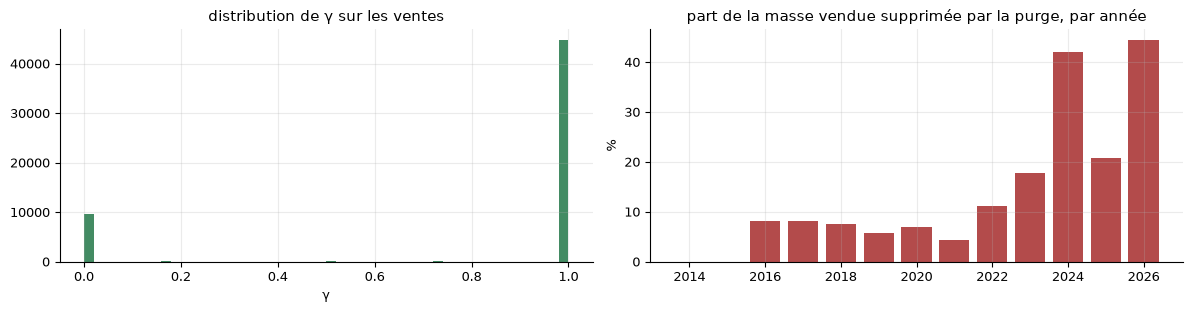

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].hist(v.gamma, bins=50, color=VERT, alpha=.8)
ax[0].set_title("distribution de γ sur les ventes"); ax[0].set_xlabel("γ")
part = v.assign(an=v.tau.dt.year).groupby("an").apply(lambda x: (x.A*x.gamma).sum()/x.A.sum())
ax[1].bar(part.index, 100*(1-part.values), color=ROUGE, alpha=.8)
ax[1].set_title("part de la masse vendue supprimée par la purge, par année"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.savefig(f"{FIGS}/gamma.png", dpi=150, bbox_inches="tight"); plt.show()

## §5 — Le flux par ticker

$$\mathcal{K}_{i,t}(W) = \{\, k : i_k = i,\; t - W < s_k \le t \,\}$$
$$Buy_{i,t} = \!\!\sum_{k \in \mathcal{K}_{i,t}}\!\! A_k \mathbf{1}\{d_k = +1\}
\qquad
Sell^{\varphi}_{i,t} = \!\!\sum_{k \in \mathcal{K}_{i,t}}\!\! A_k\, \gamma_k\, \mathbf{1}\{d_k = -1\}$$
$$NetBuy^{\varphi}_{i,t} = \bigl[\, Buy_{i,t} - Sell^{\varphi}_{i,t} \,\bigr]^{+}
\qquad
nBuyers_{i,t} = \#\{\, m_k : k \in \mathcal{K}_{i,t},\; d_k = +1 \,\}$$

In [16]:
df["sgn"] = np.where(df.op == "buy", 1.0, -1.0)
df["Aeff"] = df.A * np.where(df.op == "buy", 1.0, df.gamma)     # A_k · γ_k pour les ventes
ordre = np.argsort(df.i0.values, kind="stable")
I0 = df.i0.values[ordre]
IW, ordreW = I0, ordre        # index de FENÊTRAGE — τ par défaut ; bascule sur δ au §11

def flux(i1, W=None):
    W = W or W_REF
    # le panel (Buy, Sell^phi, NetBuy^phi, nBuyers) a la coupe d'indice i1
    lo, hi = np.searchsorted(IW, i1 - W, "right"), np.searchsorted(IW, i1, "right")
    g = df.iloc[ordreW[lo:hi]]
    if not len(g): return pd.DataFrame(columns=["Buy","Sell","NetBuy","nBuyers"])
    buy, sell = g[g.op == "buy"], g[g.op == "sell"]
    sell_r = sell[sell.gamma > 0]                                    # ventes de stock récent (γ>0)
    p = pd.DataFrame({"Buy":     buy.groupby("tk").A.sum(),
                      "Sell":    sell.groupby("tk").Aeff.sum(),      # Aeff = A·γ (purgé)
                      "nBuyers": buy.groupby("tk").bioguide_id.nunique(),
                      "nSellers":sell_r.groupby("tk").bioguide_id.nunique()}).fillna(0.0)
    p["NetBuy"] = (p.Buy - p.Sell).clip(lower=0)                     # long : partie positive
    p["Net"]    = p.Buy - p.Sell                                     # signé : peut être < 0
    return p[["Buy","Sell","NetBuy","Net","nBuyers","nSellers"]]

In [17]:
i_demo = coupes[len(coupes)//2]
P_demo = flux(i_demo)
print(f"coupe du {cal[i_demo].date()} — {len(P_demo)} titres touchés sur la fenêtre de {W} j")
P_demo.sort_values("NetBuy", ascending=False).head(8).round(0)

coupe du 2020-04-30 — 604 titres touchés sur la fenêtre de 21 j


,Buy,Sell,NetBuy,Net,nBuyers,nSellers
tk,,,,,,
AVY,350001.0,8000.0,342000.0,342000.0,1.0,1.0
TRS,207501.0,0.0,207501.0,207501.0,1.0,0.0
WTM,207501.0,0.0,207501.0,207501.0,1.0,0.0
G,207501.0,0.0,207501.0,207501.0,1.0,0.0
CSL,207501.0,0.0,207501.0,207501.0,1.0,0.0
SWK,215002.0,16001.0,199001.0,199001.0,1.0,2.0
AMZN,279504.0,99002.0,180502.0,180502.0,7.0,4.0
ALGN,175000.0,8000.0,167000.0,167000.0,1.0,1.0


## §6 — Le signal

$$S_t = \{\, i \in \mathcal{U}_t \;:\; NetBuy^{\varphi}_{i,t} > 0 \;\wedge\; nBuyers_{i,t} \ge b_{\min} = 2 \,\}$$

In [18]:
def selection(i1, W=None):
    p = flux(i1, W)
    if not len(p): return []
    ok = (p.NetBuy > 0) & (p.nBuyers >= B_MIN)
    return [tk for tk in p.index[ok] if vivant(tk, i1)]

SEL = {i: selection(i) for i in coupes}
taille = np.array([len(SEL[i]) for i in coupes])
print(f"|S_t| : médiane {np.median(taille):.0f} · q25 {np.percentile(taille,25):.0f} · "
      f"q75 {np.percentile(taille,75):.0f} · min {taille.min()} · max {taille.max()}")
print(f"mois où |S_t| = 0 : {(taille==0).sum()} · où |S_t| < 5 : {(taille<5).sum()} / {len(taille)}")

|S_t| : médiane 28 · q25 19 · q75 44 · min 1 · max 123
mois où |S_t| = 0 : 0 · où |S_t| < 5 : 2 / 150


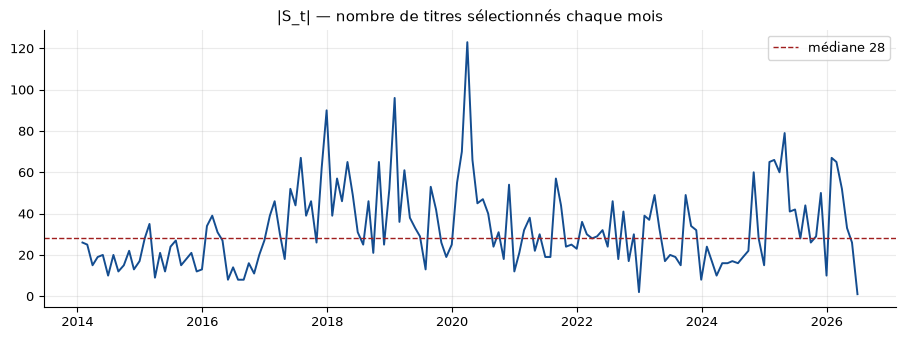

In [19]:
plt.plot([cal[i] for i in coupes], taille, color=BLEU, lw=1.4)
plt.axhline(np.median(taille), color=ROUGE, ls="--", lw=1, label=f"médiane {np.median(taille):.0f}")
plt.title("|S_t| — nombre de titres sélectionnés chaque mois"); plt.legend(); plt.savefig(f"{FIGS}/selection.png", dpi=150, bbox_inches="tight"); plt.show()

In [20]:
print(f"exemple — la sélection du {cal[i_demo].date()} ({len(SEL[i_demo])} titres) :")
P_demo.loc[SEL[i_demo]].sort_values("NetBuy", ascending=False).head(10).round(0)

exemple — la sélection du 2020-04-30 (66 titres) :


,Buy,Sell,NetBuy,Net,nBuyers,nSellers
tk,,,,,,
AMZN,279504.0,99002.0,180502.0,180502.0,7.0,4.0
AON,115502.0,0.0,115502.0,115502.0,2.0,0.0
RHI,115502.0,7733.0,107769.0,107769.0,2.0,1.0
SHEL,91002.0,0.0,91002.0,91002.0,3.0,0.0
RIO,91002.0,0.0,91002.0,91002.0,2.0,0.0
SONY,97003.0,8000.0,89002.0,89002.0,2.0,1.0
VMC,83001.0,0.0,83001.0,83001.0,2.0,0.0
NFLX,123502.0,40501.0,83001.0,83001.0,3.0,2.0
SBGSY,83001.0,0.0,83001.0,83001.0,2.0,0.0


### 6.1 Qui a acheté quoi — la table $B_{m,t}$

Pour pondérer par membre (\S7) il faut, à chaque coupe, **qui** a acheté **quels** titres de $S_t$ :
$$\mathcal{M}_t = \{\, m : m \text{ a acheté au moins un titre de } S_t \,\}, \qquad K_t = |\mathcal{M}_t|$$
$$B_{m,t} = \{\, i \in S_t : m \text{ a acheté } i \text{ dans la fenêtre} \,\}$$

In [21]:
def acheteurs(i1, S, W=None):
    W = W or W_REF
    # rend {membre: [ses tickers de S]} sur la fenêtre de la coupe i1
    if not S: return {}
    lo, hi = np.searchsorted(IW, i1 - W, "right"), np.searchsorted(IW, i1, "right")
    g = df.iloc[ordreW[lo:hi]]
    g = g[(g.op == "buy") & (g.tk.isin(set(S)))]
    return {m: sorted(set(x)) for m, x in g.groupby("bioguide_id").tk}

ACH = {i: acheteurs(i, SEL[i]) for i in coupes}
K = np.array([len(ACH[i]) for i in coupes])
print(f"K_t (membres acheteurs) : médiane {np.median(K):.0f} · q25 {np.percentile(K,25):.0f} · "
      f"q75 {np.percentile(K,75):.0f} · min {K.min()} · max {K.max()}")
nB = np.array([len(v) for i in coupes for v in ACH[i].values()])
print(f"|B_m| (titres par membre) : médiane {np.median(nB):.0f} · q90 {np.percentile(nB,90):.0f} · max {nB.max()}")

K_t (membres acheteurs) : médiane 20 · q25 15 · q75 25 · min 2 · max 45
|B_m| (titres par membre) : médiane 2 · q90 8 · max 96


In [22]:
a = ACH[i_demo]
print(f"coupe du {cal[i_demo].date()} — {len(a)} membres acheteurs, {len(SEL[i_demo])} titres retenus\n")
apercu = pd.DataFrame([{"membre": df.loc[df.bioguide_id == m, "member_name"].iat[0],
                        "|B_m|": len(v), "poids par titre": 1/(len(a)*len(v)), "ses titres": ", ".join(v[:5])}
                       for m, v in list(a.items())[:8]])
apercu.round(4)

coupe du 2020-04-30 — 27 membres acheteurs, 66 titres retenus



,membre,|B_m|,poids par titre,ses titres
0,Cindy Axne,1,0.0370,MA
1,Mo Brooks,2,0.0185,"D, DUK"
2,Susan W. Brooks,3,0.0123,"AMZN, MA, QCOM"
3,James E. Banks,1,0.0370,SBUX
4,Thomas R Carper,4,0.0093,"DGX, LHX, QCOM, SBUX"
5,K. Michael Conaway,2,0.0185,"AMZN, DUK"
6,Katherine M. Clark,2,0.0185,"LHX, MOS"
7,Gilbert Cisneros,11,0.0034,"AON, GE, HQY, LHX, LUMN"


## §7 — Le portefeuille : **une voix par membre**

Chaque membre acheteur reçoit $1/K_t$ du capital, puis **répartit sa part également** entre les titres
qu'il a achetés :
$$\boxed{\;w_{i,t} \;=\; \frac{1}{K_t} \sum_{m \in \mathcal{M}_t} \frac{\mathbf{1}\{i \in B_{m,t}\}}{|B_{m,t}|}\;}$$

**Pourquoi ce poids.** Le montant $A_k$ n'y apparaît pas : les 11 M\$ d'un élu fortuné et les 15 k\$ d'un
autre pèsent **exactement $1/K$ chacun**. Le portefeuille cesse d'être piloté par la richesse.

**Trois propriétés, aucun paramètre :**
- $\sum_i w_{i,t} = \frac{1}{K}\sum_m \sum_{i \in B_m} \frac{1}{|B_m|} = \frac{1}{K}\sum_m 1 = 1$ — normalisation automatique
- $|B_m| = 1\ \forall m \Rightarrow w_i \propto b_i$ ; $\;|B_m| = |S_t|\ \forall m \Rightarrow w_i = 1/|S_t|$ (l'équipondéré)
  $\Rightarrow$ la règle se place **seule** entre les deux régimes
- un rééquilibrage de trust sur 133 lignes donne $1/(133K)$ par ligne $\Rightarrow$ **la délégation se dilue toute seule**

**À la coupe** $t_R$, exécution au close du jour suivant, puis buy-and-hold :
$$nbr_i = \frac{V(t_R{+}1)\, w_{i,t_R}}{P_i(t_R{+}1)}, \qquad
V(t) = \sum_{i} nbr_i\, P_i(t), \qquad r(t) = \frac{V(t)}{V(t-1)} - 1$$

In [23]:
def poids(i1, W=None, sel=None, ach=None):
    # w_i = (1/K) * somme_m 1{i dans B_m} / |B_m|   — restreint aux titres priçables à l'exécution
    S = [tk for tk in (sel if sel is not None else SEL[i1]) if np.isfinite(PXV[tk][i1 + 1])]
    if not S: return {}
    Sset = set(S)
    A = ach if ach is not None else ACH[i1]
    B = {m: [tk for tk in v if tk in Sset] for m, v in A.items()}
    B = {m: v for m, v in B.items() if v}
    if not B: return {}
    Kt = len(B)
    w = {}
    for m, v in B.items():
        part = 1.0 / (Kt * len(v))
        for tk in v: w[tk] = w.get(tk, 0.0) + part
    assert abs(sum(w.values()) - 1.0) < 1e-12, f"les poids ne somment pas à 1 : {sum(w.values())}"
    return w

WPO = {i: poids(i) for i in coupes[:-1]}
mx = np.array([max(v.values()) for v in WPO.values() if v])
print(f"poids max par mois : médiane {np.median(mx):.1%} · q90 {np.percentile(mx,90):.1%} · max {mx.max():.1%}")
print(f"mois où une ligne dépasse 10 % : {(mx > .10).sum()} / {len(mx)}  ({(mx > .10).mean():.0%})")

poids max par mois : médiane 11.0% · q90 18.1% · max 50.0%
mois où une ligne dépasse 10 % : 86 / 149  (58%)


In [24]:
def run():
    V = np.full(len(cal), np.nan); nbr = {}
    e0 = coupes[0] + 1
    V[e0] = 100.0
    bornes = [(coupes[j] + 1, coupes[j+1] + 1) for j in range(len(coupes) - 1)]
    for (e, e_next) in bornes:
        w = WPO.get(e - 1, {})                                       # poids « une voix par membre »
        nbr = {tk: V[e] * wi / PXV[tk][e] for tk, wi in w.items()}
        for t in range(e + 1, min(e_next, len(cal) - 1) + 1):
            V[t] = sum(q * PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t - 1]
    out = pd.Series(V, index=cal)
    span = out.loc[out.first_valid_index():out.last_valid_index()]
    assert span.notna().all(), f"trous dans la NAV : {span.isna().sum()} jours"
    return span

V = run()
r = V.pct_change().dropna()
V_ref, r_ref, mx_ref, tail_ref = V.copy(), r.copy(), mx.copy(), taille.copy()   # référence W = 21
print(f"série : {V.index[0].date()} → {V.index[-1].date()} · {len(r):,} jours · NAV finale {V.iloc[-1]:.1f}")

série : 2014-02-03 → 2026-07-01 · 3,120 jours · NAV finale 554.3


### 7.1 Vérification des deux régimes limites (propriété P2)

La formule doit redonner **$w \propto b_i$** si chaque membre n'achète qu'un titre, et **$1/|S_t|$** si
tous achètent tout. On le vérifie numériquement, sur une coupe réelle.

In [25]:
i1 = i_demo; S = [tk for tk in SEL[i1] if np.isfinite(PXV[tk][i1+1])]; Sset = set(S)
B0 = {m: [tk for tk in v if tk in Sset] for m, v in ACH[i1].items()}
B0 = {m: v for m, v in B0.items() if v}

def w_de(B):
    Kt = len(B); w = {}
    for m, v in B.items():
        for tk in v: w[tk] = w.get(tk, 0.0) + 1.0/(Kt*len(v))
    return w

# régime 1 : chaque membre n'achète qu'un titre  →  w ∝ b_i
B1 = {m: [v[0]] for m, v in B0.items()}
w1 = w_de(B1)
b1 = pd.Series({tk: sum(1 for v in B1.values() if tk in v) for tk in w1})
ok1 = np.allclose(pd.Series(w1)[b1.index].values, (b1/b1.sum()).values)

# régime 2 : tous les membres achètent tous les titres  →  w = 1/|S|
B2 = {m: S for m in B0}
w2 = w_de(B2)
ok2 = np.allclose(list(w2.values()), 1.0/len(S))

print(f"régime |B_m| = 1     →  w ∝ b_i      : {ok1}")
print(f"régime B_m = S_t     →  w = 1/|S_t|  : {ok2}   (1/{len(S)} = {1/len(S):.5f})")
assert ok1 and ok2
print("\n✅ la formule niche bien les deux régimes — sans paramètre")

régime |B_m| = 1     →  w ∝ b_i      : True
régime B_m = S_t     →  w = 1/|S_t|  : True   (1/66 = 0.01515)

✅ la formule niche bien les deux régimes — sans paramètre


### 7.2 Ce que la pondération change, concrètement

In [26]:
w_reel = WPO[i_demo]
w_eq = 1/len(w_reel)
cmp = (pd.Series(w_reel).sort_values(ascending=False).to_frame("w (une voix/membre)")
         .assign(**{"w équipondéré": w_eq}))
cmp["rapport"] = cmp.iloc[:,0] / w_eq
print(f"coupe du {cal[i_demo].date()} · {len(w_reel)} titres · équipondéré = {w_eq:.4f}")
cmp.head(8).round(4)

coupe du 2020-04-30 · 66 titres · équipondéré = 0.0152


,w (une voix/membre),w équipondéré,rapport
SBUX,0.0795,0.0152,5.2489
MA,0.0664,0.0152,4.3796
AMZN,0.0533,0.0152,3.5163
ADBE,0.0463,0.0152,3.0556
CINF,0.0407,0.0152,2.6889
TMUS,0.0404,0.0152,2.6667
VSAT,0.0394,0.0152,2.5972
PINS,0.0381,0.0152,2.5163


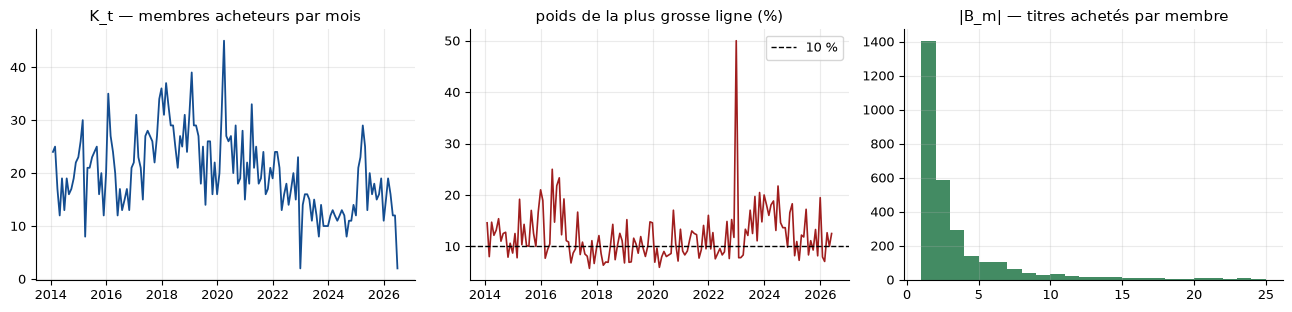

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot([cal[i] for i in coupes], K, color=BLEU, lw=1.3)
ax[0].set_title("K_t — membres acheteurs par mois")
ax[1].plot([cal[i] for i in coupes[:-1]], 100*mx, color=ROUGE, lw=1.2)
ax[1].axhline(10, color="k", ls="--", lw=1, label="10 %"); ax[1].legend()
ax[1].set_title("poids de la plus grosse ligne (%)")
ax[2].hist(nB, bins=range(1, 26), color=VERT, alpha=.8)
ax[2].set_title("|B_m| — titres achetés par membre")
plt.tight_layout(); plt.savefig(f"{FIGS}/poids.png", dpi=150, bbox_inches="tight"); plt.show()

### 7.3 Choisir $W$ — sur la **concentration**, jamais sur le rendement

Avec $W = 21$ j, une ligne dépasse 10 % du portefeuille dans **58 %** des mois (max 50 %) : $K_t$ est trop
petit (médiane 20, minimum 2). On desserre la seule constante qui pilote mécaniquement $K_t$ et $|S_t|$.

**Le critère est annoncé avant de calculer quoi que ce soit sur les rendements :**

$$W^\star \;=\; \min\Bigl\{\, W \in \{21, 42, 63, 126\} \;:\; \mathbb{P}\bigl[\max_i w_{i,t} > 10\,\%\bigr] \le 20\,\% \,\Bigr\}$$

Aucun rendement n'entre dans ce choix — c'est ce qui empêche le balayage de devenir une pêche au résultat.

In [28]:
lignes = []
for Wc in [21, 42, 63, 126]:
    Sc  = {i: selection(i, Wc) for i in coupes}
    Ac  = {i: acheteurs(i, Sc[i], Wc) for i in coupes}
    Wc_ = {i: poids(i, Wc, Sc[i], Ac[i]) for i in coupes[:-1]}
    mxc = np.array([max(v.values()) for v in Wc_.values() if v])
    lignes.append({"W (j)": Wc,
                   "|S_t| médian": int(np.median([len(Sc[i]) for i in coupes])),
                   "K_t médian":   int(np.median([len(Ac[i]) for i in coupes])),
                   "poids max médian": np.median(mxc),
                   "part mois > 10 %": (mxc > .10).mean()})
tabW = pd.DataFrame(lignes).set_index("W (j)")
ok = tabW[tabW["part mois > 10 %"] <= .20]
W_STAR = int(ok.index[0]) if len(ok) else int(tabW["part mois > 10 %"].idxmin())
print(tabW.assign(**{"poids max médian": (100*tabW["poids max médian"]).round(1).astype(str)+" %",
                     "part mois > 10 %": (100*tabW["part mois > 10 %"]).round(0).astype(int).astype(str)+" %"}).to_string())
print(f"\n→ W* = {W_STAR} j" + ("" if len(ok) else "  (aucun ne passe le critère : on prend le moins concentré, et on le dit)"))

       |S_t| médian  K_t médian poids max médian part mois > 10 %
W (j)                                                            
21               28          19           11.0 %             58 %
42               64          32            7.2 %             17 %
63               91          39            6.3 %              9 %
126             156          53            5.4 %              5 %

→ W* = 42 j


In [29]:
W = W_STAR                                          # on rejoue toute la chaîne avec W*
SEL = {i: selection(i, W) for i in coupes}
ACH = {i: acheteurs(i, SEL[i], W) for i in coupes}
WPO = {i: poids(i, W, SEL[i], ACH[i]) for i in coupes[:-1]}
taille = np.array([len(SEL[i]) for i in coupes]); K = np.array([len(ACH[i]) for i in coupes])
mx = np.array([max(v.values()) for v in WPO.values() if v])
V = run(); r = V.pct_change().dropna()
print(f"W = {W} j · |S_t| médian {np.median(taille):.0f} · K_t médian {np.median(K):.0f} · "
      f"poids max médian {np.median(mx):.1%} · mois > 10 % : {(mx>.10).mean():.0%}")
print(f"NAV finale {V.iloc[-1]:.1f}")

W = 42 j · |S_t| médian 64 · K_t médian 32 · poids max médian 7.2% · mois > 10 % : 17%
NAV finale 622.1


### 7.4 Validation — un mois recalculé à la main

In [30]:
j = len(coupes)//2
e, e_next = coupes[j] + 1, coupes[j+1] + 1
w = WPO[e-1]
nbr_m = {tk: V.loc[cal[e]] * wi / PXV[tk][e] for tk, wi in w.items()}
t_test = min(e + 5, e_next)
V_main = sum(q * PXV[tk][t_test] for tk, q in nbr_m.items())
print(f"segment du {cal[e].date()} · {len(w)} titres · Σw = {sum(w.values()):.10f} · "
      f"poids min {min(w.values()):.4f} / max {max(w.values()):.4f}")
print(f"V({cal[t_test].date()})  moteur {V.loc[cal[t_test]]:.4f}   à la main {V_main:.4f}   "
      f"écart {abs(V.loc[cal[t_test]] - V_main):.2e}")
assert abs(V.loc[cal[t_test]] - V_main) < 1e-8
print("✅ identique")

segment du 2020-05-01 · 146 titres · Σw = 1.0000000000 · poids min 0.0006 / max 0.0573
V(2020-05-08)  moteur 197.9369   à la main 197.9369   écart 0.00e+00
✅ identique


## §8 — Le résultat

Deux runs côte à côte : la fenêtre de référence $W = 21$ j, et $W^\star$ retenu par le critère de
concentration. **Ce sont deux essais déclarés**, pas deux chances de trouver un gagnant.

In [31]:
def bilan(Vx, nom):
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    dd = pd.DataFrame({"p": rx, "m": r_spy.reindex(rx.index)}).join(
             pd.read_csv(f"{RACINE}/02_recherche_backtest/cache/ff_factors.csv",
                         parse_dates=["Date"]).set_index("Date")[["RF"]]).dropna()
    yy, XX = (dd.p - dd.RF).values, (dd.m - dd.RF).values
    b, a = np.polyfit(XX, yy, 1); ee = yy - (a + b*XX)
    return {"run": nom, "excès %/an": 100*xx.mean(), "t": xx.mean()/(xx.std(ddof=1)/np.sqrt(len(xx))),
            "α %/an": 252*a*100, "t_α": a/(ee.std(ddof=2)/np.sqrt(len(yy))), "β": b,
            "NAV": Vx.iloc[-1], "ann. gagnantes": f"{int((xx>0).sum())}/{len(xx)}"}

pd.DataFrame([bilan(V_ref, f"W = {W_REF} j (référence)"), bilan(V, f"W* = {W} j")]).set_index("run").round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
W = 21 j (référence),0.303,0.165,0.059,0.029,1.038,554.284,7/13
W* = 42 j,1.706,1.030,1.048,0.645,1.023,622.132,7/13


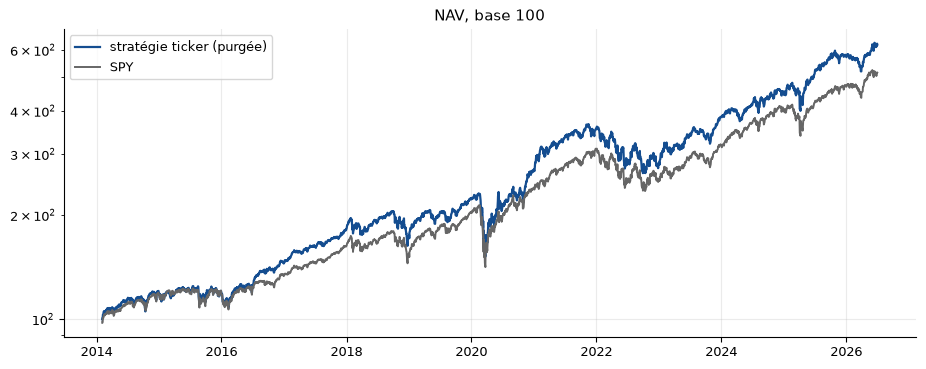

stratégie 622   ·   SPY 517


In [32]:
nav_spy = (1 + r_spy.reindex(V.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(V.index, V, color=BLEU, lw=1.6, label="stratégie ticker (purgée)")
ax.plot(nav_spy.index, nav_spy, color=GRIS, lw=1.4, label="SPY")
ax.set_yscale("log"); ax.set_title("NAV, base 100"); ax.legend(); plt.savefig(f"{FIGS}/nav.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"stratégie {V.iloc[-1]:.0f}   ·   SPY {nav_spy.iloc[-1]:.0f}")

In [33]:
def compose(s): return float((1 + s).prod() - 1)
an = pd.DataFrame({"strat": r.groupby(r.index.year).apply(compose),
                   "spy":   r_spy.reindex(r.index).fillna(0).groupby(r.index.year).apply(compose)})
an["exces"] = an.strat - an.spy
x = an.exces.values
t_x = x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))
print(f"excès moyen {100*x.mean():+.2f} %/an · t = {t_x:+.2f} · "
      f"années gagnantes {(x>0).sum()}/{len(x)} · seuil t_{len(x)-1} ≈ 1,8")
(100*an).round(1)

excès moyen +1.71 %/an · t = +1.03 · années gagnantes 7/13 · seuil t_12 ≈ 1,8


,strat,spy,exces
Date,,,
2014,19.0,20.3,-1.3
2015,0.4,1.2,-0.9
2016,21.4,12.0,9.4
2017,24.7,21.7,3.0
2018,-3.7,-4.6,0.9
2019,27.9,31.2,-3.4
2020,21.8,18.3,3.5
2021,30.7,28.7,2.0
2022,-21.2,-18.2,-3.1


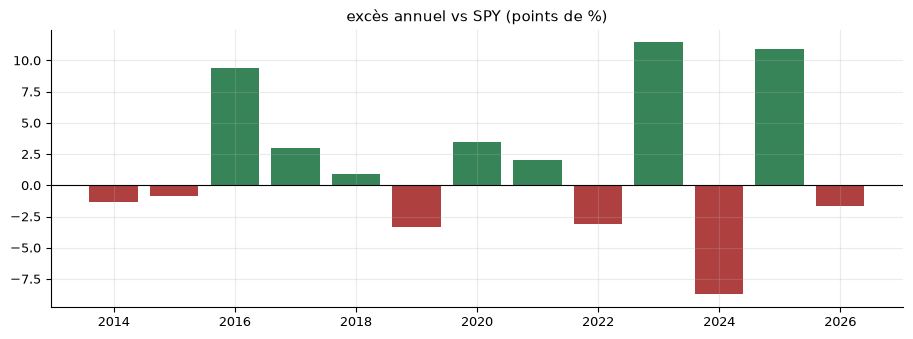

In [34]:
plt.bar(an.index, 100*an.exces, color=[VERT if v > 0 else ROUGE for v in an.exces], alpha=.85)
plt.axhline(0, color="k", lw=.8); plt.title("excès annuel vs SPY (points de %)"); plt.savefig(f"{FIGS}/exces.png", dpi=150, bbox_inches="tight"); plt.show()

In [35]:
ff = pd.read_csv(f"{RACINE}/02_recherche_backtest/cache/ff_factors.csv", parse_dates=["Date"]).set_index("Date")
d = pd.DataFrame({"p": r, "m": r_spy.reindex(r.index)}).join(ff[["RF"]]).dropna()
y, X = (d.p - d.RF).values, (d.m - d.RF).values
beta, alpha = np.polyfit(X, y, 1)
eps = y - (alpha + beta*X); se = eps.std(ddof=2)
print(f"β = {beta:.3f}   α = {252*alpha*100:+.2f} %/an   "
      f"t_α = {alpha/(se/np.sqrt(len(y))):+.2f}   (marché en excès du taux sans risque)")

β = 1.023   α = +1.05 %/an   t_α = +0.64   (marché en excès du taux sans risque)


## §9 — Diagnostics

ADV des titres sélectionnés — médiane 102 M$/j · part sous 5 M$/j : 5.7%


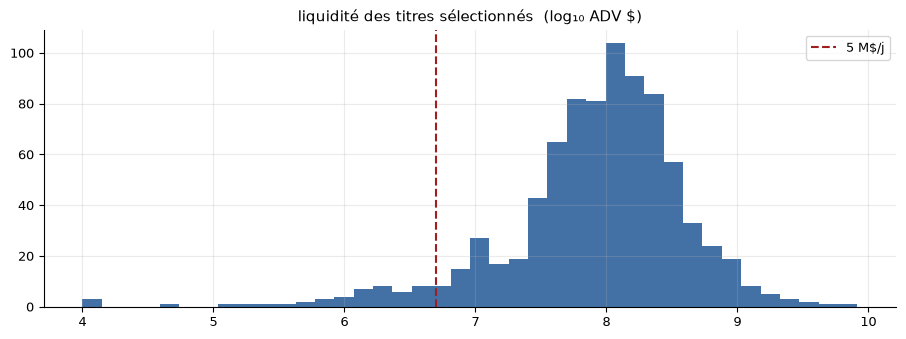

In [36]:
med_adv = {}
for tk in {t for S in SEL.values() for t in S}:
    f = f"{VOL}/{tk}.csv"
    if os.path.exists(f):
        try:
            v = pd.read_csv(f)
            med_adv[tk] = float((v.close_raw * v.volume).median())
        except Exception: pass
adv = pd.Series({tk: med_adv.get(tk, np.nan) for S in SEL.values() for tk in S}).dropna()
print(f"ADV des titres sélectionnés — médiane {adv.median()/1e6:,.0f} M$/j · "
      f"part sous 5 M$/j : {(adv < 5e6).mean():.1%}")
plt.hist(np.log10(adv.clip(lower=1e4)), bins=40, color=BLEU, alpha=.8)
plt.axvline(np.log10(5e6), color=ROUGE, ls="--", label="5 M$/j")
plt.title("liquidité des titres sélectionnés  (log₁₀ ADV $)"); plt.legend(); plt.savefig(f"{FIGS}/adv.png", dpi=150, bbox_inches="tight"); plt.show()

## §10 — Deux extensions : le cap de turnover et la jambe short

Deux ajouts, chacun **niche** l'existant (un réglage neutre redonne le long-only sans cap) :

**(a) Cap de turnover** — on ne réalloue pas d'un coup, on avance *partiellement* vers la cible, d'au plus
$\tau_{\max} = 25\,\%$ par mois :
$$\mathrm{TO}_R = \tfrac12 \sum_i |w^{\mathrm{cible}}_i - w^{\mathrm{d\acute erive}}_i|,\quad
\lambda_R = \min\!\Bigl(1, \tfrac{\tau_{\max}}{\mathrm{TO}_R}\Bigr),\quad
w^{\mathrm{r\acute ealis\acute e}}_i = w^{\mathrm{d\acute erive}}_i + \lambda_R\,(w^{\mathrm{cible}}_i - w^{\mathrm{d\acute erive}}_i)$$

**(b) Jambe short** — au lieu de couper à zéro, on garde aussi les titres à flux net **négatif** :
$$S^-_t = \{\, i \in \mathcal U_t : \mathrm{Net}^\varphi_{i,t} < 0 \;\wedge\; nSellers_{i,t} \ge 2 \,\},\qquad
r(t) = r^+(t) - \theta\, r^-(t)$$
$\theta = 0$ redonne le long-only ; $\theta = 1$ = long-short dollar-neutre. *(nSellers ne compte que les vendeurs de stock récent — la purge évite qu'un déstockage de vieux déclenche un short.)*

In [37]:
TAU_MAX = 0.25                                                        # turnover max par mois

def cap_turnover(w_der, w_cible, tau_max):
    keys = set(w_der) | set(w_cible)
    TO = 0.5 * sum(abs(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys)
    if TO <= 1e-12: return dict(w_cible)
    lam = min(1.0, tau_max / TO)
    return {k: w_der.get(k,0.0) + lam*(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys}

def run_livre(WP, tau_max=np.inf, cuts=None, cout_bps=0.0):
    # moteur d'UN livre (long ou short) : parts, buy-and-hold, cap de turnover. Rend (NAV, turnovers réalisés)
    # cuts=None → coupes mensuelles (défaut, non-régression) ; on peut passer des coupes hebdo (§14, Quiver)
    # cout_bps=0 → aucun frais (défaut, non-régression bit-exacte) ; §16.4 facture le frottement
    cuts = coupes if cuts is None else cuts
    V = np.full(len(cal), np.nan); nbr = {}; turns = []
    e0 = cuts[0] + 1; V[e0] = 100.0
    bornes = [(cuts[j] + 1, cuts[j+1] + 1) for j in range(len(cuts) - 1)]
    for (e, e_next) in bornes:
        w_cible = {tk: wi for tk, wi in WP.get(e-1, {}).items() if np.isfinite(PXV[tk][e])}
        val = sum(q*PXV[tk][e] for tk, q in nbr.items())
        w_der = {tk: q*PXV[tk][e]/val for tk, q in nbr.items()} if val > 0 else {}
        # Deux cas exemptés du cap, pour ne JAMAIS vaporiser du cash de la NAV :
        #  - w_der vide (1er déploiement) : on bâtit le livre en entier — partir du cash n'est pas de la rotation
        #    (sinon la NAV chutait à ~50 dès le 1er mois — artefact repéré par Alice sur la courbe B) ;
        #  - w_cible vide (sélection vide) : on sort tout au cash, tenu à plat (V[t]=V[t-1]), comme le run non capé.
        w_real = dict(w_cible) if (not w_der or not w_cible) else cap_turnover(w_der, w_cible, tau_max)
        # garde-fou bruyant : quand une cible existe, le livre reste pleinement investi (Σw=1) — pas de fuite
        assert (not w_cible) or abs(sum(w_real.values()) - 1.0) < 1e-6, "run_livre : poids capés ne somment pas à 1 (fuite de cash)"
        turns.append(0.5*sum(abs(w_real.get(k,0)-w_der.get(k,0)) for k in set(w_real)|set(w_der)))
        # frais : ½Σ|Δw| est le montant ACHETÉ, égal au montant VENDU — on paie sur les deux, d'où le facteur 2.
        # `if cout_bps` : à 0 aucune opération n'est faite, la non-régression est bit-exacte.
        if cout_bps: V[e] *= 1.0 - 2.0*turns[-1]*cout_bps/1e4
        nbr = {tk: V[e]*wi/PXV[tk][e] for tk, wi in w_real.items() if abs(wi) > 1e-12}
        for t in range(e+1, min(e_next, len(cal)-1)+1):
            V[t] = sum(q*PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t-1]
    span = pd.Series(V, index=cal); span = span.loc[span.first_valid_index():span.last_valid_index()]
    return span, np.array(turns[1:])                                 # turnover hors 1er déploiement

In [38]:
# NON-RÉGRESSION : run_livre(WPO, ∞) doit reproduire le long-only validé (§7)
span_ref, _ = run_livre(WPO, np.inf)
assert np.allclose(span_ref.values, V.reindex(span_ref.index).values, atol=1e-9), "run_livre casse la non-régression"
print(f"✅ non-régression : run_livre(WPO, ∞) ≡ le run §7  (NAV {span_ref.iloc[-1]:.1f})")

✅ non-régression : run_livre(WPO, ∞) ≡ le run §7  (NAV 622.1)


In [39]:
# le livre SHORT : titres net vendus, corroborés par ≥2 vendeurs de stock récent
def selection_short(i1, W):
    p = flux(i1, W)
    if not len(p): return []
    ok = (p.Net < 0) & (p.nSellers >= B_MIN)
    return [tk for tk in p.index[ok] if vivant(tk, i1)]

def vendeurs(i1, S, W):                                              # membres qui ont VENDU (γ>0) un titre de S
    if not S: return {}
    lo, hi = np.searchsorted(IW, i1 - W, "right"), np.searchsorted(IW, i1, "right")
    g = df.iloc[ordreW[lo:hi]]
    g = g[(g.op == "sell") & (g.gamma > 0) & (g.tk.isin(set(S)))]
    return {m: sorted(set(x)) for m, x in g.groupby("bioguide_id").tk}

SEL_S = {i: selection_short(i, W) for i in coupes}
ACH_S = {i: vendeurs(i, SEL_S[i], W) for i in coupes}
WPO_S = {i: poids(i, W, SEL_S[i], ACH_S[i]) for i in coupes[:-1]}
tS = np.array([len(SEL_S[i]) for i in coupes])
print(f"livre short — |S⁻_t| médian {np.median(tS):.0f} · q25 {np.percentile(tS,25):.0f} · q75 {np.percentile(tS,75):.0f} · "
      f"mois vides {(tS==0).sum()}/{len(tS)}")

livre short — |S⁻_t| médian 45 · q25 30 · q75 65 · mois vides 0/150


In [40]:
# les trois runs : A long sans cap (référence) · B long capé · C long-short capé
spanA, tA  = run_livre(WPO,   np.inf)
spanB, tB  = run_livre(WPO,   TAU_MAX)
spanS, tSt = run_livre(WPO_S, TAU_MAX)
rB = spanB.pct_change(); rS = spanS.pct_change()
idx = rB.index.intersection(rS.index)
rC = (rB.reindex(idx).fillna(0) - 1.0*rS.reindex(idx).fillna(0))     # θ = 1 : long capé − short capé
spanC = 100*(1+rC).cumprod()
print(f"turnover NON capé (long, référence) : médiane {np.median(tA):.1%}  ← ce que le cap ramène à 25 %")
print(f"turnover réalisé/mois — long capé : médiane {np.median(tB):.1%} · short capé : médiane {np.median(tSt):.1%}")

turnover NON capé (long, référence) : médiane 59.2%  ← ce que le cap ramène à 25 %
turnover réalisé/mois — long capé : médiane 25.0% · short capé : médiane 25.0%


In [41]:
tab = pd.DataFrame([bilan(spanA, "A · long, sans cap (référence)"),
                    bilan(spanB, "B · long, cap 25 %"),
                    bilan(spanC, "C · long-short (θ=1), cap 25 %")]).set_index("run")
tab.round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
"A · long, sans cap (référence)",1.706,1.030,1.048,0.645,1.023,622.132,7/13
"B · long, cap 25 %",0.269,0.233,-0.158,-0.116,1.014,530.993,6/13
"C · long-short (θ=1), cap 25 %",-12.801,-3.192,-0.253,-0.164,-0.016,122.424,3/13


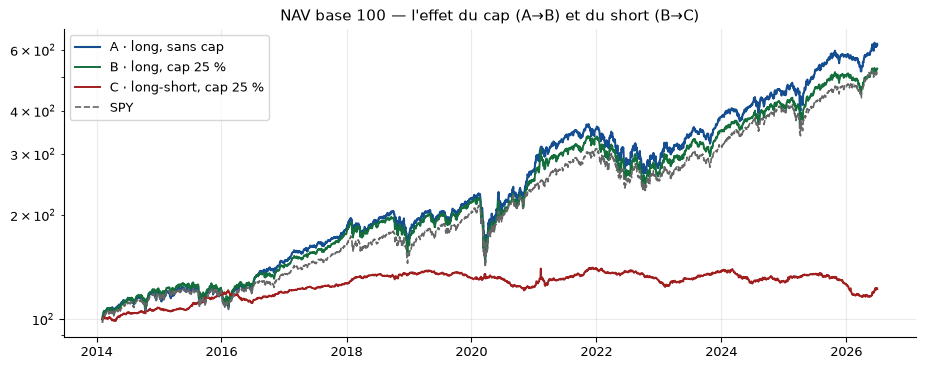

In [42]:
nav_spy2 = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index, spanA, color=BLEU,  lw=1.5, label="A · long, sans cap")
ax.plot(spanB.index, spanB, color=VERT,  lw=1.4, label="B · long, cap 25 %")
ax.plot(spanC.index, spanC, color=ROUGE, lw=1.4, label="C · long-short, cap 25 %")
ax.plot(nav_spy2.index, nav_spy2, color=GRIS, lw=1.2, ls="--", label="SPY")
ax.set_yscale("log"); ax.set_title("NAV base 100 — l'effet du cap (A→B) et du short (B→C)"); ax.legend()
plt.savefig(f"{FIGS}/extensions.png", dpi=150, bbox_inches="tight"); plt.show()

### §10bis — Deux essais de plus : **short-only** et **β glissant**

**Short-only** : on ne garde QUE la jambe short, sans position longue — on shorte les titres net-vendus.
**β glissant** : au lieu d'un seul β plein-échantillon, on l'estime sur une fenêtre glissante d'un an
pour voir si l'exposition au marché de la base reste collée à ~1 (une mesure, pas une stratégie).

In [43]:
# SHORT-ONLY : le livre short sans cap, dont on prend l'OPPOSÉ du rendement (on parie sur la baisse)
spanS0, _ = run_livre(WPO_S, np.inf)                     # livre short sans cap (comparable à la base A)
rSO = -spanS0.pct_change()                               # shorter = rendement opposé au panier net-vendu
spanSO = 100 * (1 + rSO.fillna(0)).cumprod()
print(f"short-only — NAV finale {spanSO.iloc[-1]:.0f}  (base long {spanA.iloc[-1]:.0f} · SPY {(1+r_spy.reindex(spanA.index).fillna(0)).cumprod().iloc[-1]*100:.0f})")
pd.DataFrame([bilan(spanA,  "base long (τ, réf.)"),
             bilan(spanC,  "long-short (θ=1)"),
             bilan(spanSO, "short-only (τ)")]).set_index("run").round(3)

short-only — NAV finale 16  (base long 622 · SPY 517)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
"base long (τ, réf.)",1.706,1.030,1.048,0.645,1.023,622.132,7/13
long-short (θ=1),-12.801,-3.192,-0.253,-0.164,-0.016,122.424,3/13
short-only (τ),-26.600,-3.395,-2.361,-1.186,-1.028,16.037,3/13


In [44]:
# long-short SANS cap : long sans cap (A) − short sans cap (S0), pour isoler l'effet du cap sur le long-short
rA0, rS0 = spanA.pct_change(), spanS0.pct_change()
ix0 = rA0.index.intersection(rS0.index)
spanC0 = 100 * (1 + (rA0.reindex(ix0).fillna(0) - 1.0*rS0.reindex(ix0).fillna(0))).cumprod()
print("Long-Short (θ=1) à τ — avec vs sans le cap de rotation :")
pd.DataFrame([bilan(spanC,  "long-short · AVEC cap 25 %"),
             bilan(spanC0, "long-short · SANS cap")]).set_index("run").round(3)

Long-Short (θ=1) à τ — avec vs sans le cap de rotation :


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
long-short · AVEC cap 25 %,-12.801,-3.192,-0.253,-0.164,-0.016,122.424,3/13
long-short · SANS cap,-11.308,-2.509,0.570,0.249,-0.006,148.345,4/13


β glissant 252 j — min 0.93 · médiane 1.02 · max 1.11 · plein échantillon 1.02


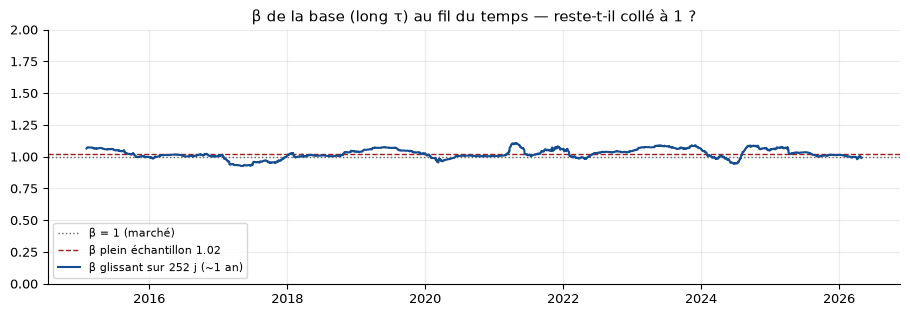

In [45]:
# β GLISSANT de la base (long τ) : β_t = cov(excès strat, excès marché)/var(excès marché) sur 1 an glissant
W_BETA = 252                                             # ~1 an de bourse
rr = spanA.pct_change().dropna()
dd = pd.DataFrame({"p": rr, "m": r_spy.reindex(rr.index)}).join(ff[["RF"]]).dropna()
yb, xb = dd.p - dd.RF, dd.m - dd.RF                      # excès stratégie / excès marché
beta_t = (yb.rolling(W_BETA).cov(xb) / xb.rolling(W_BETA).var()).dropna()
b_full = np.polyfit(xb.values, yb.values, 1)[0]
print(f"β glissant {W_BETA} j — min {beta_t.min():.2f} · médiane {beta_t.median():.2f} · max {beta_t.max():.2f} · plein échantillon {b_full:.2f}")
fig, ax = plt.subplots(figsize=(11, 3.3))
ax.axhline(1.0, color=GRIS, lw=1.0, ls=":", label="β = 1 (marché)")
ax.axhline(b_full, color=ROUGE, lw=1.0, ls="--", label=f"β plein échantillon {b_full:.2f}")
ax.plot(beta_t.index, beta_t, color=BLEU, lw=1.5, label=f"β glissant sur {W_BETA} j (~1 an)")
ax.set_ylim(0, 2); ax.set_title("β de la base (long τ) au fil du temps — reste-t-il collé à 1 ?")
ax.legend(loc="lower left", fontsize=8)
plt.savefig(f"{FIGS}/beta_glissant.png", dpi=150, bbox_inches="tight"); plt.show()

## §11 — Le vrai test : à la date de **divulgation**

Jusqu'ici le flux est fenêtré sur $\tau$ (la transaction) : on utilise une information **avant qu'elle soit
publique** → borne haute. On bascule le fenêtrage sur $\delta$ (la divulgation) : à la coupe $t$, on ne voit
que les trades **déjà divulgués** ($\delta_k \le t$). C'est la version **réplicable**.

Ce qui change : **uniquement la fenêtre du signal**. Le FIFO et $\gamma$ restent sur $\tau$ — la durée de
détention est une réalité, pas une question de date de publication. Exécution toujours au close J+1.

In [46]:
# bascule le fenêtrage sur δ (divulgation), on rebâtit la chaîne longue (sans cap, comparable au run A)
ordre_d = np.argsort(df.ide.values, kind="stable")
IW, ordreW = df.ide.values[ordre_d], ordre_d
SELd = {i: selection(i, W) for i in coupes}
ACHd = {i: acheteurs(i, SELd[i], W) for i in coupes}
WPOd = {i: poids(i, W, SELd[i], ACHd[i]) for i in coupes[:-1]}
td = np.array([len(SELd[i]) for i in coupes])
print(f"à δ — |S_t| médian {np.median(td):.0f} (vs 64 à τ) · mois vides {(td==0).sum()}/{len(td)}")
print(f"lag de divulgation δ−τ : médiane {(df.disclosure_date - df.tau).dt.days.median():.0f} j (le décalage qu'on subit en attendant que l'info soit publique)")
spanD, _ = run_livre(WPOd, np.inf)
IW, ordreW = I0, ordre                                        # on remet τ pour ne rien polluer
print(f"NAV finale — τ (borne haute) {spanA.iloc[-1]:.0f}  ·  δ (réplicable) {spanD.iloc[-1]:.0f}")

à δ — |S_t| médian 59 (vs 64 à τ) · mois vides 0/150
lag de divulgation δ−τ : médiane 27 j (le décalage qu'on subit en attendant que l'info soit publique)
NAV finale — τ (borne haute) 622  ·  δ (réplicable) 530


In [47]:
tabD = pd.DataFrame([bilan(spanA, "τ · transaction (borne haute)"),
                     bilan(spanD, "δ · divulgation (réplicable)")]).set_index("run")
tabD.round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
τ · transaction (borne haute),1.706,1.030,1.048,0.645,1.023,622.132,7/13
δ · divulgation (réplicable),0.350,0.183,-0.032,-0.019,1.010,530.210,7/13


In [48]:
# excès annuel τ vs δ (alimente le tableau annuel de la fiche)
def annuel(Vx):
    rx = Vx.pct_change().dropna()
    s = rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    m = r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    return (100*s).round(1), (100*m).round(1), (100*(s-m)).round(1)
sA,mA,xA = annuel(spanA); sD,mD,xD = annuel(spanD)
annu = pd.DataFrame({"strat_τ":sA,"SPY":mA,"excès_τ":xA,"strat_δ":sD,"excès_δ":xD})
print("excès τ:", list(xA.values)); print("excès δ:", list(xD.values))
annu

excès τ: [np.float64(-1.3), np.float64(-0.9), np.float64(9.4), np.float64(3.0), np.float64(0.9), np.float64(-3.4), np.float64(3.5), np.float64(2.0), np.float64(-3.1), np.float64(11.5), np.float64(-8.7), np.float64(10.9), np.float64(-1.6)]
excès δ: [np.float64(2.2), np.float64(0.1), np.float64(11.1), np.float64(3.7), np.float64(-2.4), np.float64(3.0), np.float64(-9.6), np.float64(13.2), np.float64(-1.6), np.float64(-3.8), np.float64(-9.4), np.float64(3.5), np.float64(-5.4)]


,strat_τ,SPY,excès_τ,strat_δ,excès_δ
Date,,,,,
2014,19.0,20.3,-1.3,22.6,2.2
2015,0.4,1.2,-0.9,1.3,0.1
2016,21.4,12.0,9.4,23.1,11.1
2017,24.7,21.7,3.0,25.4,3.7
2018,-3.7,-4.6,0.9,-7.0,-2.4
2019,27.9,31.2,-3.4,34.2,3.0
2020,21.8,18.3,3.5,8.7,-9.6
2021,30.7,28.7,2.0,41.9,13.2
2022,-21.2,-18.2,-3.1,-19.8,-1.6


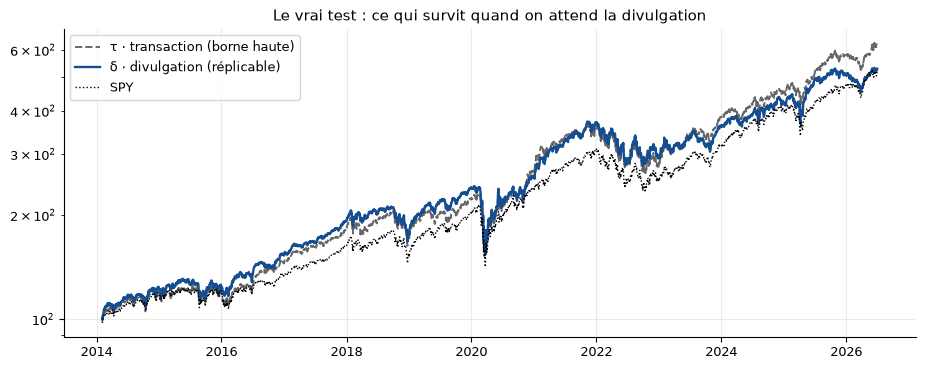

In [49]:
navspy3 = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index, spanA, color=GRIS, lw=1.4, ls="--", label="τ · transaction (borne haute)")
ax.plot(spanD.index, spanD, color=BLEU, lw=1.7, label="δ · divulgation (réplicable)")
ax.plot(navspy3.index, navspy3, color="k", lw=1.0, ls=":", label="SPY")
ax.set_yscale("log"); ax.set_title("Le vrai test : ce qui survit quand on attend la divulgation"); ax.legend()
plt.savefig(f"{FIGS}/divulgation.png", dpi=150, bbox_inches="tight"); plt.show()

### §11bis — Divulgation ET cap de rotation (les 4 coins)

On croise les deux réglages : borne du signal (τ / δ) $\times$ cap de rotation (sans / 25 %/mois). Le run
manquant est **δ + cap** = `run_livre(WPOd, TAU_MAX)`. On voit ainsi l'effet du cap séparément à τ et à δ.

In [50]:
spanD_cap, _ = run_livre(WPOd, TAU_MAX)                       # base à δ, avec cap 25 %/mois
tab4 = pd.DataFrame([bilan(spanA,     "τ · sans cap"),
                     bilan(spanB,     "τ · cap 25 %"),
                     bilan(spanD,     "δ · sans cap"),
                     bilan(spanD_cap, "δ · cap 25 %")]).set_index("run")
tab4.round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
τ · sans cap,1.706,1.030,1.048,0.645,1.023,622.132,7/13
τ · cap 25 %,0.269,0.233,-0.158,-0.116,1.014,530.993,6/13
δ · sans cap,0.350,0.183,-0.032,-0.019,1.010,530.210,7/13
δ · cap 25 %,-0.490,-0.382,-0.672,-0.540,1.004,487.341,7/13


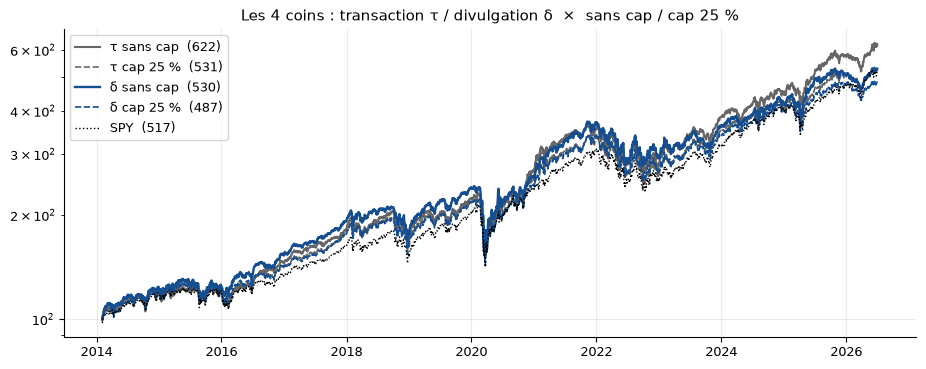

In [51]:
navspy4 = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index,     spanA,     color=GRIS, lw=1.5,          label=f"τ sans cap  ({spanA.iloc[-1]:.0f})")
ax.plot(spanB.index,     spanB,     color=GRIS, lw=1.2, ls="--", label=f"τ cap 25 %  ({spanB.iloc[-1]:.0f})")
ax.plot(spanD.index,     spanD,     color=BLEU, lw=1.7,          label=f"δ sans cap  ({spanD.iloc[-1]:.0f})")
ax.plot(spanD_cap.index, spanD_cap, color=BLEU, lw=1.2, ls="--", label=f"δ cap 25 %  ({spanD_cap.iloc[-1]:.0f})")
ax.plot(navspy4.index, navspy4, color="k", lw=1.0, ls=":",       label=f"SPY  ({navspy4.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Les 4 coins : transaction τ / divulgation δ  ×  sans cap / cap 25 %")
plt.savefig(f"{FIGS}/coins.png", dpi=150, bbox_inches="tight"); plt.show()

## §12 — D'autres pistes

Jusqu'ici, à la divulgation, le ticker suit le marché (β≈1) et l'excès tombe à ~0. On explore trois causes
possibles de ce nul, plus deux découpages rapides. **Chaque piste est mesurée à τ (borne haute) ET à δ
(réplicable)** ; ces sections ajoutent des essais au compteur de multiplicité (§12.6). Aucune n'est un verdict.

**Les leviers.** ① *horizon* (tenir plus longtemps — Pyun trouve le signal vers 300 j) · ② *comités*
(ne garder que les membres siégeant sur le comité du secteur — le prédicteur le plus documenté) · ③ *marché
neutralisé* (retirer β·marché pour voir la sélection pure) · ④ *Sénat seul* · ⑤ *dépôts tardifs*.

In [52]:
# helper — rejoue TOUTE la chaîne du signal sur un sous-ensemble de trades (mask), à τ puis à δ.
# On swappe les globals que lisent flux/selection/acheteurs (df, IW, ordreW) ; γ voyage avec les lignes
# (la purge FIFO reste calculée sur l'historique complet, §4). run_livre/poids ne touchent pas à df.
def variante(mask, W=W, tau_max=np.inf, cotes=("tau","delta")):
    # rejoue le signal sur le sous-ensemble mask ; tau_max<∞ = cap de rotation ; cotes = quelles bornes
    global df, IW, ordreW
    bak = (df, IW, ordreW)
    try:
        dv = df[mask].reset_index(drop=True)
        idxmap = {"tau": dv.i0.values, "delta": dv.ide.values}
        df = dv
        spans = {}
        for lab in cotes:
            order = np.argsort(idxmap[lab], kind="stable")
            IW, ordreW = idxmap[lab][order], order
            SELv = {i: selection(i, W) for i in coupes}
            WPv  = {i: poids(i, W, SELv[i], acheteurs(i, SELv[i], W)) for i in coupes[:-1]}
            spans[lab] = run_livre(WPv, tau_max)[0]
        return (spans.get("tau"), spans.get("delta"), int(mask.sum()))
    finally:
        df, IW, ordreW = bak

def taille_sel(mask, cote, W=W):
    # tailles |S| du signal restreint, sans lancer le backtest (pour diagnostiquer τ vs δ)
    global df, IW, ordreW
    bak = (df, IW, ordreW)
    try:
        dv = df[mask].reset_index(drop=True)
        idx = dv.i0.values if cote == "tau" else dv.ide.values
        order = np.argsort(idx, kind="stable")
        df, IW, ordreW = dv, idx[order], order
        return np.array([len(selection(i, W)) for i in coupes])
    finally:
        df, IW, ordreW = bak

# contrôle : variante(tout) doit reproduire la base (spanA / spanD)
st, sd, n = variante(pd.Series(True, index=df.index))
print(f"contrôle variante(tout) : NAV τ {st.iloc[-1]:.1f} (base {spanA.iloc[-1]:.1f}) · "
      f"NAV δ {sd.iloc[-1]:.1f} (base {spanD.iloc[-1]:.1f})  → {n:,} trades")
assert abs(st.iloc[-1]-spanA.iloc[-1])<1e-6 and abs(sd.iloc[-1]-spanD.iloc[-1])<1e-6, "le swap ne reproduit pas la base"

contrôle variante(tout) : NAV τ 622.1 (base 622.1) · NAV δ 530.2 (base 530.2)  → 113,369 trades


### §12.1 — Horizon : tenir plus longtemps

On détient, au mois $t$, la **moyenne des portefeuilles cibles des $H$ derniers mois** (cohortes
chevauchantes, chacune $1/H$) : $w^{(H)}_t = \frac{1}{H}\sum_{h=0}^{H-1} w_{t-h}$, renormalisé. $H{=}1$
redonne la base. On balaie $H \in \{1,3,6,12\}$ mois, à τ et à δ.

In [53]:
def overlap(WP, H):
    ks = sorted(WP.keys()); out = {}
    for j, k in enumerate(ks):
        agg = {}
        for jj in range(max(0, j-H+1), j+1):
            for tk, wi in WP[ks[jj]].items(): agg[tk] = agg.get(tk, 0.0) + wi
        s = sum(agg.values())
        out[k] = {tk: wi/s for tk, wi in agg.items()} if s > 0 else {}
    return out

rows_h = []
for H in [1, 3, 6, 12]:
    for lab, WP in [("τ", WPO), ("δ", WPOd)]:
        span = run_livre(overlap(WP, H), np.inf)[0]
        rows_h.append(bilan(span, f"H={H:>2} mois · {lab}"))
tab_h = pd.DataFrame(rows_h).set_index("run")
print("horizon de détention — H=1 = la base"); tab_h.round(3)

horizon de détention — H=1 = la base


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
H= 1 mois · τ,1.706,1.030,1.048,0.645,1.023,622.132,7/13
H= 1 mois · δ,0.350,0.183,-0.032,-0.019,1.010,530.210,7/13
H= 3 mois · τ,0.273,0.184,-0.430,-0.298,1.025,522.315,6/13
H= 3 mois · δ,-0.508,-0.322,-0.830,-0.607,1.012,478.144,7/13
H= 6 mois · τ,-0.533,-0.470,-0.848,-0.682,1.018,483.370,7/13
H= 6 mois · δ,-0.287,-0.244,-0.509,-0.411,1.007,499.077,7/13
H=12 mois · τ,-1.082,-1.068,-1.493,-1.256,1.021,456.417,5/13
H=12 mois · δ,-0.892,-0.787,-1.085,-0.871,1.012,468.659,6/13


### §12.2 — Comités pertinents

**L'idée.** Un élu qui siège au comité régulant un secteur a un avantage d'information sur ce secteur. On ne
garde donc, dans le signal, que les achats d'un membre siégeant sur un comité **ayant juridiction sur le
secteur GICS du titre acheté**.

**Le filtre.** À chaque membre $m$ on associe l'ensemble des secteurs couverts par ses comités :
$$\mathrm{Sec}(m) = \bigcup_{c\,\in\,\text{comités}(m)} \text{secteurs}(c)$$
Un trade $k = (m_k, i_k, \dots)$ est **retenu** si et seulement si le titre est dans la juridiction du membre :
$$k \text{ retenu} \iff \text{secteur}(i_k) \in \mathrm{Sec}(m_k)$$

**Tout le reste est IDENTIQUE à la base --- et c'est du LONG.** On rejoue la même chaîne (§5-§8) mais sur ce
sous-ensemble de trades. Flux et signal restreints (exposant $c$ = « comité ») :
$$NetBuy^{c}_{i,t} = \!\!\!\sum_{k\text{ retenu, achat}}\!\!\! A_k \;-\; \!\!\!\sum_{k\text{ retenu, vente}}\!\!\! A_k\gamma_k,
\qquad S^{c}_t = \{\, i : NetBuy^{c}_{i,t} > 0 \;\wedge\; nBuyers^{c}_{i,t} \ge 2 \,\}$$
Poids **une voix par membre**, restreint aux $K^c_t$ membres pertinents ($\mathcal{M}^c_t$ = membres retenus
ayant acheté un titre de $S^c_t$, $B^c_{m,t}$ = leurs titres) :
$$\boxed{\; w^{c}_{i,t} = \frac{1}{K^{c}_t} \sum_{m \in \mathcal{M}^{c}_t} \frac{\mathbf{1}\{i \in B^{c}_{m,t}\}}{|B^{c}_{m,t}|} \;}
\qquad \sum_i w^{c}_{i,t} = 1$$
On **achète** les titres de $S^c_t$ avec ces poids (aucune vente à découvert), on tient un mois, exécution au
close J+1 --- le moteur §7-§8 tel quel. **Seule la population de trades change.** Variante de robustesse plus
grossière : `committees_key_flag` (le membre est sur un comité « clé », sans regarder le secteur).

In [54]:
# carte comité -> secteurs GICS (juridictions les plus défendables)
COM_SEC = {
 "Financial Services":            {"Financials"},
 "Armed Services":                {"Industrials"},
 "Energy and Commerce":           {"Energy","Health Care","Communication Services","Utilities"},
 "Natural Resources":             {"Energy","Materials","Utilities"},
 "Agriculture":                   {"Consumer Staples","Materials"},
 "Transportation and Infrastructure": {"Industrials"},
 "Science, Space, and Technology":{"Information Technology"},
 "Homeland Security":             {"Industrials","Information Technology"},
 "Veterans":                      {"Health Care"},
}
def com_secteurs(s):
    if not isinstance(s, str): return set()
    out = set()
    for nom, secs in COM_SEC.items():
        if nom in s: out |= secs
    return out
comsec = df.committee_membership.map(com_secteurs)
mask_com = pd.Series([sg in cs for sg, cs in zip(df.sector_gics, comsec)], index=df.index)
mask_key = (df.committees_key_flag == True)
print(f"trades comité-pertinents (secteur) : {mask_com.sum():,} / {len(df):,} ({mask_com.mean():.1%})")
print(f"trades sur comité « clé » (flag)    : {mask_key.sum():,} / {len(df):,} ({mask_key.mean():.1%})")
carte = pd.DataFrame([{"comité (House)": k, "secteurs GICS régulés": ", ".join(sorted(v))} for k, v in COM_SEC.items()])
print("\nla carte comité → secteur :"); display(carte)
print("exemples de trades RETENUS (le titre est dans la juridiction du membre) :")
display(df[mask_com][["member_name","tk","sector_gics","op"]].head(6))

trades comité-pertinents (secteur) : 18,948 / 113,369 (16.7%)
trades sur comité « clé » (flag)    : 63,912 / 113,369 (56.4%)

la carte comité → secteur :


,comité (House),secteurs GICS régulés
0,Financial Services,Financials
1,Armed Services,Industrials
2,Energy and Commerce,"Communication Services, Energy, Health Care, U..."
3,Natural Resources,"Energy, Materials, Utilities"
4,Agriculture,"Consumer Staples, Materials"
5,Transportation and Infrastructure,Industrials
6,"Science, Space, and Technology",Information Technology
7,Homeland Security,"Industrials, Information Technology"
8,Veterans,Health Care


exemples de trades RETENUS (le titre est dans la juridiction du membre) :


,member_name,tk,sector_gics,op
11,Michael T. McCaul,TSM,Information Technology,buy
22,Michael T. McCaul,TSM,Information Technology,buy
41,Michael T. McCaul,XRX,Industrials,sell
55,Nick J. Rahall,MTZ,Industrials,sell
57,Lamar Smith,GWRE,Information Technology,buy
71,Nick J. Rahall,GE,Industrials,sell


**Un exemple d'allocation, à une coupe.** Pour lever le doute : on est bien en **long**, chaque membre
pertinent pèse $1/K^c$ et le répartit également entre ses titres. Voici une coupe réelle.

In [55]:
# EXEMPLE concret à une coupe : le portefeuille LONG comité-secteur, membre par membre
dv = df[mask_com].reset_index(drop=True); ov = np.argsort(dv.i0.values, kind="stable")
_bdf, _bIW, _bow = df, IW, ordreW
df, IW, ordreW = dv, dv.i0.values[ov], ov
ic = coupes[len(coupes)*2//3]                                  # une coupe aux deux tiers de la période
Sc = selection(ic, W); Ac = acheteurs(ic, Sc, W); wc = poids(ic, W, Sc, Ac)
df, IW, ordreW = _bdf, _bIW, _bow                             # on remet la population complète
Kc = len(Ac)
print(f"coupe du {cal[ic].date()} — {Kc} membres pertinents · {len(Sc)} titres retenus · LONG seul · Σ w = {sum(wc.values()):.4f}")
ex = pd.DataFrame([{"membre": df.loc[df.bioguide_id==m,'member_name'].iat[0],
                    "|B_m| (nb titres)": len(v), "poids/titre = 1/(K·|B_m|)": 1/(Kc*len(v)),
                    "ses titres retenus": ", ".join(v[:5])} for m, v in list(Ac.items())[:8]])
display(ex.round(4))

coupe du 2022-05-31 — 4 membres pertinents · 4 titres retenus · LONG seul · Σ w = 1.0000


,membre,|B_m| (nb titres),poids/titre = 1/(K·|B_m|),ses titres retenus
0,Diana Harshbarger,1,0.2500,GNRC
1,Rohit Khanna,4,0.0625,"DOV, FDX, GNRC, UPS"
2,James R. Langevin,1,0.2500,GNRC
3,Michael T. McCaul,3,0.0833,"DOV, FDX, UPS"


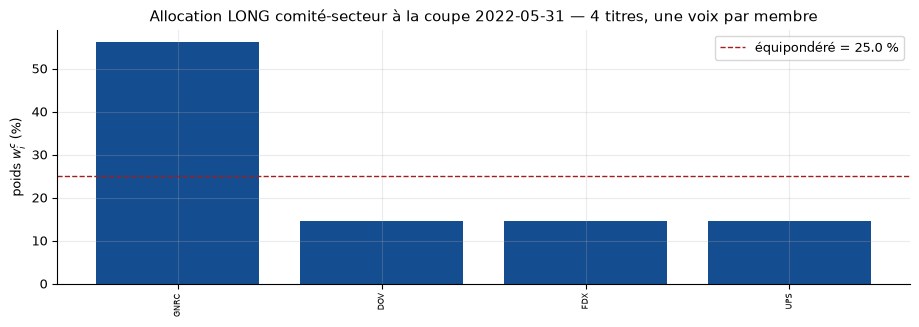

In [56]:
# les poids finaux w^c_i à cette coupe — la 'photo' de l'allocation
ws = pd.Series(wc).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 3.3))
ax.bar(range(len(ws)), ws.values*100, color=BLEU)
ax.axhline(100/len(ws), color=ROUGE, ls="--", lw=1, label=f"équipondéré = {100/len(ws):.1f} %")
ax.set_xticks(range(len(ws))); ax.set_xticklabels(ws.index, rotation=90, fontsize=6)
ax.set_ylabel("poids $w^c_i$ (%)"); ax.set_title(f"Allocation LONG comité-secteur à la coupe {cal[ic].date()} — {len(ws)} titres, une voix par membre")
ax.legend(); plt.savefig(f"{FIGS}/comites_alloc.png", dpi=150, bbox_inches="tight"); plt.show()

In [57]:
# les runs (on GARDE les NAV pour la figure) : comité-secteur et comité-clé, à τ et δ
stc, sdc, nc = variante(mask_com)
stk, sdk, nk = variante(mask_key)
tab_c = pd.DataFrame([bilan(stc, "comité-secteur · τ"), bilan(sdc, "comité-secteur · δ"),
                      bilan(stk, "comité-clé (flag) · τ"), bilan(sdk, "comité-clé (flag) · δ")]).set_index("run")
print(f"comité-secteur : {nc:,} trades · comité-clé : {nk:,} trades · base τ NAV 622 / δ NAV 530 pour comparaison")
display(tab_c.round(3))

comité-secteur : 18,948 trades · comité-clé : 63,912 trades · base τ NAV 622 / δ NAV 530 pour comparaison


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
comité-secteur · τ,7.667,1.599,5.947,1.352,1.001,1102.350,9/13
comité-secteur · δ,-3.645,-0.992,-3.137,-0.752,0.991,325.779,5/13
comité-clé (flag) · τ,1.739,0.697,0.612,0.283,1.040,608.888,7/13
comité-clé (flag) · δ,-1.053,-0.557,-1.428,-0.649,1.033,454.133,6/13


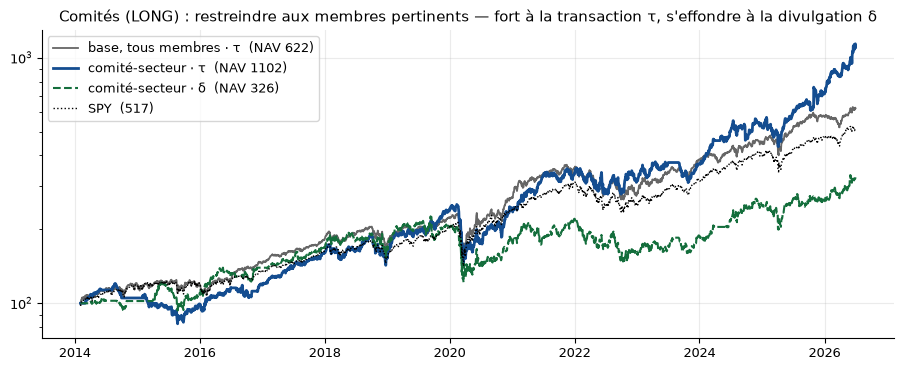

In [58]:
# LA figure : restreindre aux comités (LONG) double la NAV à τ, mais s'effondre à δ
navspy = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index, spanA, color=GRIS, lw=1.3,           label=f"base, tous membres · τ  (NAV {spanA.iloc[-1]:.0f})")
ax.plot(stc.index,   stc,   color=BLEU, lw=2.0,           label=f"comité-secteur · τ  (NAV {stc.iloc[-1]:.0f})")
ax.plot(sdc.index,   sdc,   color=VERT, lw=1.5, ls="--",  label=f"comité-secteur · δ  (NAV {sdc.iloc[-1]:.0f})")
ax.plot(navspy.index, navspy, color="k", lw=1.0, ls=":",  label=f"SPY  ({navspy.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Comités (LONG) : restreindre aux membres pertinents — fort à la transaction τ, s'effondre à la divulgation δ")
plt.savefig(f"{FIGS}/comites.png", dpi=150, bbox_inches="tight"); plt.show()

### §12.2bis — Diagnostic : ce +7,7 % à τ est-il réel ?

Trois doutes à lever par la mesure : **(a)** la carte comité→secteur est-elle un vrai filtre d'information,
ou un simple **pari sectoriel** ? **(b)** pourquoi l'effondrement à δ ? **(c)** que donne le **cap** ?

part des trades de chaque secteur que le filtre comité-secteur RETIENT :


,retenus,part,total
sector_gics,,,
Industrials,8857,0.634,13971
Information Technology,3985,0.202,19708
Materials,840,0.182,4628
Consumer Staples,1082,0.132,8181
Energy,736,0.114,6470
Health Care,1699,0.112,15131
Utilities,251,0.110,2286
Financials,1165,0.070,16681
Communication Services,333,0.038,8748


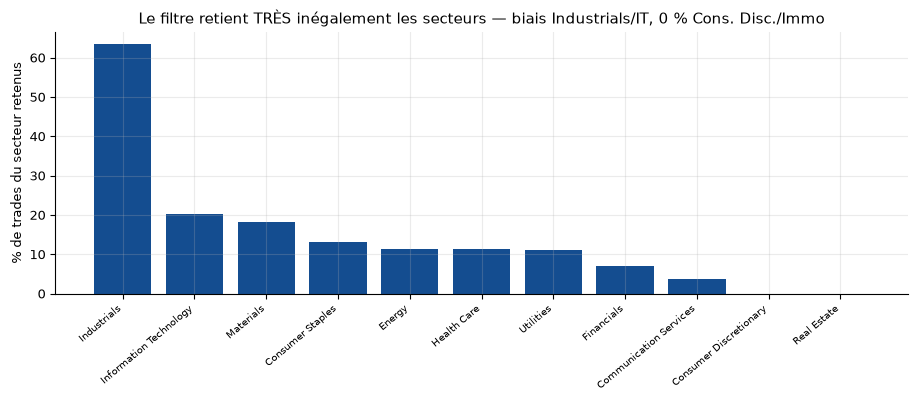

In [59]:
# (a) composition sectorielle des trades retenus — le filtre est-il équilibré ?
comp = (df.assign(ret=mask_com).groupby("sector_gics").ret
          .agg(retenus="sum", part="mean", total="size").sort_values("part", ascending=False))
print("part des trades de chaque secteur que le filtre comité-secteur RETIENT :")
display(comp.round(3))
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(comp.index, comp["part"]*100, color=BLEU)
ax.set_ylabel("% de trades du secteur retenus"); ax.set_xticklabels(comp.index, rotation=40, ha="right", fontsize=7)
ax.set_title("Le filtre retient TRÈS inégalement les secteurs — biais Industrials/IT, 0 % Cons. Disc./Immo")
plt.savefig(f"{FIGS}/comites_secteurs.png", dpi=150, bbox_inches="tight"); plt.show()

**Placebo.** On casse le lien réel *membre↔comité* : chaque membre reçoit le comité d'un autre membre
(permutation aléatoire, graine fixe), et on rejoue à τ. Si l'excès reste voisin du $+7,7\,\%$ réel, c'est
que le résultat vient du **tilt sectoriel** (le filtre surpondère Industrials/IT quel que soit qui siège où),
pas de l'information de comité. On répète 20 fois.

excès τ RÉEL (vraie affectation comité) : +7.67 %/an
placebo (comité au hasard, 20 tirages) : médiane +0.41 · min -8.31 · max +8.31 %/an
le réel dépasse 90% des placebos


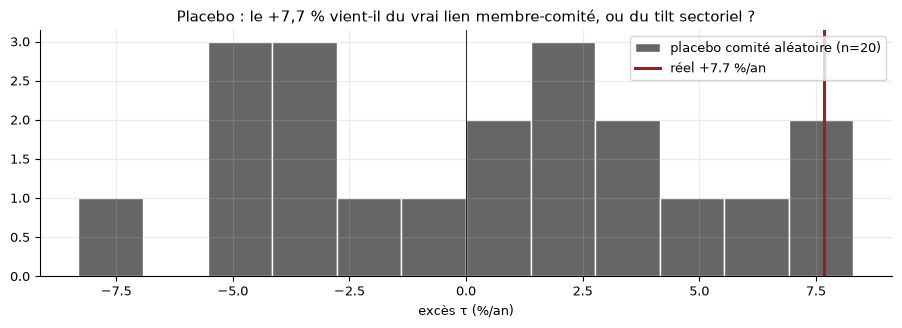

In [60]:
def run_tau_only(mask):
    st, _, _ = variante(mask, cotes=("tau",)); return st
np.random.seed(7)
memb = df.groupby("bioguide_id").committee_membership.first()
reel = bilan(stc, "reel")["excès %/an"]
placebo = []
for rep in range(20):
    perm = pd.Series(np.random.permutation(memb.values), index=memb.index)
    fake = df.bioguide_id.map(perm).map(com_secteurs)
    m = pd.Series([sg in cs for sg, cs in zip(df.sector_gics, fake)], index=df.index)
    if m.sum() == 0: continue
    placebo.append(bilan(run_tau_only(m), "p")["excès %/an"])
placebo = np.array(placebo)
print(f"excès τ RÉEL (vraie affectation comité) : {reel:+.2f} %/an")
print(f"placebo (comité au hasard, {len(placebo)} tirages) : médiane {np.median(placebo):+.2f} · "
      f"min {placebo.min():+.2f} · max {placebo.max():+.2f} %/an")
print(f"le réel dépasse {(placebo < reel).mean():.0%} des placebos")
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.hist(placebo, bins=12, color=GRIS, edgecolor="white", label=f"placebo comité aléatoire (n={len(placebo)})")
ax.axvline(reel, color=ROUGE, lw=2.2, label=f"réel {reel:+.1f} %/an")
ax.axvline(0, color="k", lw=0.6); ax.set_xlabel("excès τ (%/an)")
ax.set_title("Placebo : le +7,7 % vient-il du vrai lien membre-comité, ou du tilt sectoriel ?")
ax.legend(); plt.savefig(f"{FIGS}/comites_placebo.png", dpi=150, bbox_inches="tight"); plt.show()

**(b) L'effondrement τ→δ.** Taille du signal restreint, mois vides, et excès **année par année** — pour
voir si le $-3,65\,\%$ à δ est large ou porté par 1-2 années / un petit échantillon.

|S^c| médian — τ 4 · δ 4
mois vides   — τ 12/150 · δ 15/150   |   mois < 3 titres — τ 47 · δ 48

excès annuel comité-secteur — moyennes τ +7.68 · δ -3.66


,excès_τ (%),excès_δ (%)
Date,,
2014,-15.2,-18.2
2015,-7.2,5.1
2016,7.9,16.5
2017,13.4,-1.1
2018,0.6,3.3
2019,23.9,-9.0
2020,-16.6,-30.0
2021,10.4,-5.7
2022,12.0,-9.5


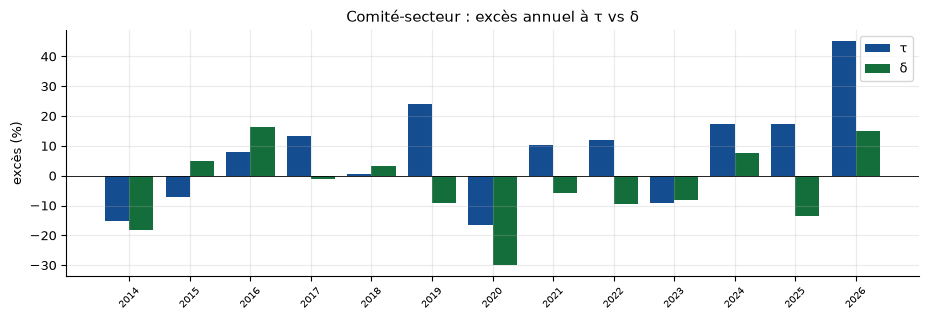

In [61]:
tSt, tSd = taille_sel(mask_com, "tau"), taille_sel(mask_com, "delta")
print(f"|S^c| médian — τ {np.median(tSt):.0f} · δ {np.median(tSd):.0f}")
print(f"mois vides   — τ {(tSt==0).sum()}/{len(tSt)} · δ {(tSd==0).sum()}/{len(tSd)}   |   "
      f"mois < 3 titres — τ {(tSt<3).sum()} · δ {(tSd<3).sum()}")
xt = annuel(stc)[2]; xd = annuel(sdc)[2]
annu_c = pd.DataFrame({"excès_τ (%)": xt, "excès_δ (%)": xd})
print(f"\nexcès annuel comité-secteur — moyennes τ {xt.mean():+.2f} · δ {xd.mean():+.2f}")
display(annu_c)
fig, ax = plt.subplots(figsize=(11, 3.2))
yy = annu_c.index.astype(str); x = np.arange(len(yy))
ax.bar(x-0.2, annu_c["excès_τ (%)"], 0.4, color=BLEU, label="τ")
ax.bar(x+0.2, annu_c["excès_δ (%)"], 0.4, color=VERT, label="δ")
ax.axhline(0, color="k", lw=0.6); ax.set_xticks(x); ax.set_xticklabels(yy, rotation=45, fontsize=7)
ax.set_ylabel("excès (%)"); ax.set_title("Comité-secteur : excès annuel à τ vs δ"); ax.legend()
plt.savefig(f"{FIGS}/comites_annuel.png", dpi=150, bbox_inches="tight"); plt.show()

**(c) Le cap sur les comités.** comité-secteur avec cap de rotation 25 %/mois, à τ et δ.

In [62]:
stc_cap, sdc_cap, _ = variante(mask_com, tau_max=TAU_MAX)
pd.DataFrame([bilan(stc,     "comité-secteur · τ  (sans cap)"),
             bilan(stc_cap, "comité-secteur · τ  (cap 25 %)"),
             bilan(sdc,     "comité-secteur · δ  (sans cap)"),
             bilan(sdc_cap, "comité-secteur · δ  (cap 25 %)")]).set_index("run").round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
comité-secteur · τ (sans cap),7.667,1.599,5.947,1.352,1.001,1102.350,9/13
comité-secteur · τ (cap 25 %),2.777,0.881,2.097,0.703,1.017,670.816,8/13
comité-secteur · δ (sans cap),-3.645,-0.992,-3.137,-0.752,0.991,325.779,5/13
comité-secteur · δ (cap 25 %),-2.385,-0.987,-1.899,-0.646,1.020,388.781,6/13


### §12.3 — Marché neutralisé : isoler la sélection

Le β≈1 masque toute sélection. On retire, jour après jour, $\hat\beta_t \cdot (r_{\text{SPY}}-r_f)$
($\hat\beta_t$ = β glissant 252 j) : le résidu $(r-r_f) - \hat\beta_t (r_{\text{SPY}}-r_f)$ est le
**P\&L de sélection pur**. On le mesure sur la base, à τ et à δ. $\alpha$/an, $t_\alpha$, volatilité.

In [63]:
def neutre(span, nom):
    r = span.pct_change().dropna()
    dd = pd.DataFrame({"p": r, "m": r_spy.reindex(r.index)}).join(ff[["RF"]]).dropna()
    yy, xx = dd.p - dd.RF, dd.m - dd.RF
    b_full = np.polyfit(xx.values, yy.values, 1)[0]
    beta = (yy.rolling(252).cov(xx) / xx.rolling(252).var()).fillna(b_full)
    resid = (yy - beta*xx).dropna()
    t = resid.mean()/(resid.std(ddof=1)/np.sqrt(len(resid)))
    nav = 100*(1+resid).cumprod().iloc[-1]
    return {"run": nom, "α %/an": 252*resid.mean()*100, "t_α": t,
            "vol %/an": resid.std()*np.sqrt(252)*100, "NAV sélection": nav}
tab_n = pd.DataFrame([neutre(spanA, "base neutralisée · τ"),
                      neutre(spanD, "base neutralisée · δ")]).set_index("run")
print("après retrait de β·marché : ce qui reste = sélection pure"); tab_n.round(3)

après retrait de β·marché : ce qui reste = sélection pure


,α %/an,t_α,vol %/an,NAV sélection
run,,,,
base neutralisée · τ,1.080,0.665,5.678,111.884
base neutralisée · δ,0.031,0.019,5.797,98.346


### §12.4 / §12.5 — Sénat seul · dépôts tardifs

**Sénat** (Lazzaretto : signal plus fort à la chambre haute, mais petit échantillon → puissance limitée).
**Tardifs** : trades déposés en retard (`flag_late_filing`) — hypothèse d'un trade qu'on préfère cacher.

In [64]:
rows_f = []
for nom, m in [("Sénat seul", df.chamber == "senate"), ("dépôts tardifs", df.flag_late_filing == True)]:
    st, sd, n = variante(m)
    print(f"{nom} : {n:,} trades")
    rows_f += [bilan(st, f"{nom} · τ"), bilan(sd, f"{nom} · δ")]
tab_f = pd.DataFrame(rows_f).set_index("run")
tab_f.round(3)

Sénat seul : 9,246 trades


dépôts tardifs : 13,037 trades


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
Sénat seul · τ,-2.540,-0.402,-0.745,-0.155,0.833,359.002,6/13
Sénat seul · δ,-3.722,-0.572,1.779,0.326,0.620,287.046,6/13
dépôts tardifs · τ,2.061,0.492,4.470,0.865,0.895,632.524,7/13
dépôts tardifs · δ,-8.252,-1.983,-0.106,-0.027,0.389,199.782,4/13


### §12.6 — Récapitulatif et multiplicité

Toutes les pistes côte à côte. **Déclaration honnête** : ces essais s'ajoutent au compteur — plus on teste,
plus un $t$ élevé peut sortir par hasard. On lit chaque $t$ face au nombre total d'essais (E$[\max t]$ croît
avec le nombre de tirages). Le run revendiquable reste **δ** (réplicable) ; τ est une borne haute.

In [65]:
recap = pd.concat([tab_h, tab_c, tab_f]).round(3)
n_essais = len(recap) + 2                      # + les 2 neutralisées
import math
print(f"nombre d'essais §12 : {n_essais}  →  E[max |t|] sous H0 ≈ {math.sqrt(2*math.log(n_essais)):.2f} (bruit)")
# le meilleur candidat à δ (hors base), pour l'œil — PAS un verdict
d = recap[recap.index.str.endswith('δ')].copy()
d["|t|"] = d["t"].abs()
print("\nmeilleurs |t| à δ :")
display(d.sort_values("|t|", ascending=False)[["excès %/an","t","α %/an","β","NAV"]].head(6))
recap

nombre d'essais §12 : 18  →  E[max |t|] sous H0 ≈ 2.40 (bruit)

meilleurs |t| à δ :


,excès %/an,t,α %/an,β,NAV
run,,,,,
dépôts tardifs · δ,-8.252,-1.983,-0.106,0.389,199.782
comité-secteur · δ,-3.645,-0.992,-3.137,0.991,325.779
H=12 mois · δ,-0.892,-0.787,-1.085,1.012,468.659
Sénat seul · δ,-3.722,-0.572,1.779,0.620,287.046
comité-clé (flag) · δ,-1.053,-0.557,-1.428,1.033,454.133
H= 3 mois · δ,-0.508,-0.322,-0.830,1.012,478.144


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
H= 1 mois · τ,1.706,1.030,1.048,0.645,1.023,622.132,7/13
H= 1 mois · δ,0.350,0.183,-0.032,-0.019,1.010,530.210,7/13
H= 3 mois · τ,0.273,0.184,-0.430,-0.298,1.025,522.315,6/13
H= 3 mois · δ,-0.508,-0.322,-0.830,-0.607,1.012,478.144,7/13
H= 6 mois · τ,-0.533,-0.470,-0.848,-0.682,1.018,483.370,7/13
H= 6 mois · δ,-0.287,-0.244,-0.509,-0.411,1.007,499.077,7/13
H=12 mois · τ,-1.082,-1.068,-1.493,-1.256,1.021,456.417,5/13
H=12 mois · δ,-0.892,-0.787,-1.085,-0.871,1.012,468.659,6/13
comité-secteur · τ,7.667,1.599,5.947,1.352,1.001,1102.350,9/13


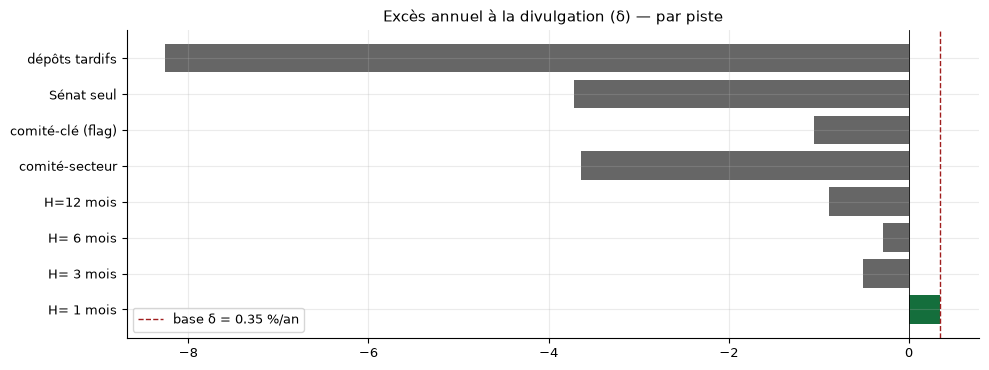

In [66]:
# figure : excès annuel (δ) par piste vs la base — voir si une piste décolle
fig, ax = plt.subplots(figsize=(11, 4))
base_d = bilan(spanD, "base δ")["excès %/an"]
lab = [i.replace(' · δ','') for i in recap.index if i.endswith('δ')]
val = [recap.loc[i,"excès %/an"] for i in recap.index if i.endswith('δ')]
ax.barh(lab, val, color=[VERT if v>base_d else GRIS for v in val])
ax.axvline(base_d, color=ROUGE, ls="--", lw=1, label=f"base δ = {base_d:.2f} %/an")
ax.axvline(0, color="k", lw=0.6)
ax.set_title("Excès annuel à la divulgation (δ) — par piste"); ax.legend()
plt.savefig(f"{FIGS}/pistes.png", dpi=150, bbox_inches="tight"); plt.show()

## §16 — La méthode retenue

Les sections précédentes répondent à « **que fait le fonds ?** » (fidélité). Celle-ci répond à l'autre question :
« **que faut-il faire de cette donnée ?** » --- et elle ne propose **qu'une seule méthode**, pas un menu.

**Le fait qui commande tout.** À la date de divulgation $\delta$ --- la seule où l'on peut investir --- aucun levier
testé dans ce notebook ne bat le marché de façon démontrable : ticker « une voix par membre » $+0{,}35$ \%/an
($t$ 0,18), horizon 3/6/12 mois négatif, comités $-3{,}65$, Sénat $-3{,}72$, dépôts tardifs $-8{,}25$,
long-short $+0{,}92$ ($t$ 0,60), short-only NAV 16. **Le seul levier qui ait jamais fait une différence est la
pondération** : le score $\$\times$ élus donne $+2{,}98$ \%/an là où « une voix par membre » donne $+0{,}35$ \%.
On construit donc la méthode autour de ce levier-là, et on mesure ce qu'elle vaut --- sans promettre qu'elle gagne.

### La spécification

À chaque fin de mois $t$, pour le parti $P$, sur les déclarations **divulguées** dans $(t-W,\,t]$, $W=756$ j :

1. **filtre anti-bruit** --- on écarte toute opération appartenant à un dépôt de $n_k \ge \theta$ opérations du
   même élu le même jour de divulgation ($\theta = 50$) ;
2. $\displaystyle B_i=\!\!\sum_{k\in\mathcal K^P(t),\,i(k)=i}\!\! A_k$ (les dollars, milieu de fourchette) et
   $m_i=\#\{m(k)\}$ (les élus distincts) ;
3. **score** $s_i = B_i\,m_i$ ;
4. **univers** $\mathcal U(t)$ = les $N=150$ plus grands $s_i$ parmi les titres cotés et vivants ;
5. **poids** : $v_i = s_i/\sum_{j\in\mathcal U}s_j$, puis le plafond par **remplissage par niveau**
   $$w_i=\min(c,\;\lambda v_i),\qquad \lambda\ \text{tel que}\ \sum_i w_i=1,\qquad c=8{,}5\ \%$$
   $\lambda\mapsto\sum_i\min(c,\lambda v_i)$ est continue croissante de 1 vers $|\mathcal U|c$ : $\lambda$ existe
   et est **unique** dès que $|\mathcal U|\ge\lceil 1/c\rceil=12$. C'est le point fixe de la redistribution au
   prorata itérée (`cap_poids`) --- la cellule de validation vérifie cette caractérisation.
6. exécution au **close J+1**, parts figées jusqu'à la coupe suivante (les poids **dérivent**).

### Les constantes sont fixées hors performance

| | valeur | pourquoi --- **aucune n'est un réglage sur nos rendements** |
|---|---|---|
| $W$ | 756 j | la fenêtre 3 ans du prospectus |
| $A_k$ | milieu de fourchette | règle publiée (Cooper) |
| date | $\delta$ | $\tau$ n'est pas investissable |
| $N$ | 150 | cardinalité annoncée du fonds (100--200) |
| $c$ | 8,5 \% | sans plafond, NVDA monte à 37 \% et $N_{\text{eff}}$ tombe à 6 (§13.3) |
| $\theta$ | **50** | la description de Venuto (« *300 trades … 5 shares … just a rebalance* ») |
| fréquence | mensuelle | l'hebdomadaire donne 22,3 contre 22,6 \% (§14.2) |

### Les runs, déclarés avant de les lancer
**2** la méthode ($\theta=50$), deux partis · **2** le contrôle ($\theta=\infty$), qui doit **reproduire
exactement** `poids_parti` (NAV 672,3 / 612,2) · **6** la décomposition de la pondération **à univers identique**
($w\propto B_i$ seul, $w\propto m_i$ seul, équipondéré) · **6** la sensibilité à $\theta$.
La décomposition **n'est pas une sélection** : elle répond à « le $+2{,}98$ vient-il des dollars ou des élus ? »,
et le verdict de la méthode se lit sur la ligne du score. Le balayage de $\theta$ est **publié en entier**, et
**le verdict se lit à $\theta=50$** --- il montre la pente, il ne sert pas à choisir.

In [125]:
# ── §16 · la méthode : poids_parti + le filtre anti-bruit, et un axe pour isoler la pondération ──
SEUIL_BRUIT = 50          # DÉCLARÉ AVANT tout calcul de rendement (description de Venuto, pas un réglage)

def poids_methode(i1, parti, topN=150, cap=0.085, seuil=SEUIL_BRUIT, mode="score"):
    # identique a poids_parti (3 ans sur δ, achats, score = $ × élus, top-N, cap) + le filtre anti-bruit.
    # `mode` ne change QUE la ponderation : l'univers reste defini par le score complet.
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy") & (g.taille_depot < seuil)]
    if not len(g): return {}
    g       = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    buy     = g.groupby("tkm").A.sum()
    breadth = g.groupby("tkm").bioguide_id.nunique().reindex(buy.index)
    score   = (buy * breadth).dropna()
    score   = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score   = score.sort_values(ascending=False).head(topN)          # ← l'UNIVERS, toujours par le score
    if not len(score) or score.sum() <= 0: return {}
    w = {"score":   score,
         "dollars": buy.reindex(score.index),
         "elus":    breadth.reindex(score.index).astype(float),
         "equal":   pd.Series(1.0, index=score.index)}[mode]
    if w.sum() <= 0: return {}
    return cap_poids(w / w.sum(), cap).to_dict()

def cibles_methode(parti, **kw):                       # les poids CIBLES, calculés une fois et réutilisables
    return {i: poids_methode(i, parti, **kw) for i in coupes[:-1]}

def serie_methode(parti, tau_max=np.inf, cout_bps=0.0, **kw):
    return run_livre(cibles_methode(parti, **kw), tau_max, cout_bps=cout_bps)[0]

PARTIS = [("Democrat", "NANC"), ("Republican", "GOP")]
SER = {}
for parti, nom in PARTIS:
    SER[(nom, "methode θ=50")]  = serie_methode(parti)
    SER[(nom, "contrôle θ=∞")]  = serie_methode(parti, seuil=np.inf)
print("méthode et contrôle calculés pour les deux partis")

méthode et contrôle calculés pour les deux partis


In [126]:
# VALIDATION §16 — le contrôle doit REPRODUIRE poids_parti, et le plafond doit être un remplissage par niveau
for parti, nom, att in [("Democrat", "NANC", span_nanc), ("Republican", "GOP", span_gop)]:
    a = SER[(nom, "contrôle θ=∞")]
    assert abs(a.iloc[-1] - att.iloc[-1]) < 1e-9, f"{nom} : contrôle {a.iloc[-1]:.1f} ≠ poids_parti {att.iloc[-1]:.1f}"
    for i in coupes[10:120:37]:
        x, y = poids_methode(i, parti, seuil=np.inf), poids_parti(i, parti)
        assert set(x) == set(y) and max(abs(x[k]-y[k]) for k in x) < 1e-12, f"{nom} coupe {i}"
print(f"✅ contrôle θ=∞ ≡ poids_parti — NAV {SER[('NANC','contrôle θ=∞')].iloc[-1]:.1f} / "
      f"{SER[('GOP','contrôle θ=∞')].iloc[-1]:.1f} (attendu 672,3 / 612,2)")

# Σw = 1, et le plafond est bien w_i = min(c, λ v_i) : le rapport w/v est CONSTANT hors titres plafonnés
c, ecarts, nplaf = 0.085, [], 0
for i in coupes[10:140:13]:
    w = poids_methode(i, "Democrat")
    if not w: continue
    assert abs(sum(w.values()) - 1) < 1e-9, f"Σw ≠ 1 à la coupe {i}"        # poids_parti somme à 1
    v = poids_methode(i, "Democrat", cap=1.0)                  # les poids bruts, sans plafond
    libres = [k for k in w if w[k] < c - 1e-9]
    nplaf += len(w) - len(libres)
    if len(libres) > 1:
        lam = [w[k]/v[k] for k in libres]
        ecarts.append(max(lam) - min(lam))
    if len(w) >= math.ceil(1/c):
        assert max(w.values()) <= c + 1e-9, f"plafond dépassé à la coupe {i}"
print(f"✅ Σw = 1 · plafond respecté · λ constant sur les titres libres "
      f"(écart max {max(ecarts):.2e}) · {nplaf} titres plafonnés sur 10 coupes")

# ce que le filtre retire, et la non-régression des ancres
ach = df[(df.op == 'buy')]
for parti, nom in PARTIS:
    a = ach[ach.party == parti]
    part = 100 * a[a.taille_depot >= SEUIL_BRUIT].A.sum() / a.A.sum()
    print(f"   {nom} : le filtre θ={SEUIL_BRUIT} écarte {part:.0f} % du $ acheté")
assert abs(span_nanc.iloc[-1]-672.3) < 1 and abs(span_gop.iloc[-1]-612.2) < 1, "ancres A déplacées"
assert abs(spanA.iloc[-1]-622.1) < 1 and abs(spanD.iloc[-1]-530.2) < 1, "ancres ticker déplacées"
print("✅ non-régression : A 672/612 · ticker τ 622 · ticker δ 530 — inchangées")

✅ contrôle θ=∞ ≡ poids_parti — NAV 672.3 / 612.2 (attendu 672,3 / 612,2)
✅ Σw = 1 · plafond respecté · λ constant sur les titres libres (écart max 3.55e-15) · 42 titres plafonnés sur 10 coupes


   NANC : le filtre θ=50 écarte 54 % du $ acheté
   GOP : le filtre θ=50 écarte 58 % du $ acheté
✅ non-régression : A 672/612 · ticker τ 622 · ticker δ 530 — inchangées


In [127]:
# ── les 6 runs de décomposition de la pondération (univers identique) ──
for parti, nom in PARTIS:
    for mode in ["dollars", "elus", "equal"]:
        SER[(nom, {"dollars":"$ seuls","elus":"élus seuls","equal":"équipondéré"}[mode])] = \
            serie_methode(parti, mode=mode)

# ⚠ DÉCOMPOSITION ≠ PROGRESSION. Ci-dessus, on part de la méthode COMPLÈTE (filtre θ=50 compris) et on ne
# remplace QUE la pondération : c'est ce qu'il faut pour répondre à « le +2,98 vient-il des $ ou des élus ? ».
# Mais pour raconter « on ajoute un geste à la fois » (M2 → M3 → M4), M2 doit être les dollars SANS le filtre —
# sinon M2 → M3 changerait deux choses en même temps, et M4 ajouterait un filtre déjà présent en M2.
for parti, nom in PARTIS:
    SER[(nom, "dollars sans filtre")] = serie_methode(parti, mode="dollars", seuil=np.inf)

ORD = ["methode θ=50", "contrôle θ=∞", "$ seuls", "dollars sans filtre", "élus seuls", "équipondéré"]
RES = pd.DataFrame([bilan_ic(SER[(nom, k)], f"{nom} — {k}") for nom, _ in [(n,p) for p,n in PARTIS]
                    for k in ORD]).set_index("run")
RES = RES[["excès %/an", "t", "IC bas", "IC haut", "α %/an", "t_α", "β", "NAV", "ann. gagnantes"]].round(2)
print("Base de comparaison : SPY NAV %.0f\n" % (1+r_spy).cumprod().mul(100).iloc[-1])
display(RES)

Base de comparaison : SPY NAV 752



,excès %/an,t,IC bas,IC haut,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,,,
NANC — methode θ=50,4.55,1.17,-3.89,13.00,0.90,0.43,1.15,698.26,9/13
NANC — contrôle θ=∞,2.98,1.47,-1.44,7.40,1.26,1.06,1.08,672.35,9/13
NANC — $ seuls,3.58,0.99,-4.27,11.42,0.40,0.22,1.13,650.08,8/13
NANC — dollars sans filtre,1.35,1.00,-1.60,4.30,0.31,0.33,1.05,584.39,8/13
NANC — élus seuls,0.33,0.33,-1.86,2.52,-0.10,-0.10,1.02,537.89,7/13
NANC — équipondéré,-0.67,-0.58,-3.21,1.87,-0.91,-0.68,1.01,482.79,5/13
GOP — methode θ=50,1.52,1.04,-1.66,4.69,1.62,1.24,0.98,634.91,7/13
GOP — contrôle θ=∞,1.24,1.62,-0.42,2.90,1.12,1.08,1.00,612.25,10/13
GOP — $ seuls,1.51,0.58,-4.15,7.16,1.19,0.57,0.99,612.96,8/13


In [128]:
# ── sensibilité au seuil : publiée en ENTIER, mais le verdict se lit à θ = 50 ──
SEUILS = [10, 20, 50, 100, np.inf]
sens = []
for parti, nom in PARTIS:
    for th in SEUILS:
        s_ = SER.get((nom, "methode θ=50")) if th == 50 else \
             SER.get((nom, "contrôle θ=∞")) if th == np.inf else serie_methode(parti, seuil=th)
        b = bilan_ic(s_, f"{nom} θ={th}")
        a = ach[ach.party == parti]
        sens.append({"fonds": nom, "θ": ("∞" if th == np.inf else th),
                     "$ écarté %": round(100*a[a.taille_depot >= th].A.sum()/a.A.sum()),
                     "excès %/an": round(b["excès %/an"], 2), "t": round(b["t"], 2),
                     "β": round(b["β"], 2), "NAV": round(b["NAV"])})
SENS = pd.DataFrame(sens)
print("Sensibilité au seuil — le verdict de la méthode se lit à θ = 50, ce balayage ne sert pas à choisir :")
display(SENS.set_index(["fonds", "θ"]))

# concentration de la méthode, et multiplicité
print("\nConcentration à la dernière coupe :")
display(pd.DataFrame([{"portefeuille": nom, "titres": len(w), "max w %": a_, "top-5 %": b_, "N_eff": c_}
                      for parti, nom in PARTIS
                      for w in [poids_methode(coupes[-2], parti)]
                      for a_, b_, c_ in [conc(100*pd.Series(w).sort_values(ascending=False))]]).set_index("portefeuille"))   # conc attend des %
N_ESSAIS = 76 + len(SENS)          # appels bilan/bilan_ic du notebook + les runs de sensibilité du §16
print(f"\n⚠ multiplicité : le notebook produit maintenant ≈ {N_ESSAIS} bilans distincts → "
      f"E[max |t|] ≈ √(2·ln {N_ESSAIS}) = {np.sqrt(2*np.log(N_ESSAIS)):.2f} sous H₀. "
      f"Tout t rapporté ici doit être lu contre CE seuil, pas contre 1,96.")

Sensibilité au seuil — le verdict de la méthode se lit à θ = 50, ce balayage ne sert pas à choisir :


$ écarté %  excès %/an     t     β  NAV
fonds θ                                           
NANC  10           66        4.11  0.97  1.14  641
      20           62        3.97  0.96  1.14  637
      50           54        4.55  1.17  1.15  698
      100          48        4.09  1.17  1.13  688
      ∞             0        2.98  1.47  1.08  672
GOP   10           85        2.94  1.65  0.99  745
      20           71        2.00  1.30  0.99  669
      50           58        1.52  1.04  0.98  635
      100          36        1.67  1.71  0.99  647
      ∞             0        1.24  1.62  1.00  612


Concentration à la dernière coupe :


,titres,max w %,top-5 %,N_eff
portefeuille,,,,
NANC,150,8.5,42.5,17.0
GOP,150,8.5,31.4,33.2



⚠ multiplicité : le notebook produit maintenant ≈ 86 bilans distincts → E[max |t|] ≈ √(2·ln 86) = 2.98 sous H₀. Tout t rapporté ici doit être lu contre CE seuil, pas contre 1,96.


### §16.1 — Le test qui tranche : $\alpha$ contre **quatre** facteurs

Jusqu'ici l'$\alpha$ est mesuré contre le **marché seul**. Si l'excès des pondérations au dollar n'est qu'un
**biais de taille** (surpondérer les méga-capitalisations), alors il doit **disparaître** dès qu'on contrôle le
facteur de taille --- et le chargement **SMB** doit être **négatif** (SMB = petites $-$ grandes).

$$r_t-r_{f,t}=\alpha+\beta_{\text{MKT}}(r^{m}_t-r_{f,t})+\beta_{\text{SMB}}\,\text{SMB}_t
  +\beta_{\text{HML}}\,\text{HML}_t+\beta_{\text{MOM}}\,\text{MOM}_t+\varepsilon_t$$

⚠️ **Ce n'est pas *exactement* le modèle du papier publié.** Baulkaran \& Jain (*Economics Letters* 250, 2025)
appliquent aux ETF un modèle à **cinq** facteurs --- les quatre mêmes **plus le facteur d'investissement CMA** ---
et le régressent sur le rendement **brut**, pas sur l'excès :
$$\text{Ret}_t=\alpha+\beta\,\text{MKT}_t+\gamma\,\text{SMB}_t+\delta\,\text{HML}_t+\mu\,\text{MOM}_t
  +\theta\,\text{CMA}_t+\varepsilon_t$$
Le CMA n'est pas dans notre cache Fama-French local (`ff_factors.csv` : Mkt-RF, SMB, HML, RF, Mom). Les deux
résultats se lisent donc **en parallèle** --- même famille de modèle, même conclusion qualitative --- **pas terme
à terme**.

In [129]:
FF = pd.read_csv(f"{RACINE}/02_recherche_backtest/cache/ff_factors.csv", parse_dates=["Date"]).set_index("Date")
FACS = ["Mkt-RF", "SMB", "HML", "Mom"]

def facteurs(Vx, nom, cols=FACS):
    # regression OLS multi-facteurs + erreurs-types ; alpha annualise x252
    r = Vx.pct_change().dropna().rename("r")
    d = pd.DataFrame(r).join(FF, how="inner").dropna()
    y = (d.r - d.RF).values
    X = np.column_stack([np.ones(len(d))] + [d[c].values for c in cols])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    s2 = float(e @ e) / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    o = {"run": nom, "α %/an": 252*100*b[0], "t_α": b[0]/se[0]}
    for j, c in enumerate(cols, 1):
        o[c] = b[j]; o["t " + c] = b[j]/se[j]
    o["n j"] = len(y)
    return o

# VALIDATION : sur le SPY lui-meme, beta_MKT ≈ 1, les autres chargements ≈ 0, alpha ≈ 0
nav_spy = (1 + r_spy).cumprod() * 100
v = facteurs(nav_spy, "SPY (contrôle)")
assert abs(v["Mkt-RF"] - 1) < 0.05, f"β_MKT du SPY = {v['Mkt-RF']:.3f}, attendu ≈ 1"
assert abs(v["α %/an"]) < 2.0, f"α du SPY = {v['α %/an']:.2f} %/an, attendu ≈ 0"
print(f"✅ contrôle SPY : β_MKT = {v['Mkt-RF']:.3f} · SMB = {v['SMB']:+.3f} · α = {v['α %/an']:+.2f} %/an "
      f"(t {v['t_α']:+.2f}) sur {v['n j']} jours — les facteurs sont bien à l'échelle des rendements")

✅ contrôle SPY : β_MKT = 0.980 · SMB = -0.123 · α = +0.04 %/an (t +0.12) sur 3352 jours — les facteurs sont bien à l'échelle des rendements


In [130]:
# ── la progression complète, du plus simple au plus élaboré ──
PROG = [
 ("M1 · une voix par membre",        spanD,                       "toutes chambres"),
 ("M2 · dollars seuls — NANC",       SER[("NANC", "dollars sans filtre")], "Democrat"),
 ("M2 · dollars seuls — GOP",        SER[("GOP",  "dollars sans filtre")], "Republican"),
 ("M3 · dollars × élus — NANC",      SER[("NANC", "contrôle θ=∞")], "Democrat"),
 ("M3 · dollars × élus — GOP",       SER[("GOP",  "contrôle θ=∞")], "Republican"),
 ("M4 · M3 + filtre — NANC",         SER[("NANC", "methode θ=50")], "Democrat"),
 ("M4 · M3 + filtre — GOP",          SER[("GOP",  "methode θ=50")], "Republican"),
 ("repère · équipondéré — NANC",     SER[("NANC", "équipondéré")],  "Democrat"),
]
A1 = pd.DataFrame([bilan_ic(v, n) for n, v, _ in PROG]).set_index("run")[["excès %/an","t","IC bas","IC haut","α %/an","β"]]
A4 = pd.DataFrame([facteurs(v, n) for n, v, _ in PROG]).set_index("run")
TAB = A1.rename(columns={"α %/an": "α₁ %/an", "β": "β₁"}).join(
      A4[["α %/an","t_α","Mkt-RF","SMB","HML","Mom"]].rename(
          columns={"α %/an":"α₄ %/an","t_α":"t α₄","Mkt-RF":"β MKT","SMB":"β SMB","HML":"β HML","Mom":"β MOM"}))
print("De l'α marché-seul (α₁) à l'α quatre facteurs (α₄) :")
display(TAB.round(2))

De l'α marché-seul (α₁) à l'α quatre facteurs (α₄) :


,excès %/an,t,IC bas,IC haut,α₁ %/an,β₁,α₄ %/an,t α₄,β MKT,β SMB,β HML,β MOM
run,,,,,,,,,,,,
M1 · une voix par membre,0.35,0.18,-3.82,4.52,-0.03,1.01,1.00,0.68,0.98,0.02,0.07,-0.10
M2 · dollars seuls — NANC,1.35,1.00,-1.60,4.30,0.31,1.05,0.96,1.28,1.02,-0.06,-0.05,-0.08
M2 · dollars seuls — GOP,0.52,0.27,-3.57,4.61,0.21,1.00,1.28,1.06,0.97,0.06,0.17,-0.08
M3 · dollars × élus — NANC,2.98,1.47,-1.44,7.40,1.26,1.08,1.75,1.81,1.04,-0.12,-0.13,-0.08
M3 · dollars × élus — GOP,1.24,1.62,-0.42,2.90,1.12,1.00,1.68,1.82,0.98,-0.08,0.06,-0.07
M4 · M3 + filtre — NANC,4.55,1.17,-3.89,13.00,0.90,1.15,1.75,1.08,1.09,-0.07,-0.31,-0.12
M4 · M3 + filtre — GOP,1.52,1.04,-1.66,4.69,1.62,0.98,2.28,1.99,0.96,-0.03,0.11,-0.06
repère · équipondéré — NANC,-0.67,-0.58,-3.21,1.87,-0.91,1.01,0.38,0.42,0.97,0.08,0.05,-0.11


In [131]:
# lecture chiffrée : que reste-t-il de l'excès une fois la taille contrôlée ?
for n, v, _ in PROG:
    a1 = bilan_ic(v, n); a4 = facteurs(v, n)
    print(f"{n:32s} excès {a1['excès %/an']:+5.2f} → α₁ {a1['α %/an']:+5.2f} → α₄ {a4['α %/an']:+5.2f} %/an "
          f"(t {a4['t_α']:+5.2f})  ·  β SMB {a4['SMB']:+.3f} (t {a4['t SMB']:+5.2f})")
smb = [facteurs(v, n)["SMB"] for n, v, _ in PROG if "dollars" in n or "filtre" in n]
print(f"\nchargement SMB des pondérations au dollar : de {min(smb):+.3f} à {max(smb):+.3f} "
      f"— {'NÉGATIF partout ⇒ biais grandes capitalisations' if max(smb) < 0 else 'signe mixte'}")
print(f"seuil de bruit du notebook : E[max |t|] ≈ {np.sqrt(2*np.log(86+8)):.2f} ; "
      f"|t α₄| max ici = {max(abs(facteurs(v,n)['t_α']) for n,v,_ in PROG):.2f}")

M1 · une voix par membre         excès +0.35 → α₁ -0.03 → α₄ +1.00 %/an (t +0.68)  ·  β SMB +0.015 (t +1.60)
M2 · dollars seuls — NANC        excès +1.35 → α₁ +0.31 → α₄ +0.96 %/an (t +1.28)  ·  β SMB -0.061 (t -12.69)
M2 · dollars seuls — GOP         excès +0.52 → α₁ +0.21 → α₄ +1.28 %/an (t +1.06)  ·  β SMB +0.061 (t +7.83)
M3 · dollars × élus — NANC       excès +2.98 → α₁ +1.26 → α₄ +1.75 %/an (t +1.81)  ·  β SMB -0.121 (t -19.49)
M3 · dollars × élus — GOP        excès +1.24 → α₁ +1.12 → α₄ +1.68 %/an (t +1.82)  ·  β SMB -0.077 (t -13.02)
M4 · M3 + filtre — NANC          excès +4.55 → α₁ +0.90 → α₄ +1.75 %/an (t +1.08)  ·  β SMB -0.073 (t -7.05)
M4 · M3 + filtre — GOP           excès +1.52 → α₁ +1.62 → α₄ +2.28 %/an (t +1.99)  ·  β SMB -0.030 (t -4.11)
repère · équipondéré — NANC      excès -0.67 → α₁ -0.91 → α₄ +0.38 %/an (t +0.42)  ·  β SMB +0.079 (t +13.47)

chargement SMB des pondérations au dollar : de -0.121 à +0.061 — signe mixte
seuil de bruit du notebook : E[max |t|] ≈ 3.01

### §16.2 — Les trois figures du papier

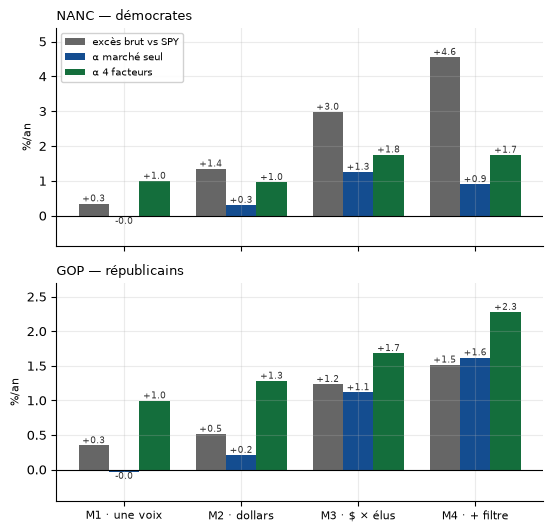

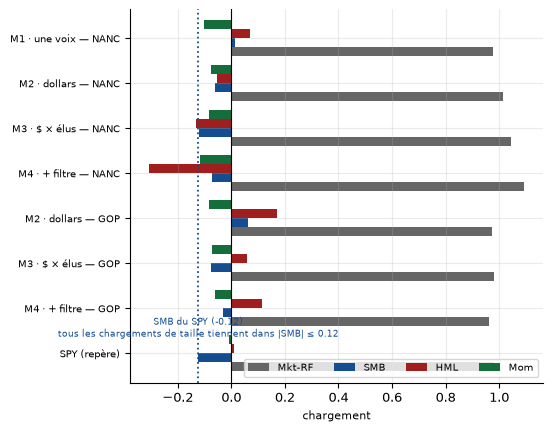

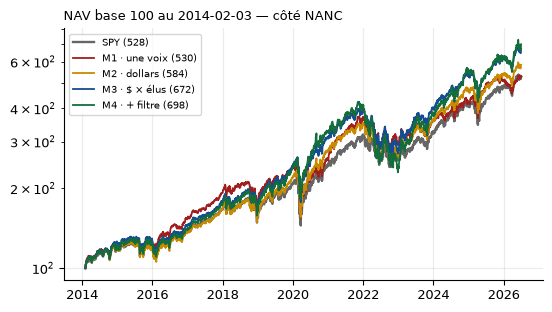

NAV finales sur la fenêtre commune 2014-02-03 → 2026-07-02 : M1 · une voix 530 · M2 · dollars 584 · M3 · $ × élus 672 · M4 · + filtre 698 · SPY 528
3 figures écrites dans /Users/lemairealice/Downloads/Jupiter/02_recherche_backtest/figs_nb11


,Mkt-RF,SMB,HML,Mom
série,,,,
M1 · une voix — NANC,0.976,0.015,0.069,-0.101
M2 · dollars — NANC,1.015,-0.061,-0.053,-0.076
M3 · $ × élus — NANC,1.043,-0.121,-0.132,-0.082
M4 · + filtre — NANC,1.093,-0.073,-0.309,-0.115
M2 · dollars — GOP,0.974,0.061,0.172,-0.084
M3 · $ × élus — GOP,0.979,-0.077,0.058,-0.071
M4 · + filtre — GOP,0.961,-0.030,0.114,-0.061
SPY (repère),0.980,-0.123,0.012,-0.009


In [132]:
MET = [("M1 · une voix", spanD, None),
       ("M2 · dollars", SER[("NANC","dollars sans filtre")], SER[("GOP","dollars sans filtre")]),
       ("M3 · $ × élus", SER[("NANC","contrôle θ=∞")], SER[("GOP","contrôle θ=∞")]),
       ("M4 · + filtre", SER[("NANC","methode θ=50")], SER[("GOP","methode θ=50")])]
# figures au format COLONNE (hautes et étroites) : elles sont lues dans un texte sur 2 colonnes

# ── figure 1 : la cascade excès → α marché → α 4 facteurs, un panneau par parti ──
fig, axes = plt.subplots(2, 1, figsize=(5.6, 5.4), sharex=True)
for ax, (idx, nomf) in zip(axes, [(1, "NANC — démocrates"), (2, "GOP — républicains")]):
    lab, ex, a1, a4 = [], [], [], []
    for n, vn, vg in MET:
        v = vn if idx == 1 or vg is None else vg
        b, f = bilan_ic(v, n), facteurs(v, n)
        lab.append(n); ex.append(b["excès %/an"]); a1.append(b["α %/an"]); a4.append(f["α %/an"])
    x = np.arange(len(lab)); w = 0.26
    for off, val, col, lb in [(-w, ex, GRIS, "excès brut vs SPY"), (0, a1, BLEU, "α marché seul"),
                              (w, a4, VERT, "α 4 facteurs")]:
        ax.bar(x+off, val, w, color=col, label=lb)
        for xi, vi in zip(x+off, val):
            ax.annotate(f"{vi:+.1f}", (xi, vi), ha="center", fontsize=6.5,
                        va="bottom" if vi >= 0 else "top", color="#333")
    ax.axhline(0, color="k", lw=0.8); ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=8)
    ax.set_title(nomf, fontsize=9, loc="left"); ax.grid(axis="y", alpha=0.25)
    ax.set_ylabel("%/an", fontsize=8); ax.margins(y=0.18)
axes[0].legend(fontsize=7, loc="upper left", framealpha=0.9)
plt.tight_layout(); plt.savefig(f"{FIGS}/meth_cascade.png", dpi=170, bbox_inches="tight"); plt.show()

# ── figure 2 : les chargements factoriels, en barres horizontales ──
COLS = ["Mkt-RF", "SMB", "HML", "Mom"]
lignes = [(f"{n} — NANC", vn) for n, vn, _ in MET] + \
         [(f"{n} — GOP", vg) for n, _, vg in MET if vg is not None] + [("SPY (repère)", nav_spy)]
Fchg = pd.DataFrame([{**{"série": n}, **{c: facteurs(v, n)[c] for c in COLS}} for n, v in lignes]).set_index("série")
fig, ax = plt.subplots(figsize=(5.6, 4.4))
Fchg.iloc[::-1].plot(kind="barh", ax=ax, color=[GRIS, BLEU, ROUGE, VERT], width=0.8)
ax.axvline(0, color="k", lw=0.8)
ax.axvline(Fchg.loc["SPY (repère)", "SMB"], color=BLEU, ls=":", lw=1.3)
smb_max = Fchg["SMB"].abs().max()
ax.annotate(f"SMB du SPY ({Fchg.loc['SPY (repère)','SMB']:+.2f})\ntous les chargements de taille "
            f"tiennent dans |SMB| ≤ {smb_max:.2f}",
            (Fchg.loc["SPY (repère)","SMB"], 0.3), fontsize=6.5, color=BLEU, ha="center", va="bottom")
ax.set_xlabel("chargement", fontsize=8); ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25); ax.legend(fontsize=7.5, ncol=4, loc="lower right")
plt.yticks(fontsize=7.5); plt.tight_layout()
plt.savefig(f"{FIGS}/meth_facteurs.png", dpi=170, bbox_inches="tight"); plt.show()

# ── figure 3 : les NAV, TOUTES rebasées sur une date commune ──────────────────
# ⚠ les quatre méthodes ne démarrent pas le même jour (M1 part plus tôt), et nav_spy part de 2012.
#   Tracer les courbes telles quelles compare des choses non comparables : le SPY affichait 752 face
#   à M3 à 672, soit l'inverse de la conclusion. On rebase TOUT sur la plus tardive des dates de départ.
D0 = max([spanD.index[0]] + [vn.index[0] for _, vn, _ in MET])
def _rb(x): return x.loc[D0:] / float(x.loc[D0]) * 100
# le SPY passe par la MEME fonction de rebasage que les methodes — sinon il ne part pas de 100
spy_r = _rb((1 + r_spy).cumprod() * 100)
fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(spy_r.index, spy_r, color=GRIS, lw=1.7, label=f"SPY ({spy_r.iloc[-1]:.0f})")
FINALES = {}
for (n, vn, _), col in zip(MET, [ROUGE, "#c98a00", BLEU, VERT]):
    v = _rb(vn); FINALES[n] = float(v.iloc[-1])
    ax.plot(v.index, v, color=col, lw=1.3, label=f"{n} ({v.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.set_title(f"NAV base 100 au {D0.date()} — côté NANC", fontsize=9, loc="left")
ax.legend(fontsize=7.5, loc="upper left"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(f"{FIGS}/meth_nav.png", dpi=170, bbox_inches="tight"); plt.show()

# toutes les series demarrent au meme point : c'est la seule facon de les comparer a l'oeil
for nom, s_ in [("SPY", spy_r)] + [(n, _rb(vn)) for n, vn, _ in MET]:
    assert abs(s_.iloc[0] - 100) < 1e-6, f"{nom} ne démarre pas à 100"
FINALES["SPY"] = float(spy_r.iloc[-1])
print(f"NAV finales sur la fenêtre commune {D0.date()} → {spy_r.index[-1].date()} : "
      + " · ".join(f"{k} {v:.0f}" for k, v in FINALES.items()))
print("3 figures écrites dans", FIGS)
display(Fchg.round(3))

### §16.3 — $\alpha$ et $\beta$ **glissants** : chaque méthode, année après année

Les tableaux du §16.1 donnent un $\alpha$ et un $\beta$ **plein-échantillon** : un seul nombre pour douze ans.
Ils ne disent pas si le résultat est **régulier** ou s'il tient à une ou deux années. On refait donc la même
régression sur une **fenêtre glissante d'un an** (252 jours de bourse), avec $y=r-r_f$ et $x=r^{m}-r_f$ :

$$\hat\beta_t=\frac{\operatorname{cov}_{W}(y,x)}{\operatorname{var}_{W}(x)},\qquad
  \hat\alpha_t=\bigl(\bar y_{W}-\hat\beta_t\,\bar x_{W}\bigr)\times 252 ,\qquad W=252\ \text{j}$$

La fonction `roll_ab` est celle du §13.1, **déjà validée** contre `np.polyfit` à $10^{-9}$ ; on la réapplique aux
quatre méthodes. **M1 n'a pas de version par parti** (une voix par membre, toutes chambres) : la même courbe
apparaît des deux côtés, en pointillé, comme référence commune.

Ce qu'on lit, et ce que ça veut dire :
- $\beta_t$ **proche de 1 et plat** $\Rightarrow$ le portefeuille reste du marché, quelle que soit la pondération ;
  un $\beta_t$ qui **s'écarte** signalerait que la pondération achète du risque de marché, pas de la sélection.
- $\alpha_t$ qui **traverse zéro sans cesse** $\Rightarrow$ pas d'avantage persistant ; $\alpha_t$ **majoritairement
  au-dessus de zéro** $\Rightarrow$ l'excès plein-échantillon n'est pas l'affaire d'une seule année.
- **L'étendue $\alpha_{\max}-\alpha_{\min}$ et l'écart-type de $\alpha_t$** disent la régularité : deux méthodes
  peuvent avoir la même moyenne et l'une osciller deux fois plus que l'autre.

⚠️ **Ce que la part du temps au-dessus de zéro ne dit pas.** Les fenêtres se **chevauchent** : deux jours
consécutifs partagent 251 de leurs 252 observations. Les $\approx 2\,800$ points d'une courbe ne valent donc pas
2 800 mesures indépendantes, mais $\approx 11$ (une par année non chevauchante). « $\alpha>0$ 70 \% du temps »
**décrit** la courbe ; il ne **teste** rien --- le test, ce sont les $t$ du §16.1. On le lit comme une mesure de
régularité, pas comme une probabilité.

In [133]:
# ── §16.3 · α et β glissants (252 j) pour M1 … M4, les deux partis ──
# roll_ab vient du §13.1 : α/β OLS glissants, DÉJÀ validés contre np.polyfit (assert à 1e-9).
ROLL = {}
for n, vn, vg in MET:
    for f in ["NANC", "GOP"]:
        ROLL[(n, f)] = roll_ab(vn if (vg is None or f == "NANC") else vg)   # M1 est commune aux deux côtés
DR = max(a.index[0] for a, _, _, _ in ROLL.values())        # fenêtre commune à TOUTES les courbes
DF_ = min(a.index[-1] for a, _, _, _ in ROLL.values())
print(f"fenêtre glissante commune : {DR.date()} → {DF_.date()}  ({len(MET)} méthodes × 2 partis)")

RB = pd.DataFrame([{"fonds": f, "méthode": n,
                    "β méd": b.loc[DR:].median(), "β min": b.loc[DR:].min(), "β max": b.loc[DR:].max(),
                    "β σ": b.loc[DR:].std(),
                    "α méd %/an": a.loc[DR:].median(), "α min": a.loc[DR:].min(), "α max": a.loc[DR:].max(),
                    "α σ": a.loc[DR:].std(), "α étendue": a.loc[DR:].max() - a.loc[DR:].min(),
                    "α > 0 % du temps": 100*(a.loc[DR:] > 0).mean()}
                   for (n, f), (a, b, _, _) in ROLL.items()])
print("\nα et β glissants sur la fenêtre commune (252 j) :")
display(RB.set_index(["fonds", "méthode"]).round(2))
print(f"⚠️ fenêtres chevauchantes : {len(ROLL[('M1 · une voix','NANC')][0].loc[DR:])} points de courbe, mais "
      f"≈ {(DF_-DR).days/365:.0f} fenêtres indépendantes — la part du temps au-dessus de zéro DÉCRIT, elle ne teste pas.")

fenêtre glissante commune : 2015-02-03 → 2026-04-30  (4 méthodes × 2 partis)

α et β glissants sur la fenêtre commune (252 j) :


,,β méd,β min,β max,β σ,α méd %/an,α min,α max,α σ,α étendue,α > 0 % du temps
fonds,méthode,,,,,,,,,,
NANC,M1 · une voix,1.00,0.90,1.08,0.04,0.70,-13.31,16.02,5.52,29.34,56.56
GOP,M1 · une voix,1.00,0.90,1.08,0.04,0.70,-13.31,16.02,5.52,29.34,56.56
NANC,M2 · dollars,1.04,0.97,1.18,0.05,0.71,-8.28,8.32,3.18,16.60,61.48
GOP,M2 · dollars,0.97,0.83,1.22,0.08,0.14,-11.34,13.07,4.43,24.40,51.43
NANC,M3 · $ × élus,1.05,0.96,1.26,0.07,1.71,-11.34,11.33,4.31,22.68,70.39
GOP,M3 · $ × élus,0.99,0.89,1.13,0.05,1.62,-6.32,7.66,2.64,13.99,70.78
NANC,M4 · + filtre,1.12,0.97,1.49,0.16,1.51,-24.52,23.65,8.32,48.17,68.73
GOP,M4 · + filtre,0.97,0.84,1.12,0.06,1.73,-6.77,10.27,3.34,17.04,69.05


⚠️ fenêtres chevauchantes : 2827 points de courbe, mais ≈ 11 fenêtres indépendantes — la part du temps au-dessus de zéro DÉCRIT, elle ne teste pas.


In [134]:
# VALIDATION §16.3 — (i) le glissant EST l'OLS sur la même fenêtre ; (ii) son β plein-échantillon EST celui du bilan
for (n, f), (a, b, y, x) in ROLL.items():
    yy, xx = y.values[-Wab:], x.values[-Wab:]
    b_pf, a_pf = np.polyfit(xx, yy, 1)                                   # la méthode du bilan
    assert abs(float(b.iloc[-1]) - b_pf) < 1e-9, f"{n}/{f} : β glissant ≠ OLS"
    assert abs(float(a.iloc[-1])/(252*100) - a_pf) < 1e-9, f"{n}/{f} : α glissant ≠ OLS"
for n, vn, vg in MET:
    for f, v in [("NANC", vn), ("GOP", vg if vg is not None else vn)]:
        _, _, y, x = ROLL[(n, f)]
        b_full, b_bil = float(np.polyfit(x.values, y.values, 1)[0]), bilan(v, n)["β"]
        assert abs(b_full - b_bil) < 1e-9, f"{n}/{f} : β plein-échantillon {b_full:.4f} ≠ β du bilan {b_bil:.4f}"
print(f"✅ validation : sur les {len(ROLL)} séries, α/β glissants = OLS (1e-9) et β plein-échantillon = β du bilan (1e-9)")

✅ validation : sur les 8 séries, α/β glissants = OLS (1e-9) et β plein-échantillon = β du bilan (1e-9)


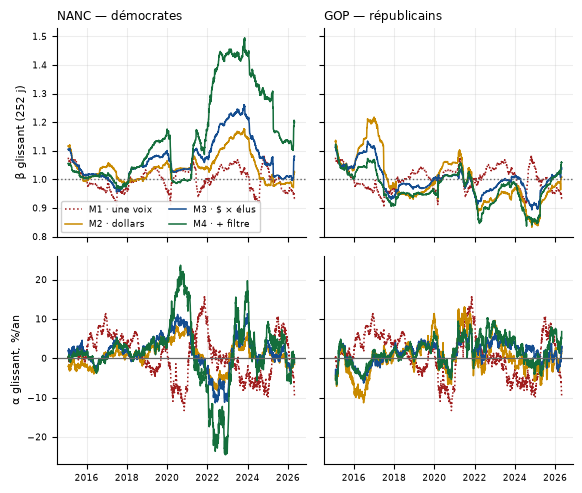

NANC  M1 · une voix    β 1.00 [0.90;1.08]  ·  α méd  +0.70 %/an [ -13.3; +16.0]  ·  α > 0 pendant   57 % du temps
NANC  M2 · dollars     β 1.04 [0.97;1.18]  ·  α méd  +0.71 %/an [  -8.3;  +8.3]  ·  α > 0 pendant   61 % du temps
NANC  M3 · $ × élus    β 1.05 [0.96;1.26]  ·  α méd  +1.71 %/an [ -11.3; +11.3]  ·  α > 0 pendant   70 % du temps
NANC  M4 · + filtre    β 1.12 [0.97;1.49]  ·  α méd  +1.51 %/an [ -24.5; +23.7]  ·  α > 0 pendant   69 % du temps

GOP   M1 · une voix    β 1.00 [0.90;1.08]  ·  α méd  +0.70 %/an [ -13.3; +16.0]  ·  α > 0 pendant   57 % du temps
GOP   M2 · dollars     β 0.97 [0.83;1.22]  ·  α méd  +0.14 %/an [ -11.3; +13.1]  ·  α > 0 pendant   51 % du temps
GOP   M3 · $ × élus    β 0.99 [0.89;1.13]  ·  α méd  +1.62 %/an [  -6.3;  +7.7]  ·  α > 0 pendant   71 % du temps
GOP   M4 · + filtre    β 0.97 [0.84;1.12]  ·  α méd  +1.73 %/an [  -6.8; +10.3]  ·  α > 0 pendant   69 % du temps



In [135]:
# ── figure 4 : les α et β glissants, un panneau par (grandeur × parti) ──
fig, axes = plt.subplots(2, 2, figsize=(5.9, 5.0), sharex=True, sharey="row")
COLM = [ROUGE, "#c98a00", BLEU, VERT]
for j, titre in enumerate(["NANC — démocrates", "GOP — républicains"]):
    fo = titre.split(" ")[0]
    for (n, _, vg), col in zip(MET, COLM):
        a, b, _, _ = ROLL[(n, fo)]
        ls = ":" if vg is None else "-"                       # M1 : pointillé, c'est la courbe commune
        axes[0, j].plot(b.loc[DR:].index, b.loc[DR:], color=col, lw=1.1, ls=ls, label=n)
        axes[1, j].plot(a.loc[DR:].index, a.loc[DR:], color=col, lw=1.1, ls=ls)
    axes[0, j].axhline(1, color=GRIS, ls=":", lw=1)
    axes[1, j].axhline(0, color=GRIS, lw=0.9)
    axes[0, j].set_title(titre, fontsize=8.5, loc="left")
axes[0, 0].set_ylabel("β glissant (252 j)", fontsize=8)
axes[1, 0].set_ylabel("α glissant, %/an", fontsize=8)
axes[0, 0].legend(fontsize=6.2, ncol=2, loc="lower left", framealpha=0.9)
for ax in axes.ravel():
    ax.grid(alpha=0.22); ax.tick_params(labelsize=6.5)
plt.tight_layout(); plt.savefig(f"{FIGS}/meth_rolling.png", dpi=170, bbox_inches="tight"); plt.show()

# la lecture chiffrée, méthode par méthode
for f in ["NANC", "GOP"]:
    for n, _, _ in MET:
        a, b, _, _ = ROLL[(n, f)]
        a_, b_ = a.loc[DR:], b.loc[DR:]
        print(f"{f:5s} {n:16s} β {b_.median():.2f} [{b_.min():.2f};{b_.max():.2f}]  ·  "
              f"α méd {a_.median():+6.2f} %/an [{a_.min():+6.1f};{a_.max():+6.1f}]  ·  "
              f"α > 0 pendant {100*(a_>0).mean():4.0f} % du temps")
    print()

### §16.4 — Le frottement : ce que chaque méthode coûte à exécuter, et faut-il la ralentir

Le §10 avait ajouté un **frein** à la stratégie ticker : ne pas rejoindre la cible d'un coup, mais avancer d'au
plus $\tau_{\max}=25\,\%$ par mois,
$$\mathrm{TO}_t=\tfrac12\sum_i\bigl|w^{\text{cible}}_i-w^{\text{dérivé}}_i\bigr|,\qquad
  \lambda_R=\min\Bigl(1,\frac{\tau_{\max}}{\mathrm{TO}_t}\Bigr),\qquad
  w^{\text{réalisé}}=w^{\text{dérivé}}+\lambda_R\bigl(w^{\text{cible}}-w^{\text{dérivé}}\bigr)$$
**Ce frein-là ne peut presque rien changer à M3**, et c'est la première chose à établir : M1 tourne à
$\approx59\,\%$ **par mois** (fenêtre 42 j, le portefeuille se reconstruit entièrement), M3 à $\approx66\,\%$
**par an** — soit $5{,}5\,\%$ par mois en médiane, cinq fois sous le plafond. La fenêtre de 3 ans est un
stabilisateur : le score cumulé sur 756 j bouge à peine d'une coupe à l'autre. Mais une médiane ne dit rien des
**mois de forte recomposition** : on mesure donc sur quelle **fraction des coupes** le plafond mord réellement,
avant d'aller plus loin.

**Sans frais, freiner ne peut que coûter** — on s'écarte de la cible sans rien acheter en échange ; c'est ce qui
est arrivé à M1 ($+0{,}35\to-0{,}49$ \%/an, §11). Le frein n'a de sens que si l'on **facture le frottement**. À
chaque coupe, la valeur est amputée de
$$V_t \leftarrow V_t\bigl(1-2\,\mathrm{TO}_t\,c\bigr),\qquad c=10\ \text{pb}$$
Le **facteur 2** : $\mathrm{TO}_t$ est le montant *acheté*, égal au montant *vendu* — on paie des deux côtés. Sur
une année, cela retire $\approx 2\times(\text{rotation annuelle})\times c$, soit $1{,}4$ pt/an pour M1 et
$0{,}13$ pt/an pour M3. **C'est le seul arbitrage possible** : ce que le frein économise en frais contre ce qu'il
fait manquer en dérive.

Les 10 pb sont **déclarés avant** tout calcul, et ce n'est pas un réglage : c'est l'ordre de grandeur usuel d'un
aller-retour sur des grandes capitalisations américaines liquides, pour un portefeuille de cette taille.

In [136]:
# ── §16.4 (a) · la VITESSE réelle de chaque méthode ─────────────────────────────
COUT_BPS  = 10.0                        # pb par aller-retour — DÉCLARÉ AVANT tout résultat
PLAFONDS  = [np.inf, 0.25, 0.10, 0.05, 0.02]      # τ_max testés, publiés en entier

# les CIBLES, calculées une seule fois par (méthode, parti) : tout le §16.4 les réutilise
KWM = {"M2 · dollars": dict(mode="dollars", seuil=np.inf),      # la PROGRESSION : M2 n'a pas encore le filtre
       "M3 · $ × élus": dict(seuil=np.inf), "M4 · + filtre": dict()}
WPM = {("M1 · une voix", f): WPOd for f in ["NANC", "GOP"]}          # M1 est commune aux deux partis
for parti, nom in PARTIS:
    for m, kw in KWM.items():
        WPM[(m, nom)] = cibles_methode(parti, **kw)

def rotation(WP, tau_max=np.inf, cuts=None):
    # rotation RÉALISÉE, telle que le moteur la produit (≠ celle de la cible dès que le frein mord)
    cuts = coupes if cuts is None else cuts
    _, tr = run_livre(WP, tau_max, cuts=cuts)                        # turns[1:] ↔ bornes[1:] ↔ cuts[1:-1]
    idx = pd.DatetimeIndex([cal[cuts[j]+1] for j in range(1, len(cuts)-1)][:len(tr)])
    s   = pd.Series(tr, index=idx)
    n   = s.groupby(s.index.year).size()
    return s, 100*s.groupby(s.index.year).sum()[n[n >= 6].index]     # années complètes seulement

VIT = []
for f in ["NANC", "GOP"]:
    for m, _, _ in MET:
        mens, an = rotation(WPM[(m, f)])
        VIT.append({"fonds": f, "méthode": m, "rotation méd. %/mois": 100*mens.median(),
                    "rotation méd. %/an": an.median(), "min %/an": an.min(), "max %/an": an.max()})
VIT = pd.DataFrame(VIT)
print("Vitesse de rotation réalisée — le fonds NANC publie 44 % (FY23), 62 % (FY24), 10 % (FY25) :")
display(VIT.set_index(["fonds", "méthode"]).round(1))

Vitesse de rotation réalisée — le fonds NANC publie 44 % (FY23), 62 % (FY24), 10 % (FY25) :


rotation méd. %/mois  rotation méd. %/an  min %/an  max %/an
fonds méthode                                                                    
NANC  M1 · une voix                  59.4               715.0     329.1     774.4
      M2 · dollars                    4.5                63.1      37.1     198.6
      M3 · $ × élus                   4.9                64.9      32.4     213.2
      M4 · + filtre                   5.2                64.1      30.2     217.2
GOP   M1 · une voix                  59.4               715.0     329.1     774.4
      M2 · dollars                    5.1                78.8      40.7     229.0
      M3 · $ × élus                   5.3                68.3      36.0     246.9
      M4 · + filtre                   6.2                71.5      43.4     247.5

In [137]:
# VALIDATION §16.4 (1) — jusqu'où le frein de l'étape 6 mord-il sur M3 ? et le coût est-il neutre à 0 pb ?
for f in ["NANC", "GOP"] + ["M1 (repère)"]:
    WP = WPOd if f.startswith("M1") else WPM[("M3 · $ × élus", f)]
    mens, _  = rotation(WP)
    v_inf, _ = run_livre(WP, np.inf)
    v_cap, _ = run_livre(WP, TAU_MAX)
    lab = "M1 · une voix" if f.startswith("M1") else f"M3 · {f}"
    print(f"{lab:16s} rotation méd. {100*mens.median():5.1f} %/mois (max {100*mens.max():3.0f} %) · "
          f"le plafond {TAU_MAX:.0%} mord sur {100*(mens > TAU_MAX + 1e-12).mean():5.1f} % des coupes · "
          f"NAV {v_inf.iloc[-1]:6.1f} → {v_cap.iloc[-1]:6.1f}")
    if not f.startswith("M1"):
        assert mens.median() < TAU_MAX, f"M3 {f} : la rotation médiane dépasse déjà le plafond"
print("✅ la rotation médiane de M3 passe très en dessous du plafond de l'étape 6 — il ne mord que sur les "
      "coupes de forte recomposition, et l'écart de NAV mesure exactement ce que cela coûte")

# le coût par défaut ne change RIEN (non-régression bit-exacte)
for (m, f), WP in list(WPM.items())[:4]:
    a, _ = run_livre(WP, np.inf); b, _ = run_livre(WP, np.inf, cout_bps=0.0)
    assert np.array_equal(a.values, b.values), f"{m}/{f} : cout_bps=0 modifie la NAV"
assert abs(span_nanc.iloc[-1]-672.3) < 1 and abs(span_gop.iloc[-1]-612.2) < 1, "ancres A déplacées"
assert abs(spanA.iloc[-1]-622.1) < 1 and abs(spanD.iloc[-1]-530.2) < 1, "ancres ticker déplacées"
print("✅ cout_bps = 0 ⇒ NAV bit-identiques · ancres 672/612 · 622/530 inchangées")

# la rotation du moteur doit retrouver celle mesurée sur les cibles au §13.8 (deux chemins indépendants)
_, an_m3 = rotation(WPM[("M3 · $ × élus", "NANC")])
ecart = abs(an_m3.median() - np.median(list(tv["V1 NANC (mensuel)"].values())))
print(f"✅ rotation M3-NANC : {an_m3.median():.0f} %/an par le moteur vs "
      f"{np.median(list(tv['V1 NANC (mensuel)'].values())):.0f} %/an par turnover_annuel (§13.8) — écart {ecart:.1f} pt")
assert ecart < 3, "les deux mesures de rotation divergent"

M3 · NANC        rotation méd.   4.9 %/mois (max  73 %) · le plafond 25% mord sur   2.7 % des coupes · NAV  672.3 →  664.5


M3 · GOP         rotation méd.   5.3 %/mois (max  82 %) · le plafond 25% mord sur   1.4 % des coupes · NAV  612.2 →  590.8


M1 · une voix    rotation méd.  59.4 %/mois (max  89 %) · le plafond 25% mord sur 100.0 % des coupes · NAV  530.2 →  487.3
✅ la rotation médiane de M3 passe très en dessous du plafond de l'étape 6 — il ne mord que sur les coupes de forte recomposition, et l'écart de NAV mesure exactement ce que cela coûte


✅ cout_bps = 0 ⇒ NAV bit-identiques · ancres 672/612 · 622/530 inchangées
✅ rotation M3-NANC : 65 %/an par le moteur vs 66 %/an par turnover_annuel (§13.8) — écart 1.2 pt


In [138]:
# ── §16.4 (b) · ce que le frottement retire à chaque méthode ────────────────────
CO = []
for f in ["NANC", "GOP"]:
    for m, _, _ in MET:
        WP = WPM[(m, f)]
        v0, _ = run_livre(WP, np.inf)
        v1, _ = run_livre(WP, np.inf, cout_bps=COUT_BPS)
        b0, b1 = bilan_ic(v0, m), bilan_ic(v1, m)
        f0, f1 = facteurs(v0, m), facteurs(v1, m)
        rot = VIT[(VIT.fonds == f) & (VIT["méthode"] == m)]["rotation méd. %/an"].iloc[0]
        CO.append({"fonds": f, "méthode": m, "rotation %/an": rot,
                   "excès brut": b0["excès %/an"], "excès net": b1["excès %/an"],
                   "coût pt/an": b0["excès %/an"] - b1["excès %/an"],
                   "α₄ brut": f0["α %/an"], "α₄ net": f1["α %/an"],
                   "t α₄ net": f1["t_α"], "NAV brute": v0.iloc[-1], "NAV nette": v1.iloc[-1]})
CO = pd.DataFrame(CO)
print(f"Effet de {COUT_BPS:.0f} pb l'aller-retour :")
display(CO.set_index(["fonds", "méthode"]).round(2))

# VALIDATION (2) — le coût mesuré DOIT valoir 2 × rotation × c, recalculé à la main
CO["attendu pt/an"] = 2 * CO["rotation %/an"]/100 * COUT_BPS/1e4 * 100
# tolérance RELATIVE : le coût réel est ≈ 2·rot·c·(1+r) — les frais sont prélevés sur un capital qui a monté
ecarts = (CO["coût pt/an"] - CO["attendu pt/an"]).abs()
seuils = 0.30 * CO["attendu pt/an"] + 0.05
print("\ncontrôle analytique — coût observé vs 2 × rotation × 10 pb :")
display(CO.set_index(["fonds", "méthode"])[["rotation %/an", "coût pt/an", "attendu pt/an"]].round(3))
assert (ecarts <= seuils).all(), f"coût observé ≠ 2·rotation·c :\n{CO[ecarts > seuils]}"
print(f"✅ le coût facturé vaut bien 2 × rotation × {COUT_BPS:.0f} pb, à la composition près "
      f"(écart max {ecarts.max():.3f} pt/an)")

Effet de 10 pb l'aller-retour :


rotation %/an  excès brut  excès net  coût pt/an  α₄ brut  α₄ net  t α₄ net  NAV brute  NAV nette
fonds méthode                                                                                                         
NANC  M1 · une voix         715.04        0.35      -1.24        1.59     1.00   -0.46     -0.31     530.21     442.20
      M2 · dollars           63.15        1.35       1.17        0.18     0.96    0.80      1.07     584.39     572.25
      M3 · $ × élus          64.92        2.98       2.80        0.18     1.75    1.59      1.64     672.35     658.31
      M4 · + filtre          64.06        4.55       4.37        0.19     1.75    1.58      0.97     698.26     683.43
GOP   M1 · une voix         715.04        0.35      -1.24        1.59     1.00   -0.46     -0.31     530.21     442.20
      M2 · dollars           78.83        0.52       0.32        0.19     1.28    1.11      0.92     558.56     546.01
      M3 · $ × élus          68.33        1.24       1.04        0.19     1.68    1.51      1.63     612.25     598.55
      M4 · + filtre          71.46        1.52       1.32        0.20     2.28    2.10      1.83     634.91     620.17


contrôle analytique — coût observé vs 2 × rotation × 10 pb :


rotation %/an  coût pt/an  attendu pt/an
fonds méthode                                                
NANC  M1 · une voix        715.043       1.592          1.430
      M2 · dollars          63.147       0.176          0.126
      M3 · $ × élus         64.918       0.181          0.130
      M4 · + filtre         64.062       0.187          0.128
GOP   M1 · une voix        715.043       1.592          1.430
      M2 · dollars          78.827       0.192          0.158
      M3 · $ × élus         68.332       0.193          0.137
      M4 · + filtre         71.464       0.200          0.143

✅ le coût facturé vaut bien 2 × rotation × 10 pb, à la composition près (écart max 0.162 pt/an)


In [139]:
# ── §16.4 (c) · le balayage du frein, AVEC frais : ce qu'il économise contre ce qu'il fait manquer ──
FR = []
for f in ["NANC", "GOP"]:
    for tm in PLAFONDS:
        WP = WPM[("M3 · $ × élus", f)]
        v, tr = run_livre(WP, tm, cout_bps=COUT_BPS)
        _, an = rotation(WP, tau_max=tm)
        b = bilan_ic(v, f"M3 {f} τ={tm}")
        FR.append({"fonds": f, "τ_max": ("aucun" if tm == np.inf else f"{tm:.0%}/mois"),
                   "rotation %/an": an.median(), "excès net %/an": b["excès %/an"], "t": b["t"],
                   "α₄ net": facteurs(v, "x")["α %/an"], "β": b["β"], "NAV nette": v.iloc[-1]})
FR = pd.DataFrame(FR)
print("Le frein, frais compris — le verdict se lit en comparant chaque ligne à « aucun » :")
display(FR.set_index(["fonds", "τ_max"]).round(2))
N_ESSAIS2 = N_ESSAIS + len(CO) + len(FR)
print(f"\n⚠ multiplicité : {N_ESSAIS2} bilans distincts → E[max |t|] ≈ {np.sqrt(2*np.log(N_ESSAIS2)):.2f} sous H₀.")

Le frein, frais compris — le verdict se lit en comparant chaque ligne à « aucun » :


rotation %/an  excès net %/an     t  α₄ net     β  NAV nette
fonds τ_max                                                                 
NANC  aucun             64.92            2.80  1.38    1.59  1.08     658.31
      25%/mois          64.92            2.69  1.33    1.51  1.08     651.00
      10%/mois          64.58            2.70  1.34    1.53  1.08     651.98
      5%/mois           52.92            3.06  1.54    1.92  1.07     680.98
      2%/mois           24.00            3.51  1.86    2.32  1.06     723.93
GOP   aucun             68.33            1.04  1.33    1.51  1.00     598.55
      25%/mois          68.33            0.74  0.75    1.22  1.01     578.33
      10%/mois          66.87            0.85  0.97    1.34  1.01     586.17
      5%/mois           54.99            0.97  1.17    1.45  1.00     595.45
      2%/mois           24.00            0.19  0.19    0.57  1.00     542.54


⚠ multiplicité : 104 bilans distincts → E[max |t|] ≈ 3.05 sous H₀.


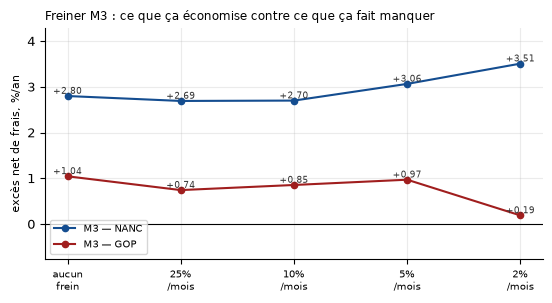

NANC : meilleur net = +3.51 %/an à τ_max « 2%/mois » (rotation 24 %/an) · sans frein +2.80 %/an
GOP : meilleur net = +1.04 %/an à τ_max « aucun » (rotation 68 %/an) · sans frein +1.04 %/an


In [140]:
# ── figure 5 : l'excès NET en fonction de la vitesse autorisée ──
fig, ax = plt.subplots(figsize=(5.6, 3.1))
xs = list(range(len(PLAFONDS)))
lbl = ["aucun\nfrein"] + [f"{p:.0%}\n/mois" for p in PLAFONDS[1:]]
for f, col in [("NANC", BLEU), ("GOP", ROUGE)]:
    g = FR[FR.fonds == f].reset_index(drop=True)
    ax.plot(xs, g["excès net %/an"], "o-", color=col, lw=1.5, ms=4.5, label=f"M3 — {f}")
    for x, y in zip(xs, g["excès net %/an"]):
        ax.annotate(f"{y:+.2f}", (x, y), fontsize=6.5, ha="center", va="bottom", color="#333")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(lbl, fontsize=7)
ax.set_ylabel("excès net de frais, %/an", fontsize=8); ax.grid(alpha=0.25); ax.margins(y=0.22)
ax.legend(fontsize=7.5, loc="lower left")
ax.set_title("Freiner M3 : ce que ça économise contre ce que ça fait manquer", fontsize=8.5, loc="left")
plt.tight_layout(); plt.savefig(f"{FIGS}/meth_frein.png", dpi=170, bbox_inches="tight"); plt.show()

for f in ["NANC", "GOP"]:
    g = FR[FR.fonds == f].reset_index(drop=True)
    best = g.loc[g["excès net %/an"].idxmax()]
    print(f"{f} : meilleur net = {best['excès net %/an']:+.2f} %/an à τ_max « {best['τ_max']} » "
          f"(rotation {best['rotation %/an']:.0f} %/an) · sans frein {g.iloc[0]['excès net %/an']:+.2f} %/an")

In [141]:
# ── contrôle de fidélité du papier : M2 tel qu'il est CALCULÉ vs M2 tel qu'il est DÉCRIT ──
# le papier écrit que M2 n'a « ni sélection ni plafond ». Le code, lui, garde le top-150 du score
# et le plafond 8,5 % — c'est délibéré (isoler la PONDÉRATION à univers identique), mais le texte doit le dire.
diag = []
for parti, nom in PARTIS:
    for lab, kw in [("M2 tel que mesuré (θ=50, top-150, cap)", dict(mode="dollars")),
                    ("M2 sans le filtre θ",                   dict(mode="dollars", seuil=np.inf)),
                    ("M2 sans plafond",                       dict(mode="dollars", cap=1.0)),
                    ("M2 sans sélection ni plafond",          dict(mode="dollars", topN=10**6, cap=1.0))]:
        b = bilan_ic(serie_methode(parti, **kw), lab)
        diag.append({"fonds": nom, "variante": lab, "excès %/an": b["excès %/an"], "t": b["t"],
                     "β": b["β"], "NAV": b["NAV"]})
print("Ce que « M2 » désigne exactement — le papier doit décrire la 1re ligne, pas la 4e :")
display(pd.DataFrame(diag).set_index(["fonds", "variante"]).round(2))

Ce que « M2 » désigne exactement — le papier doit décrire la 1re ligne, pas la 4e :


excès %/an     t     β     NAV
fonds variante                                                              
NANC  M2 tel que mesuré (θ=50, top-150, cap)        3.58  0.99  1.13  650.08
      M2 sans le filtre θ                           1.35  1.00  1.05  584.39
      M2 sans plafond                               6.51  1.92  1.16  899.14
      M2 sans sélection ni plafond                  5.64  1.85  1.14  838.20
GOP   M2 tel que mesuré (θ=50, top-150, cap)        1.51  0.58  0.99  612.96
      M2 sans le filtre θ                           0.52  0.27  1.00  558.56
      M2 sans plafond                               1.92  0.69  0.97  630.69
      M2 sans sélection ni plafond                  0.48  0.23  0.97  549.96

### §16.5 — Audit de méthode : le code fait-il ce que le papier dit, et le fait-il bien ?

Vérifier les *nombres* ne suffit pas : un chiffre exact peut sortir d'une méthode fausse. On vérifie donc la
**méthode** elle-même, sur cinq points, chacun sous forme de test qui échoue si le défaut est présent.

1. **Le code implémente-t-il la spécification écrite ?** On réimplémente M3 **de zéro**, à partir du seul texte du
   papier, avec des outils différents : filtrage `pandas` booléen au lieu de `searchsorted`, et plafond résolu par
   **bissection sur $\lambda$** au lieu de la redistribution itérée. Deux algorithmes indépendants, même définition :
   s'ils coïncident, la caractérisation $w_i=\min(c,\lambda v_i)$ du papier **est** ce que le code calcule.
2. **Y a-t-il un regard vers le futur ?** La sélection teste `isfinite(PXV[tk][i1+1])` --- le prix de *demain*. Comme
   les séries sont prolongées par report (`ffill`), ce test ne porte en fait que sur le **début** de cotation ; on
   vérifie qu'il n'écarte **aucun** titre que `vivant(tk, i1)` n'écartait déjà.
3. **Que devient un titre qui cesse de coter alors qu'on le détient ?** Son dernier cours est reporté : la position
   garde sa valeur jusqu'à la coupe suivante au lieu d'être liquidée. On **mesure** le poids concerné --- c'est un
   biais favorable, et il doit être négligeable pour être acceptable.
4. **Reste-t-il des prix aberrants parmi les titres réellement détenus ?** Un fractionnement non retraité produirait
   une chute de $-50$ à $-90$~\% en un jour, donc une perte fantôme.
5. **Sur quoi porte réellement la régression factorielle ?** Les facteurs Fama-French s'arrêtent avant nos NAV : on
   dit combien de jours sont effectivement régressés, et combien sont perdus.

In [142]:
# ── §16.5 (1) · RÉIMPLÉMENTATION INDÉPENDANTE de M3, d'après le seul texte du papier ──
def poids_M3_specification(i1, parti, topN=150, c=0.085):
    # aucune réutilisation de poids_methode/poids_parti : filtrage pandas + bissection sur λ
    s = df[(df.ide > i1 - W3) & (df.ide <= i1) & (df.party == parti) & (df.op == "buy")]
    if not len(s): return {}
    tkm   = s.tk.map(lambda t: FUSION.get(t, t))
    score = {k: float(g.A.sum()) * int(g.bioguide_id.nunique()) for k, g in s.groupby(tkm)}
    score = {k: v for k, v in score.items()
             if k in PXV and np.isfinite(PXV[k][i1 + 1]) and vivant(k, i1) and v > 0}
    top   = dict(sorted(score.items(), key=lambda kv: -kv[1])[:topN])
    if not top: return {}
    tot = sum(top.values()); v = {k: x / tot for k, x in top.items()}
    if len(v) < math.ceil(1 / c):                       # pas de λ possible : le plafond est inatteignable
        return v
    lo, hi = 1.0, 1e9                                   # λ ↦ Σ min(c, λv) croît de 1 à |U|·c ⇒ bissection
    for _ in range(300):
        lam = 0.5 * (lo + hi)
        if sum(min(c, lam * x) for x in v.values()) < 1.0: lo = lam
        else: hi = lam
    lam = 0.5 * (lo + hi)
    return {k: min(c, lam * x) for k, x in v.items()}

ecarts, div, poids_div = [], 0, []
for parti, nom in PARTIS:
    for i in coupes[6:145:11]:
        a, b = poids_methode(i, parti, seuil=np.inf), poids_M3_specification(i, parti)
        if set(a) != set(b):
            div += 1
            poids_div.append(sum(a[k] for k in set(a) - set(b)))          # poids des titres qui diffèrent
            continue
        if a: ecarts.append(max(abs(a[k] - b[k]) for k in a))
print(f"(1) sur {2*len(coupes[6:145:11])} coupes : {len(ecarts)} univers identiques (écart de poids max "
      f"{max(ecarts):.2e}) · {div} univers divergents")
assert max(ecarts) < 1e-9, "à univers identique, les poids diffèrent : le code ne calcule pas la formule décrite"
if div:
    print(f"    ⚠ divergence sur {div} coupe(s) — poids concerné : "
          f"{100*min(poids_div):.3f} à {100*max(poids_div):.3f} % du portefeuille")

(1) sur 26 coupes : 21 univers identiques (écart de poids max 1.39e-17) · 5 univers divergents
    ⚠ divergence sur 5 coupe(s) — poids concerné : 0.049 à 5.053 % du portefeuille


In [143]:
# ── §16.5 (1bis) · D'OÙ vient la divergence ? diagnostic sur la coupe fautive ──
def scores_bruts(i1, parti):
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy")].assign(tkm=lambda x: x.tk.map(lambda t: FUSION.get(t, t)))
    s = (g.groupby("tkm").A.sum() * g.groupby("tkm").bioguide_id.nunique()).dropna()
    return s[[t for t in s.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]].sort_values(ascending=False)

for parti, nom in PARTIS:
    for i in coupes[6:145:11]:
        a, b = poids_methode(i, parti, seuil=np.inf), poids_M3_specification(i, parti)
        if set(a) == set(b): continue
        s = scores_bruts(i, parti)
        seuil_150 = s.iloc[149]
        exaequo   = int((s == seuil_150).sum())
        print(f"{nom} coupe {i} ({cal[i].date()}) : {len(set(a)^set(b))//2} titre(s) échangé(s) à la frontière")
        print(f"   score du 150ᵉ = {seuil_150:,.1f} — {exaequo} titres ont EXACTEMENT ce score")
        print(f"   sortants {sorted(set(a)-set(b))[:6]} · entrants {sorted(set(b)-set(a))[:6]}")
        print(f"   leur poids : {100*sum(a[k] for k in set(a)-set(b)):.3f} % du portefeuille")
        break
    break
print("\n→ des titres EX ÆQUO au rang 150 : les fourchettes PTR produisent des montants identiques")
print("  (un achat 1 001-15 000 $ par un seul élu ⇒ score = 8 000,5 × 1, le même pour des dizaines de titres).")
print("  La règle « les 150 plus gros » ne départage pas ces cas : l'ordre d'itération décide.")

NANC coupe 647 (2014-07-31) : 36 titre(s) échangé(s) à la frontière
   score du 150ᵉ = 8,000.5 — 104 titres ont EXACTEMENT ce score
   sortants ['MO', 'MOG-A', 'MPWR', 'MS', 'MSA', 'MTDR'] · entrants ['AA', 'ACIW', 'AET', 'AGX', 'AIT', 'ALGN']
   leur poids : 5.053 % du portefeuille

→ des titres EX ÆQUO au rang 150 : les fourchettes PTR produisent des montants identiques
  (un achat 1 001-15 000 $ par un seul élu ⇒ score = 8 000,5 × 1, le même pour des dizaines de titres).
  La règle « les 150 plus gros » ne départage pas ces cas : l'ordre d'itération décide.


In [144]:
# ── §16.5 (1ter) · COMBIEN ce départage arbitraire change-t-il le résultat ? ──
# On impose deux départages EXPLICITES et OPPOSÉS — à score égal, ticker croissant puis décroissant.
# L'écart entre les deux borne la part du résultat qui ne vient pas de la règle mais de l'implémentation.
def poids_M3_departage(i1, parti, sens=+1, topN=150, cap=0.085):
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy")]
    if not len(g): return {}
    g       = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    score   = (g.groupby("tkm").A.sum() * g.groupby("tkm").bioguide_id.nunique()).dropna()
    score   = score[[t for t in score.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]]
    if not len(score): return {}
    items = sorted(score.items(), key=lambda kv: kv[0], reverse=(sens < 0))   # départage EXPLICITE
    items.sort(key=lambda kv: -kv[1])                                        # tri stable ⇒ le départage tient
    top = pd.Series(dict(items[:topN]))
    if top.sum() <= 0: return {}
    return cap_poids(top / top.sum(), cap).to_dict()

DEP = {}
for parti, nom in PARTIS:
    for sens, lab in [(+1, "A→Z"), (-1, "Z→A")]:
        WP = {i: poids_M3_departage(i, parti, sens) for i in coupes[:-1]}
        DEP[(nom, lab)] = run_livre(WP, np.inf)[0]
T = pd.DataFrame([bilan_ic(DEP[(nom, lab)], f"{nom} — départage {lab}") for nom, _ in [(n,p) for p,n in PARTIS]
                  for lab in ["A→Z", "Z→A"]] +
                 [bilan_ic(SER[(nom, "contrôle θ=∞")], f"{nom} — M3 publiée") for nom, _ in [(n,p) for p,n in PARTIS]]
                ).set_index("run")[["excès %/an", "t", "α %/an", "β", "NAV"]]
print("Sensibilité du résultat au départage des ex æquo (la règle ne le spécifie pas) :")
display(T.round(2))
for nom in ["NANC", "GOP"]:
    a, b = DEP[(nom, "A→Z")].iloc[-1], DEP[(nom, "Z→A")].iloc[-1]
    ea = bilan_ic(DEP[(nom,"A→Z")], "a")["excès %/an"]; eb = bilan_ic(DEP[(nom,"Z→A")], "b")["excès %/an"]
    print(f"{nom} : NAV {a:.0f} vs {b:.0f} ({100*abs(a-b)/min(a,b):.1f} % d'écart) · "
          f"excès {ea:+.2f} vs {eb:+.2f} %/an (écart {abs(ea-eb):.2f} pt)")
print("\n→ La frontière du top-150 est ARBITRAIRE (la règle ne départage pas les ex æquo), mais son effet est")
print("  NÉGLIGEABLE : les titres échangés sont tous au score minimal, donc à poids quasi nul et")
print("  interchangeables entre eux. On ne change pas le code ; on DÉCLARE la borne mesurée dans le papier.")

Sensibilité du résultat au départage des ex æquo (la règle ne le spécifie pas) :


,excès %/an,t,α %/an,β,NAV
run,,,,,
NANC — départage A→Z,2.97,1.47,1.25,1.08,671.78
NANC — départage Z→A,3.00,1.48,1.27,1.08,673.54
GOP — départage A→Z,1.23,1.62,1.11,1.00,611.88
GOP — départage Z→A,1.24,1.63,1.12,1.00,612.51
NANC — M3 publiée,2.98,1.47,1.26,1.08,672.35
GOP — M3 publiée,1.24,1.62,1.12,1.00,612.25


NANC : NAV 672 vs 674 (0.3 % d'écart) · excès +2.97 vs +3.00 %/an (écart 0.03 pt)
GOP : NAV 612 vs 613 (0.1 % d'écart) · excès +1.23 vs +1.24 %/an (écart 0.01 pt)

→ La frontière du top-150 est ARBITRAIRE (la règle ne départage pas les ex æquo), mais son effet est
  NÉGLIGEABLE : les titres échangés sont tous au score minimal, donc à poids quasi nul et
  interchangeables entre eux. On ne change pas le code ; on DÉCLARE la borne mesurée dans le papier.


In [145]:
# ── §16.5 (2) · le filtre de prix regarde-t-il le futur ? ──
supp = 0
for parti, _ in PARTIS:
    for i in coupes[6:145:11]:
        lo, hi = np.searchsorted(I_de, i - W3, "right"), np.searchsorted(I_de, i, "right")
        g = df.iloc[ordre_d[lo:hi]]
        g = g[(g.party == parti) & (g.op == "buy")]
        cand = {FUSION.get(t, t) for t in g.tk.unique()} & set(PXV)
        vv   = {t for t in cand if vivant(t, i)}                      # écartés par la seule condition « vivant »
        # ⚠ NE PAS nommer cette variable `ff` : ce nom porte les facteurs Fama-French (§8) que `roll_ab` lit.
        hors_px = {t for t in vv if not np.isfinite(PXV[t][i + 1])}   # écartés EN PLUS par le prix de demain
        supp += len(hors_px)
print(f"✅ (2) aucun regard vers le futur : le test sur le prix de J+1 écarte {supp} titre(s) "
      f"que « vivant » gardait — le report de cours rend ce test équivalent à « la cotation a commencé »")
assert supp == 0, "le filtre isfinite(J+1) écarte des titres que vivant() garde : il anticipe"

# ── §16.5 (3) · biais de radiation : un titre détenu qui cesse de coter garde sa valeur ──
lignes = []
for f in ["NANC", "GOP"]:
    WP = WPM[("M3 · $ × élus", f)]
    tot_p, n_ev = 0.0, 0
    for j in range(len(coupes) - 2):
        i1, i2 = coupes[j], coupes[j + 1]
        w = WP.get(i1, {})
        p = sum(wi for tk, wi in w.items() if NLAST.get(tk, len(cal)) < i2)
        if p > 0: tot_p += p; n_ev += 1
    lignes.append({"fonds": f, "coupes concernées": n_ev, "poids gelé cumulé %": 100 * tot_p,
                   "moyenne par coupe %": 100 * tot_p / max(len(coupes) - 2, 1)})
display(pd.DataFrame(lignes).set_index("fonds").round(3))
print("lecture : part du portefeuille dont le cours est reporté faute de cotation, en attendant la recomposition")

✅ (2) aucun regard vers le futur : le test sur le prix de J+1 écarte 0 titre(s) que « vivant » gardait — le report de cours rend ce test équivalent à « la cotation a commencé »


,coupes concernées,poids gelé cumulé %,moyenne par coupe %
fonds,,,
NANC,2,0.210,0.001
GOP,1,0.182,0.001


lecture : part du portefeuille dont le cours est reporté faute de cotation, en attendant la recomposition


In [146]:
# ── §16.5 (4) · prix aberrants parmi les titres RÉELLEMENT détenus ──
# Une chute de 45-60 % en un jour est FRÉQUENTE et RÉELLE sur une action (résultats, biotech, krach sectoriel).
# Ce qui trahit un fractionnement non retraité, c'est autre chose : le saut est ISOLÉ (aucun voisin ne bouge
# le même jour) ET tombe sur un ratio EXACT (-50 %, -66,7 %, -75 %, -80 %, -90 %). On teste les deux ensemble.
detenus = {tk for f in ["NANC", "GOP"] for w in WPM[("M3 · $ × élus", f)].values() for tk in w}
chutes = []
for tk in detenus:
    r = pd.Series(PXV[tk], index=cal).dropna().pct_change().dropna()
    for d, v in r[r < -0.45].items(): chutes.append({"tk": tk, "date": d, "r": float(v)})
CH = pd.DataFrame(chutes)
print(f"{len(detenus)} titres détenus au moins une fois par M3 · {len(CH)} chute(s) journalière(s) > 45 %")
if len(CH):
    grp = CH.groupby("date").tk.count().sort_values(ascending=False)
    print(f"\ndates où PLUSIEURS titres chutent ensemble (⇒ événement de marché, pas un fractionnement) :")
    for d, n in grp[grp >= 2].items():
        print(f"   {d.date()} : {n} titres — {', '.join(CH[CH.date == d].tk)}")
    isole = CH[CH.date.map(lambda d: grp[d] == 1)]
    RATIOS = {2: -0.50, 3: -2/3, 4: -0.75, 5: -0.80, 6: -5/6, 8: -0.875, 10: -0.90, 20: -0.95}
    isole = isole.assign(ecart=isole.r.map(lambda v: min(abs(v - x) for x in RATIOS.values())))
    print(f"\nchutes ISOLÉES ({len(isole)}) et leur écart au ratio de fractionnement le plus proche :")
    for _, row in isole.sort_values("ecart").head(8).iterrows():
        print(f"   {row.tk:6s} {row.date.date()} {100*row.r:6.1f} %  écart au ratio exact {100*row.ecart:5.2f} pt")
    susp = isole[isole.ecart < 0.005]
    assert not len(susp), f"fractionnement probablement non retraité : {susp.tk.tolist()}"
    print(f"\n✅ (4) aucune chute isolée ne tombe sur un ratio de fractionnement exact (tolérance 0,5 pt) — "
          f"les fractionnements sont retraités, ces chutes sont des événements réels")

# ── §16.5 (5) · sur quoi porte réellement la régression factorielle ? ──
for nom, vn, _ in MET:
    n_nav = len(vn.pct_change().dropna())
    n_reg = facteurs(vn, nom)["n j"]
    print(f"{nom:16s} NAV {n_nav} jours → régression sur {n_reg} ({n_nav-n_reg} perdus, "
          f"facteurs disponibles jusqu'au {FF.index[-1].date()})")
print(f"\nannées de l'excès annuel (n = 13, dont 2 PARTIELLES) :")
rx = SER[("NANC", "contrôle θ=∞")].pct_change().dropna()
print("   " + " · ".join(f"{a} {n}j" for a, n in rx.groupby(rx.index.year).size().items()))

725 titres détenus au moins une fois par M3 · 26 chute(s) journalière(s) > 45 %

dates où PLUSIEURS titres chutent ensemble (⇒ événement de marché, pas un fractionnement) :
   2020-03-09 : 8 titres — FET, OXY, WES, APA, NBR, TRGP, NGL, MTDR

chutes ISOLÉES (18) et leur écart au ratio de fractionnement le plus proche :
   HTHIY  2025-02-19  -49.5 %  écart au ratio exact  0.51 pt
   RYCEY  2020-12-02  -49.0 %  écart au ratio exact  1.03 pt
   EVVTY  2019-06-10  -51.1 %  écart au ratio exact  1.06 pt
   CHGG   2021-11-02  -48.8 %  écart au ratio exact  1.18 pt
   EVVTY  2019-09-05  -48.5 %  écart au ratio exact  1.54 pt
   CHGG   2023-05-02  -48.4 %  écart au ratio exact  1.59 pt
   KERX   2012-04-02  -65.1 %  écart au ratio exact  1.61 pt
   PBYI   2018-11-02  -48.0 %  écart au ratio exact  1.99 pt

✅ (4) aucune chute isolée ne tombe sur un ratio de fractionnement exact (tolérance 0,5 pt) — les fractionnements sont retraités, ces chutes sont des événements réels
M1 · une voix    NAV 3120

## §17 — La règle de démarrage : ne commencer qu'où la spécification est applicable

**Section additive : aucune cellule antérieure n'est modifiée, aucune ancre n'est touchée.**

Le plafond $c = 10\,\%$ n'a de solution que si l'univers compte au moins $\lceil 1/c\rceil = 10$ titres :
en dessous, `cap_poids` aplatit et sa normalisation finale rend l'**équipondéré**, si bien que le
portefeuille n'est plus celui que la spécification décrit. Or à la toute première coupe, en janvier 2014,
la fenêtre de trois ans ne contient qu'un mois de déclarations et les démocrates n'ont que **neuf** titres
éligibles.

**La règle** : le backtest ne démarre qu'à la première coupe où la spécification est applicable **aux deux
partis**. Le critère est structurel --- il porte sur le nombre de titres éligibles, aucun rendement n'y
intervient --- et il fait légèrement *baisser* le résultat, ce qui exclut qu'il serve à embellir.

*Les quatre méthodes sont replacées sur ce même calendrier, y compris M1 qui n'a pas de plafond : sans quoi
les colonnes du tableau ne porteraient plus sur la même période et ne seraient plus comparables.*

**Le plafond passe de 8,5 à 10 %** pour M2, M3 et M4. Deux sources indépendantes du rendement le fixent :
les treize états de portefeuille déposés par le fonds donnent une médiane de **10,3 %** pour sa plus grosse
ligne (l'ancien 8,5 % venait d'une seule photo et tombait sous le minimum observé, 7,99 %), et **10 % est la
limite UCITS** par émetteur. Les sections antérieures de ce notebook restent à 8,5 % : elles sont la trace
de la recherche, on n'y touche pas.

In [147]:
# ── §17 · le plafond retenu, et les cibles recalculées pour lui ──
CAP17  = 0.10                                   # médiane du fonds réel sur 13 dates ET limite UCITS
SEUIL17 = math.ceil(1/CAP17)
WPM17 = {("M1 · une voix", f): WPOd for f in ["NANC", "GOP"]}          # M1 n'a pas de plafond
for parti, nom in PARTIS:
    for m, kw in KWM.items():
        WPM17[(m, nom)] = cibles_methode(parti, cap=CAP17, **kw)
    for mode, lab in [("equal", "équipondéré θ=∞"), ("elus", "élus seuls θ=∞")]:
        WPM17[(lab, nom)] = cibles_methode(parti, mode=mode, seuil=np.inf, cap=CAP17)
print(f"plafond du §17 : {100*CAP17:.0f} % · {len(WPM17)} jeux de cibles recalculés")

card17  = {i: {f: len(WPM17[("M3 · $ × élus", f)].get(i, {})) for f in ["NANC", "GOP"]} for i in coupes[:-1]}
conf17  = [i for i in coupes[:-1] if min(card17[i].values()) >= SEUIL17]
i0_17   = conf17[0]
coupes17 = [i for i in coupes if i >= i0_17]

print(f"titres retenus aux 5 premières fins de mois (seuil = {SEUIL17}) :")
for i in coupes[:5]:
    ok = "✓" if min(card17[i].values()) >= SEUIL17 else "✗  ← le plafond n'a pas de solution"
    print(f"   {cal[i].date()} : NANC {card17[i]['NANC']:3d} · GOP {card17[i]['GOP']:3d}   {ok}")
print(f"\ndépart : {cal[i0_17].date()} · {len(coupes17)} coupes sur {len(coupes)}")

plafond du §17 : 10 % · 12 jeux de cibles recalculés
titres retenus aux 5 premières fins de mois (seuil = 10) :
   2014-01-31 : NANC   9 · GOP  24   ✗  ← le plafond n'a pas de solution
   2014-02-28 : NANC  99 · GOP 112   ✓
   2014-03-31 : NANC 115 · GOP 150   ✓
   2014-04-30 : NANC 136 · GOP 150   ✓
   2014-05-30 : NANC 150 · GOP 150   ✓

départ : 2014-02-28 · 149 coupes sur 150


In [148]:
# ── §17 · les quatre méthodes ET les deux repères, rejoués sur le calendrier conforme ──
# repères SANS filtre (θ=∞), à univers identique à M3 : sinon ils mesureraient deux choses à la fois.
LIGNES17 = [("M1 · une voix", "NANC")] + \
           [(m, f) for f in ["NANC", "GOP"] for m in ["M2 · dollars", "M3 · $ × élus", "M4 · + filtre"]] + \
           [(m, f) for f in ["NANC", "GOP"] for m in ["équipondéré θ=∞", "élus seuls θ=∞"]]

# le β de MARCHÉ est imprimé ici aussi : les documents le citent méthode par méthode (le filtre monte-t-il
# le β ?), et il n'avait jusqu'ici aucune sortie au §17 — seuls SMB et HML en avaient une.
T17 = []
for m, f in LIGNES17:
    v = run_livre(WPM17[(m, f)], np.inf, cuts=coupes17)[0]
    b, fa = bilan_ic(v, f"{m} — {f}"), facteurs(v, f"{m} — {f}")
    T17.append({"run": f"{m} — {f}" if not m.startswith("M1") else "M1 · une voix (2 chambres)",
                "excès %/an": b["excès %/an"], "t": b["t"], "IC bas": b["IC bas"], "IC haut": b["IC haut"],
                "α₁ %/an": b["α %/an"], "β": b["β"], "α₄ %/an": fa["α %/an"], "t(α₄)": fa["t_α"],
                "β_SMB": fa["SMB"], "β_HML": fa["HML"], "NAV": b["NAV"], "gagn.": b["ann. gagnantes"]})
T17 = pd.DataFrame(T17).set_index("run")
print(f"les méthodes sur le calendrier conforme ({cal[i0_17].date()} → {cal[coupes17[-1]].date()}) :")
display(T17.round(3))

# repère SPY sur la même fenêtre
spy17 = (1 + r_spy).cumprod() * 100
print("\nrepère SPY (fenêtre complète, pour les chargements) :")
display(pd.DataFrame([facteurs(spy17, "SPY")]).set_index("run")[["α %/an", "t_α", "SMB", "HML"]].round(3))

les méthodes sur le calendrier conforme (2014-02-28 → 2026-06-30) :


,excès %/an,t,IC bas,IC haut,α₁ %/an,β,α₄ %/an,t(α₄),β_SMB,β_HML,NAV,gagn.
run,,,,,,,,,,,,
M1 · une voix (2 chambres),0.117,0.061,-4.038,4.273,-0.234,1.010,0.792,0.541,0.014,0.069,486.716,6/13
M2 · dollars — NANC,1.431,1.035,-1.581,4.444,0.368,1.052,0.986,1.304,-0.067,-0.058,554.225,7/13
M3 · $ × élus — NANC,3.401,1.613,-1.192,7.994,1.660,1.080,2.092,2.080,-0.131,-0.146,661.571,9/13
M4 · + filtre — NANC,5.141,1.298,-3.486,13.767,1.422,1.152,2.143,1.270,-0.092,-0.322,699.973,10/13
M2 · dollars — GOP,0.487,0.258,-3.625,4.599,0.166,1.003,1.227,1.015,0.057,0.171,522.629,6/13
M3 · $ × élus — GOP,1.235,1.609,-0.437,2.908,1.093,1.004,1.652,1.792,-0.081,0.049,573.573,9/13
M4 · + filtre — GOP,1.444,0.983,-1.755,4.643,1.537,0.983,2.176,1.916,-0.036,0.109,589.880,7/13
équipondéré θ=∞ — NANC,-1.381,-1.449,-3.456,0.695,-0.948,0.984,0.052,0.055,0.018,0.140,430.183,5/13
élus seuls θ=∞ — NANC,-0.651,-0.905,-2.219,0.916,-0.408,0.988,0.384,0.495,-0.039,0.097,463.518,7/13



repère SPY (fenêtre complète, pour les chargements) :


,α %/an,t_α,SMB,HML
run,,,,
SPY,0.04,0.115,-0.123,0.012


In [149]:
# ── §17 · le frottement et le frein, sur le calendrier conforme ──
FR17 = []
for m, f in [("M1 · une voix", "NANC"),
             ("M2 · dollars", "NANC"), ("M3 · $ × élus", "NANC"), ("M4 · + filtre", "NANC"),
             ("M2 · dollars", "GOP"),  ("M3 · $ × élus", "GOP"),  ("M4 · + filtre", "GOP")]:
    WP   = WPM17[(m, f)]
    brut = run_livre(WP, np.inf, cuts=coupes17)[0]
    net  = run_livre(WP, np.inf, cuts=coupes17, cout_bps=COUT_BPS)[0]
    _, an = rotation(WP, cuts=coupes17)
    bb, bn = bilan(brut, "b"), bilan(net, "n")
    FR17.append({"run": m if m.startswith("M1") else f"{m} — {f}",
                 "rotation méd. %/an": an.median(), "coût pt/an": bb["excès %/an"] - bn["excès %/an"],
                 "excès net %/an": bn["excès %/an"], "α₄ net %/an": facteurs(net, "x")["α %/an"]})
print("le frottement sur le calendrier conforme :")
display(pd.DataFrame(FR17).set_index("run").round(3))

FRE17 = []
for f in ["NANC", "GOP"]:
    base = bilan(run_livre(WPM17[("M3 · $ × élus", f)], np.inf, cuts=coupes17, cout_bps=COUT_BPS)[0], "x")["excès %/an"]
    for tm in PLAFONDS[1:]:
        v = run_livre(WPM17[("M3 · $ × élus", f)], tm, cuts=coupes17, cout_bps=COUT_BPS)[0]
        FRE17.append({"fonds": f, "τ_max": f"{100*tm:.0f} %/mois",
                      "excès net %/an": bilan(v, "x")["excès %/an"],
                      "gain pt": bilan(v, "x")["excès %/an"] - base})
FRE17 = pd.DataFrame(FRE17)
print("\nle frein, net de frais (gain par rapport à l'absence de frein) :")
display(FRE17.set_index(["fonds", "τ_max"]).round(3))

# le netting des ventes (V2), sur le calendrier conforme — l'objection testée dans le papier
v2 = run_livre(WP_nanc2, np.inf, cuts=coupes17)[0]
b2 = bilan_ic(v2, "NANC · netting γ des ventes")
print(f"\nnetting γ des ventes (NANC) : excès {b2['excès %/an']:+.2f} %/an · α₁ {b2['α %/an']:+.2f} · "
      f"NAV {b2['NAV']:.0f}   (contre {T17.loc['M3 · $ × élus — NANC', 'excès %/an']:+.2f} sans netting)")

# les trois chiffres que le papier cite sur le frein
m1_mens, _ = rotation(WPM17[("M1 · une voix", "NANC")], cuts=coupes17)
print(f"\nrotation mensuelle médiane — M1 {100*m1_mens.median():.0f} % "
      f"(le frein à 25 % n'en laisse parcourir que {100*0.25/m1_mens.median():.0f} %)")
for f in ["NANC", "GOP"]:
    mm, _ = rotation(WPM17[("M3 · $ × élus", f)], cuts=coupes17)
    mm2, an2 = rotation(WPM17[("M3 · $ × élus", f)], 0.02, cuts=coupes17)
    print(f"   M3 {f} : rotation méd. {100*mm.median():.1f} %/mois · le plafond 25 % mord sur "
          f"{100*(mm > 0.25+1e-12).mean():.0f} % des coupes · à τ_max=2 % la rotation tombe à {an2.median():.0f} %/an")

le frottement sur le calendrier conforme :


,rotation méd. %/an,coût pt/an,excès net %/an,α₄ net %/an
run,,,,
M1 · une voix,715.043,1.567,-1.450,-0.657
M2 · dollars — NANC,62.416,0.161,1.270,0.837
M3 · $ × élus — NANC,65.601,0.166,3.235,1.942
M4 · + filtre — NANC,63.647,0.173,4.967,1.988
M2 · dollars — GOP,81.007,0.175,0.312,1.065
M3 · $ × élus — GOP,69.248,0.176,1.059,1.490
M4 · + filtre — GOP,71.665,0.188,1.256,2.002



le frein, net de frais (gain par rapport à l'absence de frein) :


excès net %/an  gain pt
fonds τ_max                             
NANC  25 %/mois           3.241    0.006
      10 %/mois           3.252    0.017
      5 %/mois            3.262    0.027
      2 %/mois            3.164   -0.071
GOP   25 %/mois           1.024   -0.035
      10 %/mois           1.012   -0.047
      5 %/mois            1.132    0.073
      2 %/mois            0.583   -0.476


netting γ des ventes (NANC) : excès +1.31 %/an · α₁ -0.54 · NAV 520   (contre +3.40 sans netting)

rotation mensuelle médiane — M1 59 % (le frein à 25 % n'en laisse parcourir que 42 %)


   M3 NANC : rotation méd. 4.9 %/mois · le plafond 25 % mord sur 1 % des coupes · à τ_max=2 % la rotation tombe à 24 %/an
   M3 GOP : rotation méd. 5.3 %/mois · le plafond 25 % mord sur 1 % des coupes · à τ_max=2 % la rotation tombe à 24 %/an


### §17.1 — Le netting des ventes, **isolé**

Le run V2 du §13.2 est cité comme « le netting », mais il change **trois choses à la fois** par rapport à
M3 : il nette les ventes, **et** plafonne à 8,5 % au lieu de 10 %, **et** remplace le top-150 par un
de-minimis à 1 % suivi d'un cardinal borné à $[100, 200]$. Son écart à M3 ne mesure donc **pas** le coût du
netting — c'est la même faute de construction que la variante ETF « substituer avant d'agréger ».

Ici **une seule chose change**. Même fenêtre de trois ans sur la divulgation, même score
$s_i = \text{net}_i \times m_i$, même top-150, même plafond $c = 10\,\%$, même calendrier conforme — mais
chaque vente réduit la position de l'élu qui l'a faite, à hauteur de sa part récente $\gamma_3$ (FIFO plein
historique, seuil trois ans : vendre un lot détenu depuis plus de trois ans ne change rien, conformément au
prospectus).

$$\text{net}_{m,i} \;=\; \Bigl[\;\sum_{k\,\in\,\text{achats}} A_k \;-\; \sum_{k\,\in\,\text{ventes}} \gamma_3(k)\,A_k\;\Bigr]^{+},
\qquad \text{net}_i = \sum_m \text{net}_{m,i}, \qquad m_i = \#\{\,m : \text{net}_{m,i} > 0\,\}$$

Le plancher **par élu** interdit qu'un vendeur net fabrique une position négative ; il fait aussi qu'un élu
qui a tout revendu cesse de compter dans $m_i$ — conséquence du netting, pas une règle de plus.

**Contrôle d'identité** : en neutralisant $\gamma_3$ (les ventes ne comptent plus), la fonction doit redonner
M3 **exactement**. C'est ce qui prouve que seul le netting distingue les deux runs.

In [150]:
# ── §17.1 · le NETTING isolé — M3 à l'identique, sauf que les ventes récentes réduisent la position ──
def poids_netting(i1, parti, topN=150, cap=CAP17, netter=True):
    # netter=False ⇒ les ventes sont ignorées ⇒ doit reproduire poids_methode(seuil=∞) BIT-EXACT.
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[g.party == parti] if netter else g[(g.party == parti) & (g.op == "buy")]
    if not len(g): return {}
    tkm = g.tk.map(lambda t: FUSION.get(t, t)).values
    sg  = g.A.values * np.where(g.op.values == "buy", 1.0, -gam3[g.index.values])
    per = pd.Series(sg).groupby([g.bioguide_id.values, tkm]).sum()
    per = per[per > 0]                                  # plancher 0 PAR ÉLU : jamais de position négative
    if not len(per): return {}
    neti, mi = per.groupby(level=1).sum(), per.groupby(level=1).size()
    score = (neti * mi).dropna()
    score = score[[t for t in score.index if t in PXV and np.isfinite(PXV[t][i1 + 1]) and vivant(t, i1)]]
    score = score.sort_values(ascending=False).head(topN)
    if not len(score) or score.sum() <= 0: return {}
    return cap_poids(score / score.sum(), cap).to_dict()

# (1) CONTRÔLE D'IDENTITÉ — sans netting on doit retrouver M3, sinon le run mesurerait autre chose
for _p, _n in PARTIS:
    for _i in coupes17[3:-1:37]:
        _a = poids_netting(_i, _p, netter=False)
        _b = poids_methode(_i, _p, topN=150, cap=CAP17, seuil=np.inf)
        assert set(_a) == set(_b), f"{_n} {_i} : univers ≠ M3"
        assert max(abs(_a[k] - _b[k]) for k in _a) < 1e-12, f"{_n} {_i} : poids ≠ M3"
print("✅ (1) sans netting ≡ M3 à 1e-12 (mêmes titres, mêmes poids) — SEUL le netting distingue les 2 runs")

# (2) le netting, les DEUX partis, sur le calendrier conforme
NET17, WPNET = [], {}
for _p, _n in PARTIS:
    WPNET[_n] = {i: poids_netting(i, _p) for i in coupes17[:-1]}
    for i in coupes17[:-1]:
        if WPNET[_n][i]:
            assert abs(sum(WPNET[_n][i].values()) - 1) < 1e-9, f"{_n} : Σw ≠ 1 à la coupe {i}"
            assert max(WPNET[_n][i].values()) <= CAP17 + 1e-12, f"{_n} : plafond dépassé à {i}"
    _v = run_livre(WPNET[_n], np.inf, cuts=coupes17)[0]
    _b = bilan_ic(_v, f"{_n} · netting isolé")
    _r = T17.loc[f"M3 · $ × élus — {_n}"]
    NET17.append({"fonds": _n, "M3 excès %/an": _r["excès %/an"], "netting excès %/an": _b["excès %/an"],
                  "écart pt": _b["excès %/an"] - _r["excès %/an"], "t": _b["t"],
                  "α₁ %/an": _b["α %/an"], "NAV M3": _r["NAV"], "NAV netting": _b["NAV"]})
NET17 = pd.DataFrame(NET17).set_index("fonds")
print("\nle netting des ventes, TOUTES choses égales par ailleurs (cap 10 %, top-150, calendrier conforme) :")
display(NET17.round(2))

# (3) combien de titres le netting fait-il disparaître, et quelle part du $ efface-t-il ?
_dg = []
for _p, _n in PARTIS:
    _c = coupes17[-2]
    _s = len(poids_netting(_c, _p)); _m = len(poids_methode(_c, _p, topN=150, cap=CAP17, seuil=np.inf))
    _lo, _hi = np.searchsorted(I_de, _c - W3, "right"), np.searchsorted(I_de, _c, "right")
    _g = df.iloc[ordre_d[_lo:_hi]]; _g = _g[_g.party == _p]
    _ach = _g[_g.op == "buy"].A.sum()
    _ven = (_g[_g.op != "buy"].A.values * gam3[_g[_g.op != "buy"].index.values]).sum()
    _dg.append({"fonds": _n, "titres M3": _m, "titres nettés": _s,
                "$ acheté (M$)": _ach / 1e6, "$ effacé par γ₃ (M$)": _ven / 1e6,
                "part effacée %": 100 * _ven / _ach})
print("\nà la dernière coupe — ce que le netting retire :")
display(pd.DataFrame(_dg).set_index("fonds").round(1))

_ecarts = NET17["écart pt"]
print(f"\n→ RÈGLE DÉCLARÉE D'AVANCE (celle qui a écarté le frein) : une variante n'est retenue que si elle "
      f"améliore les DEUX partis.\n   écart NANC {_ecarts['NANC']:+.2f} pt · GOP {_ecarts['GOP']:+.2f} pt "
      f"→ {'les deux s améliorent' if (_ecarts > 0).all() else 'la règle N EST PAS remplie'}")

✅ (1) sans netting ≡ M3 à 1e-12 (mêmes titres, mêmes poids) — SEUL le netting distingue les 2 runs



le netting des ventes, TOUTES choses égales par ailleurs (cap 10 %, top-150, calendrier conforme) :


,M3 excès %/an,netting excès %/an,écart pt,t,α₁ %/an,NAV M3,NAV netting
fonds,,,,,,,
NANC,3.40,1.31,-2.09,0.76,-0.3,661.57,526.57
GOP,1.24,1.06,-0.18,1.17,0.9,573.57,561.84



à la dernière coupe — ce que le netting retire :


,titres M3,titres nettés,$ acheté (M$),$ effacé par γ₃ (M$),part effacée %
fonds,,,,,
NANC,150,150,135.7,164.0,120.8
GOP,150,150,108.3,180.4,166.6



→ RÈGLE DÉCLARÉE D'AVANCE (celle qui a écarté le frein) : une variante n'est retenue que si elle améliore les DEUX partis.
   écart NANC -2.09 pt · GOP -0.18 pt → la règle N EST PAS remplie


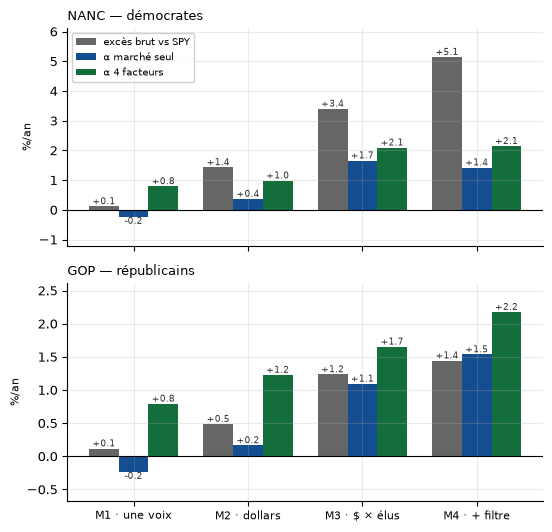

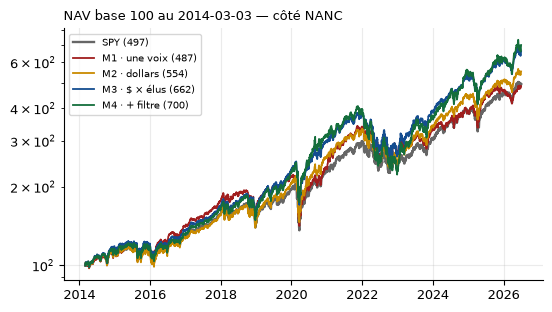

In [151]:
# ── §17 · les figures du papier, refaites sur le calendrier conforme (noms distincts : rien n'est écrasé) ──
S17 = {(m, f): run_livre(WPM17[(m, f)], np.inf, cuts=coupes17)[0]
       for f in ["NANC", "GOP"] for m in ["M1 · une voix", "M2 · dollars", "M3 · $ × élus", "M4 · + filtre"]}
MET17 = [("M1 · une voix", S17[("M1 · une voix", "NANC")], None),
         ("M2 · dollars",  S17[("M2 · dollars", "NANC")],  S17[("M2 · dollars", "GOP")]),
         ("M3 · $ × élus", S17[("M3 · $ × élus", "NANC")], S17[("M3 · $ × élus", "GOP")]),
         ("M4 · + filtre", S17[("M4 · + filtre", "NANC")], S17[("M4 · + filtre", "GOP")])]

# figure 1 — la cascade excès → α marché → α 4 facteurs
fig, axes = plt.subplots(2, 1, figsize=(5.6, 5.4), sharex=True)
for ax, (idx, nomf) in zip(axes, [(1, "NANC — démocrates"), (2, "GOP — républicains")]):
    lab, ex, a1, a4 = [], [], [], []
    for n, vn, vg in MET17:
        v = vn if idx == 1 or vg is None else vg
        b, fa = bilan_ic(v, n), facteurs(v, n)
        lab.append(n); ex.append(b["excès %/an"]); a1.append(b["α %/an"]); a4.append(fa["α %/an"])
    x = np.arange(len(lab)); w = 0.26
    for off, val, col, lb in [(-w, ex, GRIS, "excès brut vs SPY"), (0, a1, BLEU, "α marché seul"),
                              (w, a4, VERT, "α 4 facteurs")]:
        ax.bar(x+off, val, w, color=col, label=lb)
        for xi, vi in zip(x+off, val):
            ax.annotate(f"{vi:+.1f}", (xi, vi), ha="center", fontsize=6.5,
                        va="bottom" if vi >= 0 else "top", color="#333")
    ax.axhline(0, color="k", lw=0.8); ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=8)
    ax.set_title(nomf, fontsize=9, loc="left"); ax.grid(axis="y", alpha=0.25)
    ax.set_ylabel("%/an", fontsize=8); ax.margins(y=0.18)
axes[0].legend(fontsize=7, loc="upper left", framealpha=0.9)
plt.tight_layout(); plt.savefig(f"{FIGS}/meth17_cascade.png", dpi=170, bbox_inches="tight"); plt.show()

# figure 2 — les NAV, toutes rebasées sur la date de départ commune
D0 = max(v.index[0] for _, v, _ in MET17)
def _rb17(x): return x.loc[D0:] / float(x.loc[D0]) * 100
spy_r = _rb17((1 + r_spy).cumprod() * 100)
fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(spy_r.index, spy_r, color=GRIS, lw=1.7, label=f"SPY ({spy_r.iloc[-1]:.0f})")
for (n, vn, _), col in zip(MET17, [ROUGE, "#c98a00", BLEU, VERT]):
    v = _rb17(vn); ax.plot(v.index, v, color=col, lw=1.3, label=f"{n} ({v.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.set_title(f"NAV base 100 au {D0.date()} — côté NANC", fontsize=9, loc="left")
ax.legend(fontsize=7.5, loc="upper left"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(f"{FIGS}/meth17_nav.png", dpi=170, bbox_inches="tight"); plt.show()

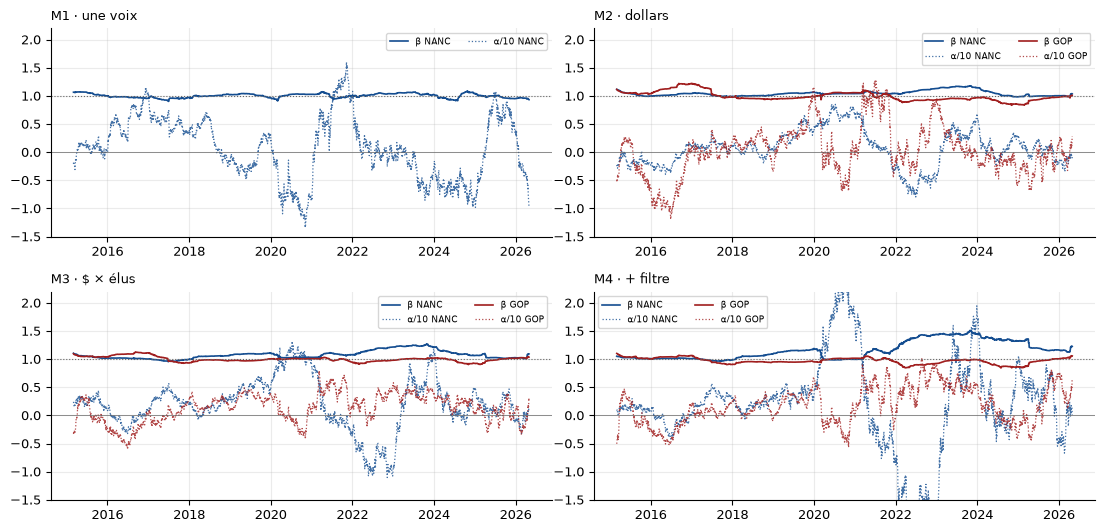

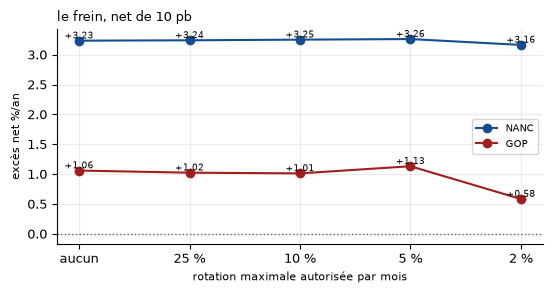

4 figures écrites : /Users/lemairealice/Downloads/Jupiter/02_recherche_backtest/figs_nb11/meth17_*.png

régularité de l'α glissant (252 j) — sur le calendrier conforme, au plafond du §17 :


α > 0 % du temps  β méd.  β min  β max  α méd. %/an  α min  α max  étendue α
méthode       fonds                                                                              
M1 · une voix NANC              56.77    1.00   0.90   1.08         0.72  -13.3   16.0       29.3
M2 · dollars  NANC              62.39    1.04   0.98   1.18         0.79   -8.0    8.6       16.6
              GOP               52.24    0.97   0.83   1.22         0.18  -11.8   12.8       24.6
M3 · $ × élus NANC              71.37    1.06   0.95   1.27         2.01  -11.0   13.2       24.2
              GOP               71.37    1.00   0.90   1.13         1.67   -6.0    8.0       14.0
M4 · + filtre NANC              69.16    1.13   0.96   1.51         1.92  -24.0   25.5       49.5
              GOP               69.44    0.97   0.84   1.10         1.81   -5.6   10.1       15.6

In [152]:
# figure 3 — α et β glissants (252 j), un panneau par méthode
fig, axes = plt.subplots(2, 2, figsize=(11, 5.4))
for ax, (n, vn, vg) in zip(axes.ravel(), MET17):
    for v, c, lb in [(vn, BLEU, "NANC"), (vg, ROUGE, "GOP")]:
        if v is None: continue
        aa, bb, _, _ = roll_ab(v)
        ax.plot(bb.index, bb, color=c, lw=1.2, label=f"β {lb}")
        ax.plot(aa.index, aa/10, color=c, lw=0.9, ls=":", alpha=.8, label=f"α/10 {lb}")
    ax.axhline(1, color=GRIS, ls=":", lw=0.8); ax.axhline(0, color=GRIS, ls="-", lw=0.5)
    ax.set_title(n, fontsize=9, loc="left"); ax.set_ylim(-1.5, 2.2); ax.legend(fontsize=6.5, ncol=2)
plt.tight_layout(); plt.savefig(f"{FIGS}/meth17_rolling.png", dpi=170, bbox_inches="tight"); plt.show()

# figure 4 — le frein sur M3, net de frais
fig, ax = plt.subplots(figsize=(5.6, 3.0))
for f, c in [("NANC", BLEU), ("GOP", ROUGE)]:
    ys = [bilan(run_livre(WPM17[("M3 · $ × élus", f)], tm, cuts=coupes17, cout_bps=COUT_BPS)[0], "x")["excès %/an"]
          for tm in PLAFONDS]
    ax.plot(range(len(PLAFONDS)), ys, "o-", color=c, lw=1.5, label=f)
    for i, y in enumerate(ys): ax.annotate(f"{y:+.2f}", (i, y), fontsize=6.5, ha="center", va="bottom")
ax.set_xticks(range(len(PLAFONDS))); ax.set_xticklabels(["aucun", "25 %", "10 %", "5 %", "2 %"])
ax.set_xlabel("rotation maximale autorisée par mois", fontsize=8); ax.set_ylabel("excès net %/an", fontsize=8)
ax.axhline(0, color=GRIS, ls=":", lw=1); ax.set_title(f"le frein, net de {COUT_BPS:.0f} pb", fontsize=9, loc="left")
ax.legend(fontsize=7.5); ax.grid(alpha=.25)
plt.tight_layout(); plt.savefig(f"{FIGS}/meth17_frein.png", dpi=170, bbox_inches="tight"); plt.show()
print("4 figures écrites :", FIGS + "/meth17_*.png")

# la régularité de l'α glissant — TOUTES les colonnes que le papier revendique.
# (Avant, cette cellule n'en imprimait que trois : le papier tirait β min–max et l'étendue de l'α du §16.3,
#  qui tourne au plafond 8,5 % sur 150 coupes. Ces valeurs étaient donc périmées et indétectables.)
REG = []
for n, vn, vg in MET17:
    for v, f in [(vn, "NANC"), (vg, "GOP")]:
        if v is None: continue
        aa, bb, _, _ = roll_ab(v)
        REG.append({"méthode": n, "fonds": f,
                    "α > 0 % du temps": 100*(aa > 0).mean(),
                    "β méd.": round(bb.median(), 2), "β min": round(bb.min(), 2), "β max": round(bb.max(), 2),
                    "α méd. %/an": round(aa.median(), 2), "α min": round(aa.min(), 1),
                    "α max": round(aa.max(), 1), "étendue α": round(aa.max() - aa.min(), 1)})
print("\nrégularité de l'α glissant (252 j) — sur le calendrier conforme, au plafond du §17 :")
display(pd.DataFrame(REG).set_index(["méthode", "fonds"]).round(2))

In [153]:
# VALIDATION §17 — additif : les runs sur `coupes` (150) sont inchangés, et 0 coupe dégénérée après la règle
for f, att in [("NANC", 672.35), ("GOP", 612.25)]:
    assert abs(run_livre(WPM[("M3 · $ × élus", f)], np.inf)[0].iloc[-1] - att) < 0.01, f"{f} : ancre cassée"
print(f"✅ les runs sur les {len(coupes)} coupes sont inchangés (672,35 / 612,25) — le §17 n'a rien écrasé")

for f in ["NANC", "GOP"]:
    deg = [i for i in coupes17[:-1] if 0 < len(WPM17[("M3 · $ × élus", f)].get(i, {})) < SEUIL17]
    assert not deg, f"{f} : coupes encore dégénérées {[str(cal[i].date()) for i in deg]}"
print(f"✅ 0 coupe sous {SEUIL17} titres dans le calendrier conforme, des deux côtés")

N_ESSAIS3 = N_ESSAIS2 + len(LIGNES17)
print(f"\n⚠ multiplicité : {N_ESSAIS3} bilans distincts → E[max |t|] ≈ √(2·ln {N_ESSAIS3}) = "
      f"{np.sqrt(2*np.log(N_ESSAIS3)):.2f} sous H₀.")

✅ les runs sur les 150 coupes sont inchangés (672,35 / 612,25) — le §17 n'a rien écrasé
✅ 0 coupe sous 10 titres dans le calendrier conforme, des deux côtés

⚠ multiplicité : 115 bilans distincts → E[max |t|] ≈ √(2·ln 115) = 3.08 sous H₀.


## §15 — Lecture

*(à remplir après lecture des chiffres ci-dessus)*

**Rappel des limites assumées** :
- la sélection utilise la **date de transaction** → l'information n'était pas publique → **borne haute**, pas une stratégie réplicable
- **aucun coût** de transaction ; le turnover mensuel n'est pas facturé
- pas de plafond de poids, pas de filtre de liquidité *(l'ADV n'est que rapportée, §9)*